<a href="https://colab.research.google.com/github/EkaMiharja/SMOTE_LightGBM_V1/blob/hasil-13-(Retrained)/smotelightbgm_v2_17fitur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [1]:
# NumPy
# Digunakan untuk operasi numerik dan pengolahan array
import numpy as np

# Pandas
# Digunakan untuk membaca, mengolah, dan menganalisis dataset
import pandas as pd

# Matplotlib
# Digunakan untuk membuat visualisasi data
import matplotlib.pyplot as plt

# Seaborn
# Digunakan untuk membuat visualisasi statistik
import seaborn as sns

# Scikit-learn
# Digunakan untuk membagi dataset menjadi data training dan testing
from sklearn.model_selection import train_test_split

# Scikit-learn
# Digunakan untuk mengevaluasi performa model klasifikasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# LightGBM
# Digunakan untuk membuat dan melatih model Machine Learning untuk klasifikasi traffic jaringan
from lightgbm import LGBMClassifier

# Imbalanced-learn
# Digunakan untuk menangani ketidakseimbangan jumlah kelas pada dataset menggunakan metode SMOTE
from imblearn.over_sampling import SMOTE

## 2. Load Dataset

In [2]:
# Membaca dataset CIC-IDS2018 dari file CSV
df = pd.read_csv("/content/cic.csv")

# Menampilkan 5 baris pertama dataset
print(df.head())

# Menampilkan ukuran dataset
# Hasil: (jumlah baris, 80 kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan jumlah kolom
print("Jumlah kolom:", len(df.columns))

# Menampilkan nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209              744   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                 0          0.0    

## 3. Cleaning Dataset

# a. Melihat Informasi Dataset

In [3]:
# Digunakan untuk melihat jumlah data, nama kolom, dan tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

# b. Mengecek missing value

In [4]:
# Digunakan untuk mengetahui apakah terdapat nilai kosong pada setiap kolom
print("\nJumlah Missing Value:")
print(df.isnull().sum())


Jumlah Missing Value:
Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64


# c. Menghapus data duplikat

In [5]:
# Data yang sama tidak diperlukan untuk proses training
df = df.drop_duplicates()

print("\nUkuran dataset setelah menghapus duplikat:")
print(df.shape)


Ukuran dataset setelah menghapus duplikat:
(822947, 80)


# d. Mengecek nilai tak hingga

In [6]:
print("\nJumlah nilai Infinity:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())


Jumlah nilai Infinity:
5365


# e. Mengganti nilai Infinity menjadi NaN


In [7]:
df = df.replace([np.inf, -np.inf], np.nan)

# f. Mengecek kembali missing value


In [8]:
# Setelah nilai Infinity diubah menjadi NaN
print("\nMissing Value setelah pengecekan Infinity:")
print(df.isnull().sum().sum())


Missing Value setelah pengecekan Infinity:
7642


# g. Hapus missing value

In [9]:
# Dilakukan setelah Infinity diubah menjadi NaN
df = df.dropna()

print("\nUkuran dataset setelah membersihkan missing value:")
print(df.shape)


Ukuran dataset setelah membersihkan missing value:
(819126, 80)


# h. Mengecek kembali kondisi dataset


In [10]:
# untuk memastikan dataset sudah bersih
print("\nInformasi dataset setelah cleaning:")
df.info()


Informasi dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 819126 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           819126 non-null  int64  
 1   Protocol           819126 non-null  int64  
 2   Timestamp          819126 non-null  object 
 3   Flow Duration      819126 non-null  int64  
 4   Tot Fwd Pkts       819126 non-null  int64  
 5   Tot Bwd Pkts       819126 non-null  int64  
 6   TotLen Fwd Pkts    819126 non-null  int64  
 7   TotLen Bwd Pkts    819126 non-null  int64  
 8   Fwd Pkt Len Max    819126 non-null  int64  
 9   Fwd Pkt Len Min    819126 non-null  int64  
 10  Fwd Pkt Len Mean   819126 non-null  float64
 11  Fwd Pkt Len Std    819126 non-null  float64
 12  Bwd Pkt Len Max    819126 non-null  int64  
 13  Bwd Pkt Len Min    819126 non-null  int64  
 14  Bwd Pkt Len Mean   819126 non-null  float64
 15  Bwd Pkt Len Std   

## 3. Eksplorasi Data (EDA)

# a. Melihat ukuran dataset

In [11]:
# Mengetahui jumlah baris dan kolom dataset
print("Jumlah Baris  :", df.shape[0])
print("Jumlah Kolom  :", df.shape[1])

Jumlah Baris  : 819126
Jumlah Kolom  : 80


# b. Melihat statistik deskriptif

In [12]:
# Melihat statistik dasar dari fitur numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Dst Port,819126.0,6.003352e+03,1.579974e+04,0.000000e+00,53.0,80.0,445.00,6.553300e+04
Protocol,819126.0,8.697304e+00,4.886142e+00,0.000000e+00,6.0,6.0,17.00,1.700000e+01
Flow Duration,819126.0,8.007824e+06,1.425916e+09,-9.190110e+11,317.0,49564.5,1755661.75,1.200000e+08
Tot Fwd Pkts,819126.0,7.658836e+00,5.022804e+01,1.000000e+00,1.0,2.0,9.00,5.115000e+03
Tot Bwd Pkts,819126.0,8.957209e+00,1.185914e+02,0.000000e+00,1.0,1.0,7.00,9.198000e+03
...,...,...,...,...,...,...,...,...
Active Min,819126.0,5.114668e+04,6.334491e+05,0.000000e+00,0.0,0.0,0.00,1.102401e+08
Idle Mean,819126.0,3.969899e+06,6.126370e+08,0.000000e+00,0.0,0.0,0.00,3.394503e+11
Idle Std,819126.0,9.341273e+05,4.322063e+08,0.000000e+00,0.0,0.0,0.00,2.432682e+11
Idle Max,819126.0,6.160411e+06,1.722154e+09,0.000000e+00,0.0,0.0,0.00,9.797810e+11


# c. Melihat distribusi label

In [13]:
# Mengetahui jumlah data pada setiap kelas
print("Distribusi Label:")
print(df['Label'].value_counts())

Distribusi Label:
Label
Benign            662458
SSH-Bruteforce    117322
FTP-BruteForce     39346
Name: count, dtype: int64


# d. Melihat persentase distribusi label

In [14]:
# Menghitung persentase setiap kelas
print("Persentase Label:")
print(df['Label'].value_counts(normalize=True) * 100)

Persentase Label:
Label
Benign            80.873761
SSH-Bruteforce    14.322827
FTP-BruteForce     4.803412
Name: proportion, dtype: float64


# e. Visualisasi distribusi label

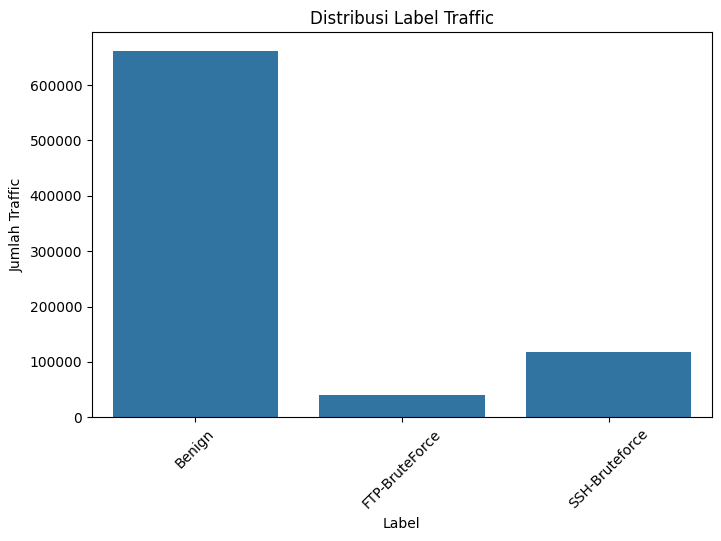

In [15]:
# Visualisasi jumlah traffic berdasarkan label
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Label')

plt.title('Distribusi Label Traffic')
plt.xlabel('Label')
plt.ylabel('Jumlah Traffic')
plt.xticks(rotation=45)
plt.show()

# f. Melihat fitur numerik

In [16]:
# Mengidentifikasi fitur dengan tipe data numerik
numeric_columns = df.select_dtypes(include=np.number).columns

print("Jumlah fitur numerik:", len(numeric_columns))
print("Fitur numerik:")
print(numeric_columns.tolist())

Jumlah fitur numerik: 78
Fitur numerik:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 

# g. Melihat distribusi fitur

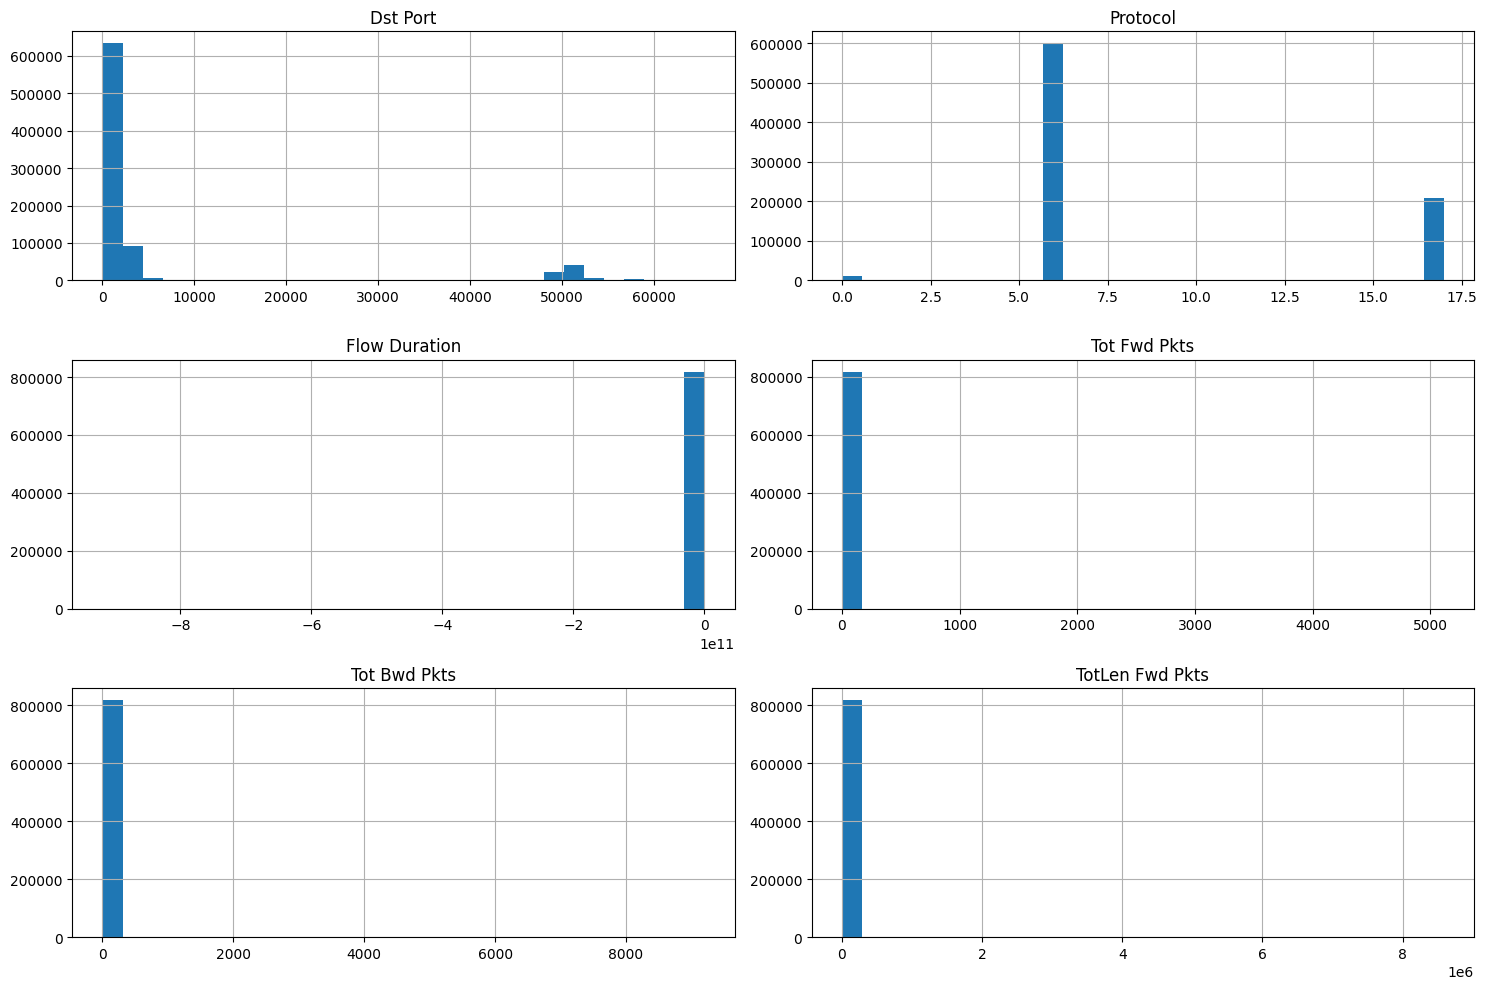

In [17]:
# Melihat distribusi beberapa fitur numerik
features_to_plot = numeric_columns[:6]

df[features_to_plot].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

# h. Melihat korelasi antar fitur

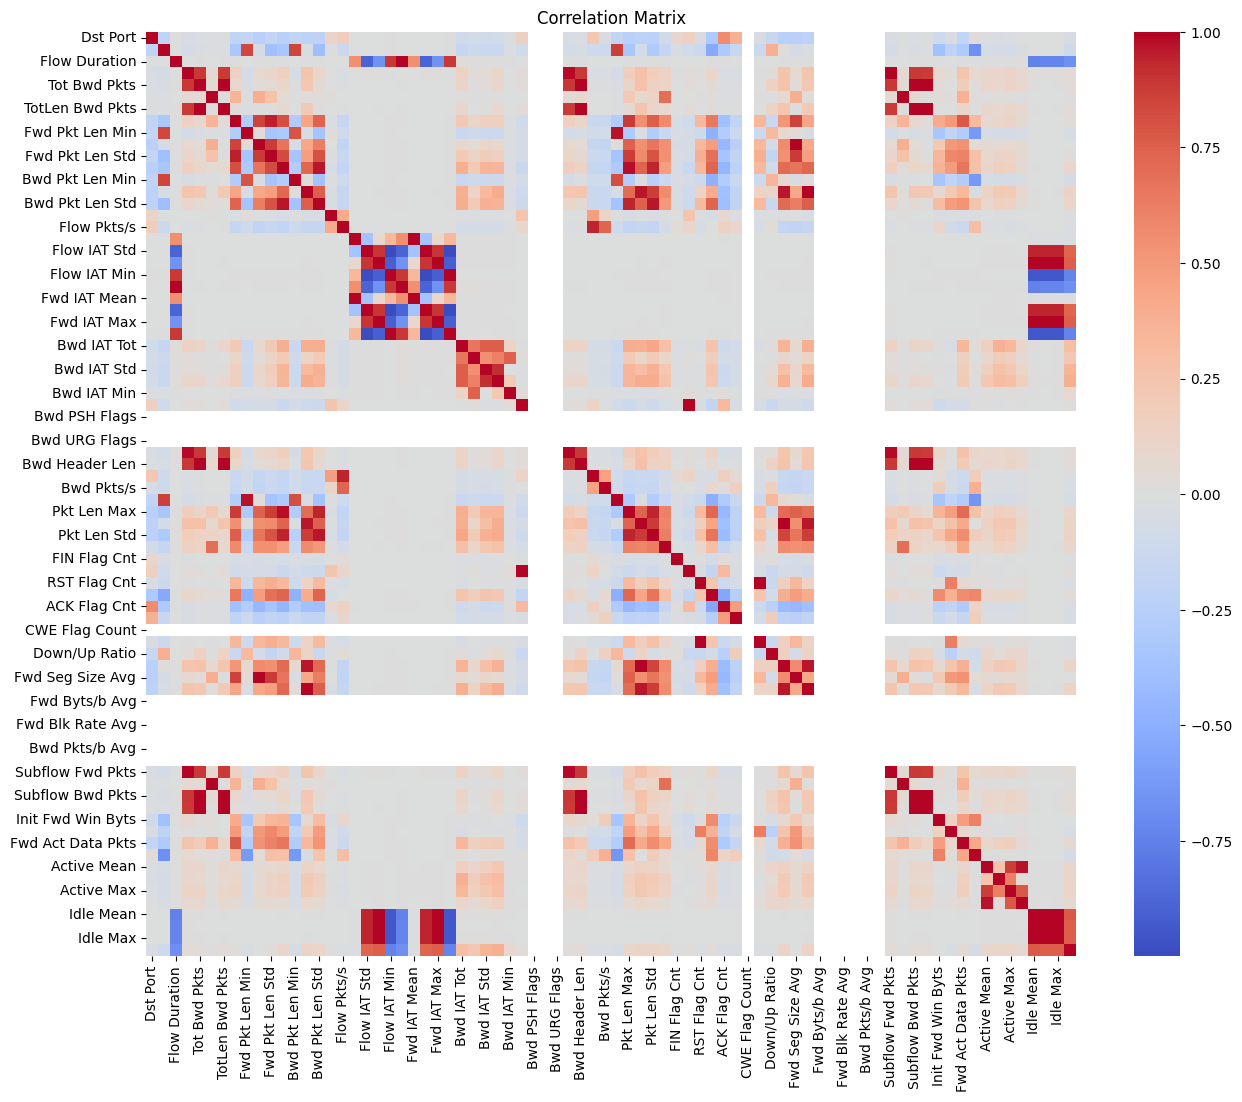

In [18]:
# Menghitung korelasi antar fitur numerik
correlation = df[numeric_columns].corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

# i. Membandingkan fitur berdasarkan label

In [19]:
# Membandingkan nilai rata-rata fitur berdasarkan label
df.groupby('Label')[numeric_columns].mean().T

Label,Benign,FTP-BruteForce,SSH-Bruteforce
Dst Port,7.417971e+03,21.000000,21.999940
Protocol,9.335203e+00,6.000000,6.000000
Flow Duration,9.849716e+06,10.300869,293158.461627
Tot Fwd Pkts,6.196991e+00,1.000000,18.146298
Tot Bwd Pkts,7.963930e+00,1.000000,17.234346
...,...,...,...
Active Min,6.324262e+04,0.000000,0.000000
Idle Mean,4.908760e+06,0.000000,0.000000
Idle Std,1.155044e+06,0.000000,0.000000
Idle Max,7.617317e+06,0.000000,0.000000


# j. Visualisasi fitur berdasarkan label

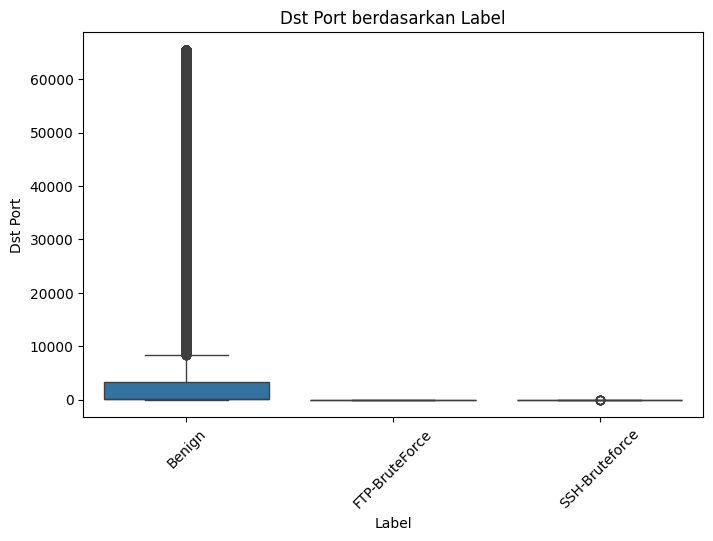

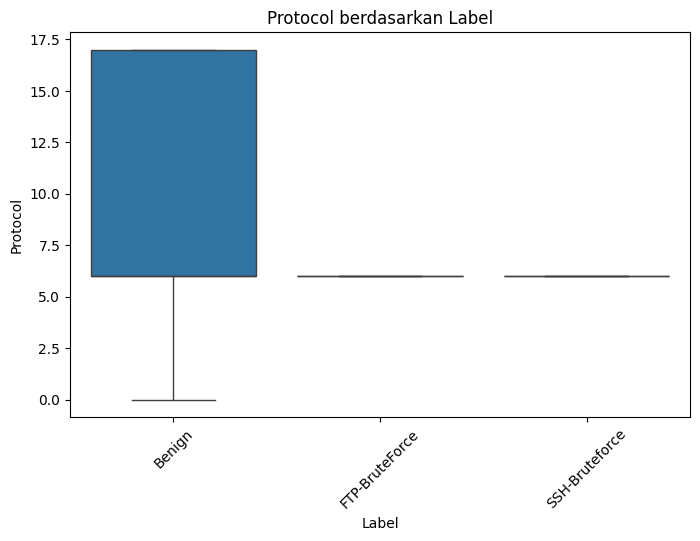

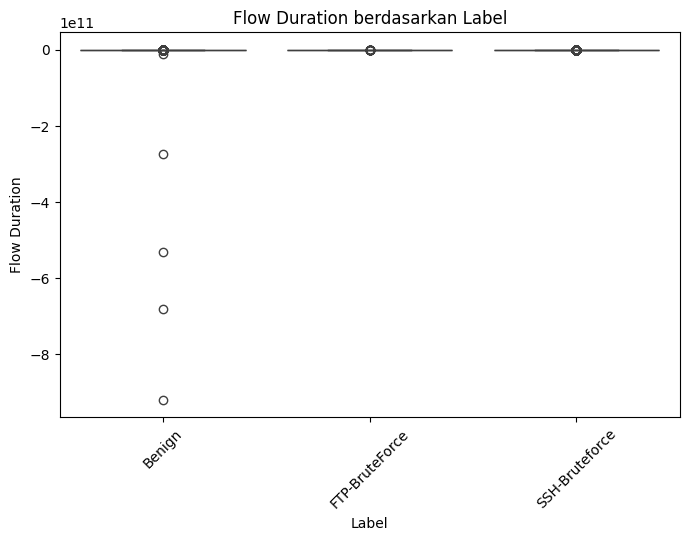

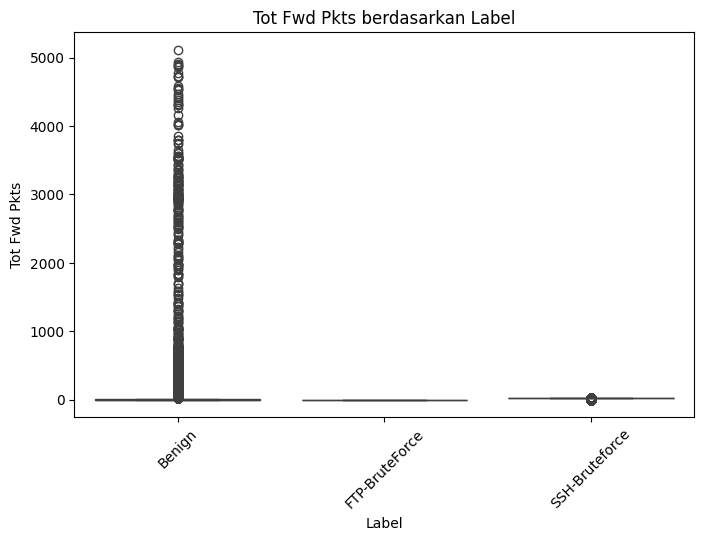

In [20]:
# Membandingkan distribusi fitur antara setiap kelas
features_to_compare = numeric_columns[:4]

for feature in features_to_compare:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='Label',
        y=feature
    )

    plt.title(f'{feature} berdasarkan Label')
    plt.xlabel('Label')
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.show()

# k. Mengecek outlier

In [21]:
# Mengecek jumlah outlier menggunakan metode IQR
for feature in numeric_columns:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[feature] < lower) | (df[feature] > upper)).sum()

    print(f"{feature}: {outliers} outlier")

Dst Port: 186150 outlier
Protocol: 0 outlier
Flow Duration: 152159 outlier
Tot Fwd Pkts: 100887 outlier
Tot Bwd Pkts: 123326 outlier
TotLen Fwd Pkts: 7112 outlier
TotLen Bwd Pkts: 49418 outlier
Fwd Pkt Len Max: 224 outlier
Fwd Pkt Len Min: 12870 outlier
Fwd Pkt Len Mean: 8454 outlier
Fwd Pkt Len Std: 6408 outlier
Bwd Pkt Len Max: 0 outlier
Bwd Pkt Len Min: 201028 outlier
Bwd Pkt Len Mean: 50224 outlier
Bwd Pkt Len Std: 23639 outlier
Flow Byts/s: 190091 outlier
Flow Pkts/s: 151308 outlier
Flow IAT Mean: 146869 outlier
Flow IAT Std: 126470 outlier
Flow IAT Max: 149788 outlier
Flow IAT Min: 152917 outlier
Fwd IAT Tot: 138883 outlier
Fwd IAT Mean: 128067 outlier
Fwd IAT Std: 178902 outlier
Fwd IAT Max: 133271 outlier
Fwd IAT Min: 133898 outlier
Bwd IAT Tot: 184915 outlier
Bwd IAT Mean: 194931 outlier
Bwd IAT Std: 177457 outlier
Bwd IAT Max: 179836 outlier
Bwd IAT Min: 174777 outlier
Fwd PSH Flags: 26338 outlier
Bwd PSH Flags: 0 outlier
Fwd URG Flags: 0 outlier
Bwd URG Flags: 0 outlier
Fwd 

## 4. Feature & Target

# a. Menentukan fitur yang berkaitan dengan traffic SSH

In [22]:
# Menentukan fitur yang berkaitan dengan karakteristik traffic
# SYN Flag Cnt dan RST Flag Cnt dihapus karena importance = 0 pada model sebelumnya
selected_features = [
    'Protocol',
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Pkts/s',
    'Bwd Pkts/s',
    'ACK Flag Cnt',
    'Init Fwd Win Byts',
    'Init Bwd Win Byts',
    'Fwd Seg Size Min'
]

print("Jumlah fitur:", len(selected_features))


Jumlah fitur: 17


# b. Membuat Feature (X)

In [23]:
# Mengambil fitur yang telah dipilih
X = df[selected_features].copy()

print("Ukuran X:", X.shape)

Ukuran X: (819126, 17)


# c. Memilih target sesuai fokus penelitian

In [24]:
# Hanya menggunakan traffic Benign dan SSH-Bruteforce
df_target = df[df['Label'].isin([
    'Benign',
    'SSH-Bruteforce'
])].copy()

print("Distribusi label:")
print(df_target['Label'].value_counts())

Distribusi label:
Label
Benign            662458
SSH-Bruteforce    117322
Name: count, dtype: int64


# d. Mengubah label menjadi numerik

In [25]:
# Mengubah label menjadi nilai numerik
# 0 = Benign
# 1 = SSH-Bruteforce
df_target['Label'] = df_target['Label'].map({
    'Benign': 0,
    'SSH-Bruteforce': 1
})

print("Distribusi target:")
print(df_target['Label'].value_counts())

Distribusi target:
Label
0    662458
1    117322
Name: count, dtype: int64


# e. Membuat kembali Feature (X)

In [26]:
# Membuat Feature dari data yang sudah difilter
X = df_target[selected_features].copy()

print("Ukuran X:", X.shape)

Ukuran X: (779780, 17)


# f. Menentukan Target (y)

In [27]:
# Menentukan Label sebagai target
y = df_target['Label'].copy()

print("Ukuran y:", y.shape)
print(y.value_counts())

Ukuran y: (779780,)
Label
0    662458
1    117322
Name: count, dtype: int64


# g. Mengecek Feature dan Target

In [28]:
# Memastikan jumlah data X dan y sama
print("Jumlah data X:", len(X))
print("Jumlah data y:", len(y))

print("\nApakah jumlah data sama?", len(X) == len(y))

Jumlah data X: 779780
Jumlah data y: 779780

Apakah jumlah data sama? True


# h. Mengecek fitur yang digunakan

In [29]:
# Menampilkan daftar fitur yang digunakan
print("Fitur yang digunakan:")
for feature in X.columns:
    print(feature)

print("\nJumlah fitur:", len(X.columns))

Fitur yang digunakan:
Protocol
Flow Duration
Tot Fwd Pkts
Tot Bwd Pkts
TotLen Fwd Pkts
TotLen Bwd Pkts
Flow Pkts/s
Flow IAT Mean
Flow IAT Std
Fwd IAT Mean
Bwd IAT Mean
Fwd Pkts/s
Bwd Pkts/s
ACK Flag Cnt
Init Fwd Win Byts
Init Bwd Win Byts
Fwd Seg Size Min

Jumlah fitur: 17


# i. Memastikan Label tidak masuk ke Feature

In [30]:
# Memastikan kolom Label tidak terdapat di dalam X
print("Apakah Label terdapat pada X?", 'Label' in X.columns)

Apakah Label terdapat pada X? False


# j. Mengecek kembali distribusi target

In [31]:
# Melihat distribusi akhir target
print("Distribusi target akhir:")

print(
    y.value_counts()
)

print("\nPersentase target:")
print(
    y.value_counts(normalize=True) * 100
)

Distribusi target akhir:
Label
0    662458
1    117322
Name: count, dtype: int64

Persentase target:
Label
0    84.954474
1    15.045526
Name: proportion, dtype: float64


## 5. Preprocessing & Split Data

# a. Mengecek nilai infinite

In [32]:
# Mengecek apakah terdapat nilai infinity pada fitur
print("Jumlah nilai inf:")
print(np.isinf(X).sum().sum())

Jumlah nilai inf:
0


# b. Menangani nilai infinite

In [33]:
# Mengubah nilai infinity menjadi NaN
X = X.replace([np.inf, -np.inf], np.nan)

print("Jumlah NaN:", X.isnull().sum().sum())

Jumlah NaN: 0


# c. Mengecek missing value setelah penggantian inf

In [34]:
# Mengecek kembali missing value pada fitur
missing_values = X.isnull().sum()

print("Missing value:")
print(missing_values[missing_values > 0])

Missing value:
Series([], dtype: int64)


# d. Menghapus data yang memiliki missing value

In [35]:
# Menghapus baris yang masih memiliki missing value
valid_data = X.notnull().all(axis=1)

X = X[valid_data].copy()
y = y[valid_data].copy()

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (779780, 17)
Ukuran y: (779780,)


# e. Mengecek nilai negatif pada Flow Duration

In [36]:
# Mengecek nilai Flow Duration yang negatif
negative_duration = (X['Flow Duration'] < 0).sum()

print("Flow Duration negatif:", negative_duration)

Flow Duration negatif: 5


# f. Menghapus Flow Duration yang tidak valid

In [37]:
# Menghapus data dengan Flow Duration negatif
valid_duration = X['Flow Duration'] >= 0

X = X[valid_duration].copy()
y = y[valid_duration].copy()

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (779775, 17)
Ukuran y: (779775,)


# g. Mengecek fitur konstan

In [38]:
# Mencari fitur yang hanya memiliki satu nilai
constant_features = [
    column for column in X.columns
    if X[column].nunique() <= 1
]

print("Fitur konstan:")
print(constant_features)

Fitur konstan:
[]


# h. Menghapus fitur konstan

In [39]:
# Menghapus fitur yang tidak memiliki variasi
X = X.drop(columns=constant_features)

print("Jumlah fitur:", X.shape[1])

Jumlah fitur: 17


# i. Membuat dataset berdasarkan timestamp

In [40]:
# Menggabungkan fitur, target, dan timestamp
data_model = X.copy()

data_model['Label'] = y
data_model['Timestamp'] = df_target.loc[X.index, 'Timestamp']

# Mengurutkan data berdasarkan waktu
data_model = data_model.sort_values('Timestamp')

print("Rentang waktu:")
print("Mulai  :", data_model['Timestamp'].min())
print("Selesai:", data_model['Timestamp'].max())

Rentang waktu:
Mulai  : 14/02/2018 01:00:00
Selesai: 14/02/2018 12:59:59


# j. Mengecek distribusi label berdasarkan waktu

In [41]:
# Mengubah Timestamp menjadi format datetime
data_model['Timestamp'] = pd.to_datetime(
    data_model['Timestamp'],
    dayfirst=True,
    errors='coerce'
)

# Mengecek apakah ada Timestamp yang gagal dikonversi
print("Jumlah Timestamp tidak valid:",
      data_model['Timestamp'].isna().sum())

Jumlah Timestamp tidak valid: 0


In [42]:
# Mengelompokkan jumlah label berdasarkan setiap jam
time_label = (
    data_model
    .groupby([
        pd.Grouper(key='Timestamp', freq='1h'),
        'Label'
    ])
    .size()
    .unstack(fill_value=0)
)

print(time_label)

Label                     0      1
Timestamp                         
2018-02-14 01:00:00   64955      0
2018-02-14 02:00:00   49494  75346
2018-02-14 03:00:00   35301  41976
2018-02-14 04:00:00   28251      0
2018-02-14 05:00:00   11581      0
2018-02-14 08:00:00   66699      0
2018-02-14 09:00:00  104752      0
2018-02-14 10:00:00  114156      0
2018-02-14 11:00:00  104958      0
2018-02-14 12:00:00   82306      0


# k. Menentukan batas waktu Training dan Testing

In [43]:
# Menentukan batas waktu berdasarkan pola kemunculan serangan
train_end = pd.Timestamp('2018-02-14 03:00:00')

# l. Membagi data berdasarkan waktu

In [44]:
# Membagi data secara temporal
train_data = data_model[
    data_model['Timestamp'] < train_end
].copy()

test_data = data_model[
    data_model['Timestamp'] >= train_end
].copy()

print("Ukuran Training:", train_data.shape)
print("Ukuran Testing :", test_data.shape)

Ukuran Training: (189795, 19)
Ukuran Testing : (589980, 19)


# m. Memisahkan Feature dan Target

In [45]:
# Memisahkan fitur dan target training
X_train = train_data.drop(columns=['Label', 'Timestamp'])
y_train = train_data['Label']

# Memisahkan fitur dan target testing
X_test = test_data.drop(columns=['Label', 'Timestamp'])
y_test = test_data['Label']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (189795, 17)
y_train: (189795,)
X_test : (589980, 17)
y_test : (589980,)


# n. Mengecek distribusi label

In [46]:
# Mengecek distribusi kelas pada training dan testing
print("=== TRAINING ===")
print(y_train.value_counts())

print("\n=== TESTING ===")
print(y_test.value_counts())

=== TRAINING ===
Label
0    114449
1     75346
Name: count, dtype: int64

=== TESTING ===
Label
0    548004
1     41976
Name: count, dtype: int64


# o. Mengecek persentase label

In [47]:
# Melihat persentase setiap kelas
print("=== PERSENTASE TRAINING ===")
print(y_train.value_counts(normalize=True) * 100)

print("\n=== PERSENTASE TESTING ===")
print(y_test.value_counts(normalize=True) * 100)

=== PERSENTASE TRAINING ===
Label
0    60.301378
1    39.698622
Name: proportion, dtype: float64

=== PERSENTASE TESTING ===
Label
0    92.885183
1     7.114817
Name: proportion, dtype: float64


# p. Mengecek rentang waktu

In [48]:
# Memastikan training dan testing berada pada periode waktu berbeda
print("=== TRAINING ===")
print("Mulai  :", train_data['Timestamp'].min())
print("Selesai:", train_data['Timestamp'].max())

print("\n=== TESTING ===")
print("Mulai  :", test_data['Timestamp'].min())
print("Selesai:", test_data['Timestamp'].max())

=== TRAINING ===
Mulai  : 2018-02-14 01:00:00
Selesai: 2018-02-14 02:59:59

=== TESTING ===
Mulai  : 2018-02-14 03:00:00
Selesai: 2018-02-14 12:59:59


# q. Mengecek timestamp overlap

In [49]:
# Memastikan tidak ada timestamp yang sama
overlap = set(
    train_data['Timestamp']
).intersection(
    set(test_data['Timestamp'])
)

print("Jumlah timestamp overlap:", len(overlap))

Jumlah timestamp overlap: 0


# r. Mengecek dataset final

In [50]:
# Ringkasan dataset sebelum masuk ke SMOTE
print("=== DATASET FINAL ===")
print("Jumlah fitur :", X_train.shape[1])
print("Training     :", X_train.shape)
print("Testing      :", X_test.shape)
print("Target Train :", y_train.shape)
print("Target Test  :", y_test.shape)

=== DATASET FINAL ===
Jumlah fitur : 17
Training     : (189795, 17)
Testing      : (589980, 17)
Target Train : (189795,)
Target Test  : (589980,)


## 6. SMOTE dan Pembagian Validation Data

# a. Import SMOTE

In [51]:
# Mengimpor metode SMOTE untuk menangani ketidakseimbangan kelas
from imblearn.over_sampling import SMOTE

# b. Membagi Training menjadi Train dan Validation

In [52]:
from sklearn.model_selection import train_test_split

# Membagi data training menjadi train-fit dan validation
X_train_fit, X_valid, y_train_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train Fit :", X_train_fit.shape)
print("Validation:", X_valid.shape)

Train Fit : (151836, 17)
Validation: (37959, 17)


# c. Cek distribusi sebelum SMOTE

In [53]:
print("Distribusi Train Fit:")
print(y_train_fit.value_counts())

print("\nDistribusi Validation:")
print(y_valid.value_counts())

Distribusi Train Fit:
Label
0    91559
1    60277
Name: count, dtype: int64

Distribusi Validation:
Label
0    22890
1    15069
Name: count, dtype: int64


# d. Menerapkan SMOTE pada Train Fit

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# SMOTE hanya pada data Train Fit
X_train_fit_smote, y_train_fit_smote = smote.fit_resample(
    X_train_fit,
    y_train_fit
)

print("Sebelum SMOTE :", X_train_fit.shape)
print("Setelah SMOTE :", X_train_fit_smote.shape)

Sebelum SMOTE : (151836, 17)
Setelah SMOTE : (183118, 17)


# e. Mengecek distribusi setelah SMOTE

In [55]:
print("Distribusi setelah SMOTE:")
print(y_train_fit_smote.value_counts())

Distribusi setelah SMOTE:
Label
1    91559
0    91559
Name: count, dtype: int64


# f. Memastikan Validation dan Testing tidak terkena SMOTE

In [56]:
print("Train Fit SMOTE :", X_train_fit_smote.shape)
print("Validation      :", X_valid.shape)
print("Testing         :", X_test.shape)

print("\nDistribusi Validation:")
print(y_valid.value_counts())

print("\nDistribusi Testing:")
print(y_test.value_counts())

Train Fit SMOTE : (183118, 17)
Validation      : (37959, 17)
Testing         : (589980, 17)

Distribusi Validation:
Label
0    22890
1    15069
Name: count, dtype: int64

Distribusi Testing:
Label
0    548004
1     41976
Name: count, dtype: int64


# g. Memastikan data testing tidak berubah

In [57]:
# Memastikan distribusi testing tetap menggunakan data asli
print("Distribusi data testing:")
print(y_test.value_counts())

print("\nPersentase data testing:")
print(y_test.value_counts(normalize=True) * 100)

Distribusi data testing:
Label
0    548004
1     41976
Name: count, dtype: int64

Persentase data testing:
Label
0    92.885183
1     7.114817
Name: proportion, dtype: float64


# h. Mengecek ukuran akhir dataset

In [58]:
# Menampilkan ukuran dan persentase data yang digunakan
print("=== DATASET FINAL ===")

# Jumlah baris masing-masing dataset
n_train_before = X_train_fit.shape[0]
n_train_after  = X_train_fit_smote.shape[0]
n_valid        = X_valid.shape[0]
n_test         = X_test.shape[0]

# Total dataset sebelum SMOTE
total_before_smote = n_train_before + n_valid + n_test

# Total dataset setelah SMOTE
total_after_smote = n_train_after + n_valid + n_test

# Persentase sebelum SMOTE
pct_train_before = (n_train_before / total_before_smote) * 100
pct_valid_before = (n_valid / total_before_smote) * 100
pct_test_before  = (n_test / total_before_smote) * 100

# Persentase setelah SMOTE
pct_train_after = (n_train_after / total_after_smote) * 100
pct_valid_after = (n_valid / total_after_smote) * 100
pct_test_after  = (n_test / total_after_smote) * 100

print(
    f"Training sebelum SMOTE : {n_train_before:,} "
    f"({pct_train_before:.2f}% dari data sebelum SMOTE)"
)

print(
    f"Training setelah SMOTE : {n_train_after:,} "
    f"({pct_train_after:.2f}% dari dataset final)"
)

print(
    f"Validation             : {n_valid:,} "
    f"({pct_valid_after:.2f}% dari dataset final)"
)

print(
    f"Testing                : {n_test:,} "
    f"({pct_test_after:.2f}% dari dataset final)"
)

print()
print(f"Total sebelum SMOTE    : {total_before_smote:,}")
print(f"Total setelah SMOTE    : {total_after_smote:,}")

# Tambahan: seberapa besar data training bertambah karena SMOTE
smote_increase = ((n_train_after - n_train_before) / n_train_before) * 100

print(
    f"Pertambahan training akibat SMOTE : "
    f"{smote_increase:.2f}%"
)

=== DATASET FINAL ===
Training sebelum SMOTE : 151,836 (19.47% dari data sebelum SMOTE)
Training setelah SMOTE : 183,118 (22.58% dari dataset final)
Validation             : 37,959 (4.68% dari dataset final)
Testing                : 589,980 (72.74% dari dataset final)

Total sebelum SMOTE    : 779,775
Total setelah SMOTE    : 811,057
Pertambahan training akibat SMOTE : 20.60%


## 7. Training Model LightGBM

# a. Import LightGBM

In [59]:
import lightgbm as lgb

# b. Membuat Model LightGBM

In [60]:
model_lgbm = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

# c. Training Model

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 91559, number of negative: 91559
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3484
[LightGBM] [Info] Number of data points in the train set: 183118, number of used features: 17
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

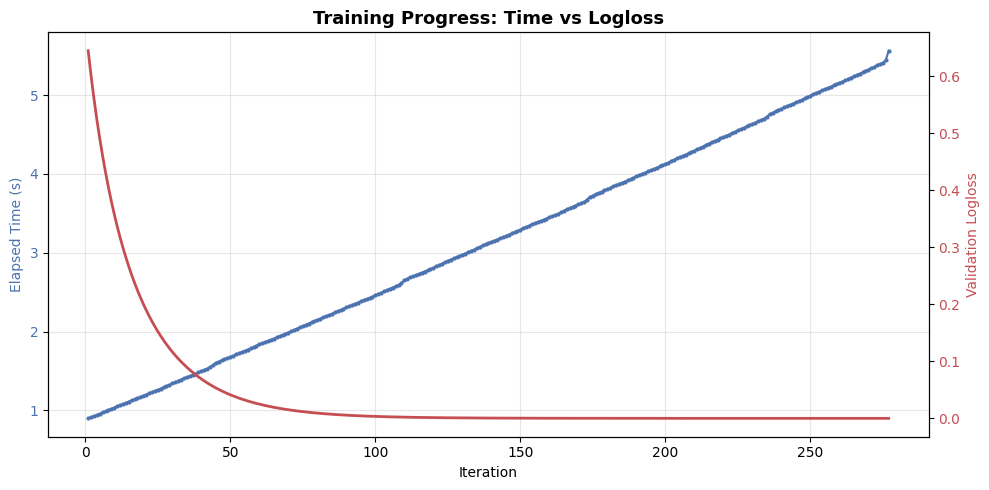

In [61]:
import time
import pandas as pd
import matplotlib.pyplot as plt

start_time = time.time()
iter_log = []

def timing_callback(env):
    iter_log.append({
        'iteration': env.iteration + 1,
        'elapsed': time.time() - start_time,
        'logloss': env.evaluation_result_list[0][2] if env.evaluation_result_list else None
    })

model_lgbm.fit(
    X_train_fit_smote,
    y_train_fit_smote,
    eval_set=[(X_valid, y_valid)],
    eval_metric='binary_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        timing_callback
    ]
)

df_time = pd.DataFrame(iter_log)
df_time['delta'] = df_time['elapsed'].diff()

print(f"\n=== TRAINING SUMMARY ===")
print(f"Total waktu     : {df_time['elapsed'].iloc[-1]:.2f} detik")
print(f"Total iterasi   : {len(df_time)}")
print(f"Iterasi tercepat: {df_time['delta'].min()*1000:.2f} ms")
print(f"Iterasi terslow : {df_time['delta'].max()*1000:.2f} ms")
print(f"Rata-rata       : {df_time['delta'].mean()*1000:.2f} ms")

# Plot 2 sumbu: waktu kumulatif + logloss
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_time['iteration'], df_time['elapsed'],
         color='#4C72B0', marker='o', markersize=2, label='Elapsed')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Elapsed Time (s)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_time['iteration'], df_time['logloss'],
         color='#C44E52', linewidth=2, label='Logloss')
ax2.set_ylabel('Validation Logloss', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

plt.title('Training Progress: Time vs Logloss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# d. Mengecek Best Iteration

In [62]:
print("Best iteration :", model_lgbm.best_iteration_)

Best iteration : 227


# e. Mengecek Hasil Training

In [63]:
print("\n=== HASIL TRAINING LIGHTGBM ===")
print("Best iteration :", model_lgbm.best_iteration_)
print("Best score     :", model_lgbm.best_score_)


=== HASIL TRAINING LIGHTGBM ===
Best iteration : 227
Best score     : defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'binary_logloss': np.float64(3.111649580787449e-05)})})


# f. Mengecek Jumlah Feature yang Digunakan

In [64]:
print("Jumlah feature :", X_train_fit_smote.shape[1])
print("Daftar feature :")
print(X_train_fit_smote.columns.tolist())

Jumlah feature : 17
Daftar feature :
['Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd Pkts/s', 'Bwd Pkts/s', 'ACK Flag Cnt', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Seg Size Min']


## 8. Evaluasi Model LightGBM

# a. Melakukan Prediksi pada Data Testing

In [65]:
# Melakukan prediksi pada data testing
y_pred = model_lgbm.predict(X_test)

# Probabilitas kelas SSH-Bruteforce
y_pred_proba = model_lgbm.predict_proba(X_test)[:, 1]

# b. Menghitung Accuracy, Precision, Recall, dan F1-Score

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== HASIL EVALUASI MODEL LIGHTGBM ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

=== HASIL EVALUASI MODEL LIGHTGBM ===
Accuracy  : 1.0000
Precision : 0.9997
Recall    : 1.0000
F1-Score  : 0.9999


# c. Menghitung AUC

In [67]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC       : {auc:.4f}")

AUC       : 1.0000


# d. Menampilkan Confusion Matrix

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("=== CONFUSION MATRIX ===")
print(cm)

=== CONFUSION MATRIX ===
[[547992     12]
 [     0  41976]]


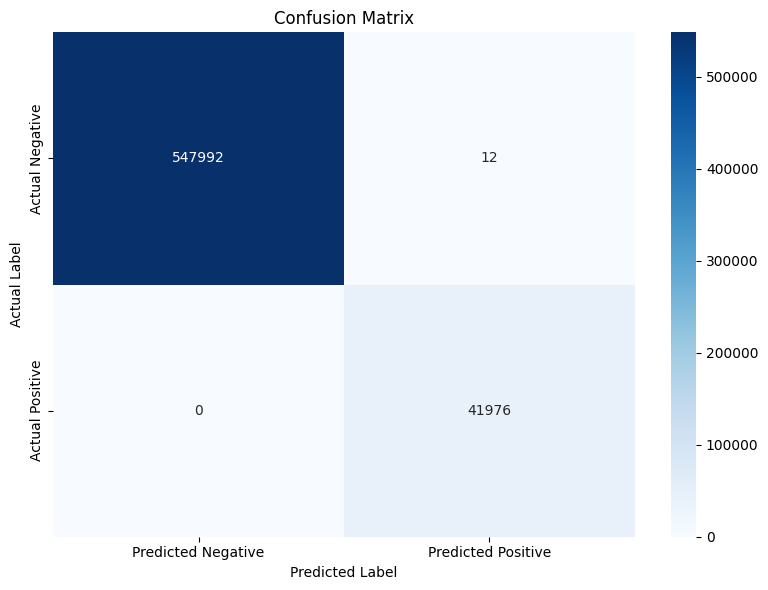

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# e. Menampilkan Classification Report

In [70]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Benign', 'SSH-Bruteforce']
    )
)

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    548004
SSH-Bruteforce       1.00      1.00      1.00     41976

      accuracy                           1.00    589980
     macro avg       1.00      1.00      1.00    589980
  weighted avg       1.00      1.00      1.00    589980



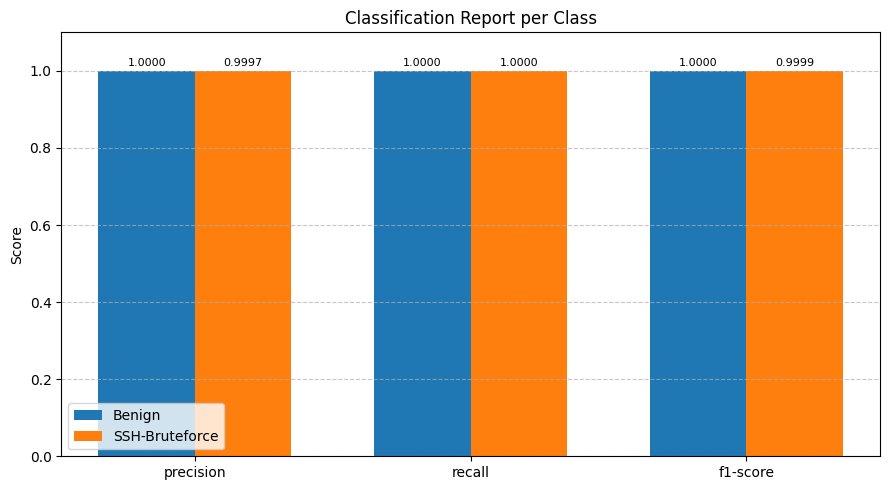

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

report = classification_report(
    y_test, y_pred,
    target_names=['Benign', 'SSH-Bruteforce'],
    output_dict=True
)
df_report = pd.DataFrame(report).transpose().iloc[:-3, :3]

metrics = df_report.columns
classes = df_report.index
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, cls in enumerate(classes):
    offset = (i - len(classes)/2 + 0.5) * width
    bars = ax.bar(x + offset, df_report.loc[cls], width, label=cls)
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Report per Class')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# f. Menampilkan Seluruh Hasil Evaluasi

In [72]:
print("=== RINGKASAN EVALUASI LIGHTGBM ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

=== RINGKASAN EVALUASI LIGHTGBM ===
Accuracy  : 1.0000
Precision : 0.9997
Recall    : 1.0000
F1-Score  : 0.9999
AUC       : 1.0000


## 9. Feature Importance

# a. Mengambil Feature Importance

In [73]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_fit_smote.columns,
    'Importance': model_lgbm.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
15  Init Bwd Win Byts         377
1       Flow Duration         219
16   Fwd Seg Size Min         214
14  Init Fwd Win Byts         170
12         Bwd Pkts/s          74
2        Tot Fwd Pkts          70
8        Flow IAT Std          45
11         Fwd Pkts/s          43
0            Protocol          39
13       ACK Flag Cnt          24
3        Tot Bwd Pkts          10
5     TotLen Bwd Pkts           7
7       Flow IAT Mean           7
6         Flow Pkts/s           6
4     TotLen Fwd Pkts           6
9        Fwd IAT Mean           3
10       Bwd IAT Mean           3


# b. Menampilkan Ranking Feature Importance

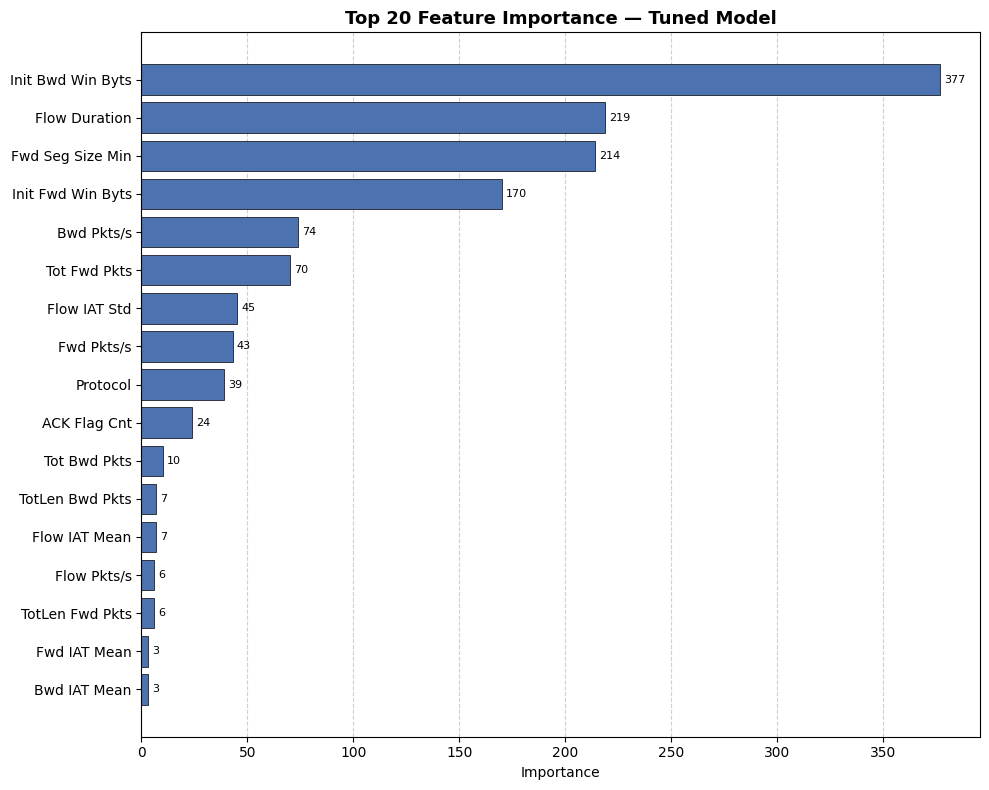

In [74]:
import matplotlib.pyplot as plt

top_n = 20
df_top = feature_importance.head(top_n).iloc[::-1]  # reverse biar rank 1 di atas

plt.figure(figsize=(10, 8))
bars = plt.barh(df_top['Feature'], df_top['Importance'],
                color='#4C72B0', edgecolor='black', linewidth=0.5)
plt.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importance — Tuned Model',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

# c. Melihat 10 Fitur Teratas

In [75]:
top10_features = feature_importance.head(10)

print("=== TOP 10 FEATURE IMPORTANCE ===")
print(top10_features.to_string(index=False))

=== TOP 10 FEATURE IMPORTANCE ===
          Feature  Importance
Init Bwd Win Byts         377
    Flow Duration         219
 Fwd Seg Size Min         214
Init Fwd Win Byts         170
       Bwd Pkts/s          74
     Tot Fwd Pkts          70
     Flow IAT Std          45
       Fwd Pkts/s          43
         Protocol          39
     ACK Flag Cnt          24


# d. Mengecek Dominasi Fitur

In [76]:
# Menghitung persentase importance
feature_importance['Importance (%)'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

# Mengurutkan feature berdasarkan importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Membuat ranking feature
feature_importance.insert(
    0,
    'Rank',
    range(1, len(feature_importance) + 1)
)

print("=== FEATURE IMPORTANCE ===")
print(
    feature_importance[
        ['Rank', 'Feature', 'Importance', 'Importance (%)']
    ].to_string(index=False)
)

=== FEATURE IMPORTANCE ===
 Rank           Feature  Importance  Importance (%)
    1 Init Bwd Win Byts         377       28.625664
    2     Flow Duration         219       16.628702
    3  Fwd Seg Size Min         214       16.249051
    4 Init Fwd Win Byts         170       12.908125
    5        Bwd Pkts/s          74        5.618831
    6      Tot Fwd Pkts          70        5.315110
    7      Flow IAT Std          45        3.416856
    8        Fwd Pkts/s          43        3.264996
    9          Protocol          39        2.961276
   10      ACK Flag Cnt          24        1.822323
   11      Tot Bwd Pkts          10        0.759301
   12   TotLen Bwd Pkts           7        0.531511
   13     Flow IAT Mean           7        0.531511
   14       Flow Pkts/s           6        0.455581
   15   TotLen Fwd Pkts           6        0.455581
   16      Fwd IAT Mean           3        0.227790
   17      Bwd IAT Mean           3        0.227790


## 10. Hyperparameter Tuning

# a. Import Optuna

In [77]:
# Library untuk mencari kombinasi hyperparameter terbaik
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.9 MB/s eta 0:00:00


# b. Membuat fungsi objective

In [78]:
def objective(trial):

    # Menentukan ruang pencarian hyperparameter
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,

        'n_estimators': trial.suggest_int(
            'n_estimators', 100, 500
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.1, log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth', 2, 6
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves', 7, 31
        ),

        'min_child_samples': trial.suggest_int(
            'min_child_samples', 20, 100
        ),

        'subsample': trial.suggest_float(
            'subsample', 0.7, 1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.7, 1.0
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha', 0.0, 1.0
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda', 0.0, 1.0
        )
    }

    # Membuat model LightGBM
    model = lgb.LGBMClassifier(**params)

    # Training menggunakan data Train Fit hasil SMOTE
    model.fit(
        X_train_fit_smote,
        y_train_fit_smote,
        eval_set=[(X_valid, y_valid)],
        eval_metric='binary_logloss',
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=50,
                verbose=False
            )
        ]
    )

    # Mengambil binary logloss terbaik pada validation
    best_score = model.best_score_['valid_0']['binary_logloss']

    return best_score

# c. Membuat study Optuna

In [79]:
# Membuat proses optimasi
study = optuna.create_study(
    direction='minimize',
    study_name='LightGBM_Tuning'
)

print("Optuna study berhasil dibuat.")

[I 2026-10-07 00:52:39,247] A new study created in memory with name: LightGBM_Tuning


Optuna study berhasil dibuat.


# d. Menjalankan 30 trials

In [80]:
study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True   # progress bar otomatis nampilkan elapsed time
)

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-10-07 00:53:00,363] Trial 0 finished with value: 2.728481011629618e-05 and parameters: {'n_estimators': 327, 'learning_rate': 0.07788652752187127, 'max_depth': 3, 'num_leaves': 29, 'min_child_samples': 80, 'subsample': 0.7157088751028572, 'colsample_bytree': 0.8436963536024011, 'reg_alpha': 0.4798724398102435, 'reg_lambda': 0.6051956262165742}. Best is trial 0 with value: 2.728481011629618e-05.
[I 2026-10-07 00:53:15,895] Trial 1 finished with value: 5.398667328045136e-05 and parameters: {'n_estimators': 133, 'learning_rate': 0.07726644043041737, 'max_depth': 3, 'num_leaves': 13, 'min_child_samples': 30, 'subsample': 0.7437323191110913, 'colsample_bytree': 0.9894668447879273, 'reg_alpha': 0.3174893906822056, 'reg_lambda': 0.1443193620024712}. Best is trial 0 with value: 2.728481011629618e-05.
[I 2026-10-07 00:53:24,045] Trial 2 finished with value: 0.08877534098445419 and parameters: {'n_estimators': 138, 'learning_rate': 0.012858297029576842, 'max_depth': 5, 'num_leaves': 8, '

# e. Melihat parameter terbaik

In [81]:
print("=== BEST HYPERPARAMETERS ===")

for param, value in study.best_params.items():
    print(f"{param}: {value}")

print("\nBest Binary Logloss:")
print(study.best_value)

=== BEST HYPERPARAMETERS ===
n_estimators: 368
learning_rate: 0.0908757284319028
max_depth: 5
num_leaves: 23
min_child_samples: 81
subsample: 0.7901965536917058
colsample_bytree: 0.85177279202433
reg_alpha: 0.14988843101572571
reg_lambda: 0.051926984855456465

Best Binary Logloss:
7.549070814374381e-06


# f. Melihat trial terbaik

In [82]:
# Menampilkan informasi trial terbaik
print("=== BEST TRIAL ===")
print("Trial number :", study.best_trial.number)
print("Best value   :", study.best_trial.value)
print("Best params  :")

for param, value in study.best_trial.params.items():
    print(f"  {param}: {value}")

=== BEST TRIAL ===
Trial number : 22
Best value   : 7.549070814374381e-06
Best params  :
  n_estimators: 368
  learning_rate: 0.0908757284319028
  max_depth: 5
  num_leaves: 23
  min_child_samples: 81
  subsample: 0.7901965536917058
  colsample_bytree: 0.85177279202433
  reg_alpha: 0.14988843101572571
  reg_lambda: 0.051926984855456465


# g. Melihat seluruh hasil tuning

In [83]:
# Menampilkan hasil seluruh percobaan Optuna
trials_df = study.trials_dataframe()

print(
    trials_df[
        ['number', 'value', 'state']
    ].sort_values('value').head(10)
)

    number     value     state
22      22  0.000008  COMPLETE
23      23  0.000010  COMPLETE
26      26  0.000010  COMPLETE
19      19  0.000010  COMPLETE
20      20  0.000010  COMPLETE
27      27  0.000010  COMPLETE
28      28  0.000012  COMPLETE
18      18  0.000013  COMPLETE
24      24  0.000014  COMPLETE
21      21  0.000014  COMPLETE


# h. Menyimpan parameter terbaik

In [84]:
# Menyimpan hyperparameter terbaik
best_params = study.best_params

print("Best parameters:")
print(best_params)

Best parameters:
{'n_estimators': 368, 'learning_rate': 0.0908757284319028, 'max_depth': 5, 'num_leaves': 23, 'min_child_samples': 81, 'subsample': 0.7901965536917058, 'colsample_bytree': 0.85177279202433, 'reg_alpha': 0.14988843101572571, 'reg_lambda': 0.051926984855456465}


# i. Membuat model LightGBM hasil tuning

In [85]:
# Membuat model menggunakan hyperparameter terbaik
tuned_model = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1,
    **best_params
)

# j. Melatih model hasil tuning

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[368]	valid_0's binary_logloss: 7.54907e-06

=== TRAINING SUMMARY ===
Total waktu     : 24.68 detik (0.41 menit)
Total iterasi   : 368
Iterasi tercepat: 14.28 ms
Iterasi terslow : 428.15 ms
Rata-rata       : 63.89 ms
Best logloss    : 0.000008
Best iteration  : 368


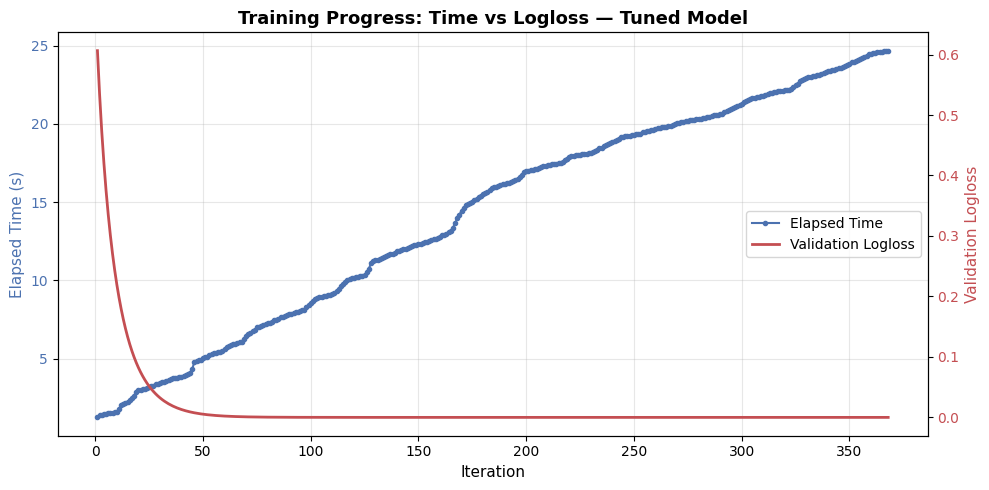

In [86]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# --- Timer & log ---
start_time = time.time()
iter_log = []

def timing_callback(env):
    iter_log.append({
        'iteration': env.iteration + 1,
        'elapsed': time.time() - start_time,
        'logloss': env.evaluation_result_list[0][2] if env.evaluation_result_list else None
    })

# --- Training ---
tuned_model.fit(
    X_train_fit_smote,
    y_train_fit_smote,
    eval_set=[(X_valid, y_valid)],
    eval_metric='binary_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        timing_callback
    ]
)

# --- Ringkasan waktu ---
df_time = pd.DataFrame(iter_log)
df_time['delta'] = df_time['elapsed'].diff()

print(f"\n=== TRAINING SUMMARY ===")
print(f"Total waktu     : {df_time['elapsed'].iloc[-1]:.2f} detik ({df_time['elapsed'].iloc[-1]/60:.2f} menit)")
print(f"Total iterasi   : {len(df_time)}")
print(f"Iterasi tercepat: {df_time['delta'].min()*1000:.2f} ms")
print(f"Iterasi terslow : {df_time['delta'].max()*1000:.2f} ms")
print(f"Rata-rata       : {df_time['delta'].mean()*1000:.2f} ms")
print(f"Best logloss    : {df_time['logloss'].min():.6f}")
print(f"Best iteration  : {tuned_model.best_iteration_}")

# --- Plot 2 sumbu: waktu kumulatif + logloss ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Sumbu kiri: elapsed time
line1, = ax1.plot(df_time['iteration'], df_time['elapsed'],
                  color='#4C72B0', marker='o', markersize=3,
                  linewidth=1.5, label='Elapsed Time')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Elapsed Time (s)', color='#4C72B0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.grid(alpha=0.3)

# Sumbu kanan: logloss
ax2 = ax1.twinx()
line2, = ax2.plot(df_time['iteration'], df_time['logloss'],
                  color='#C44E52', linewidth=2, label='Validation Logloss')
ax2.set_ylabel('Validation Logloss', color='#C44E52', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#C44E52')

# Legend gabungan
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True)

plt.title('Training Progress: Time vs Logloss — Tuned Model',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# k. Mengecek best iteration dan Best Score

In [87]:
# Menampilkan hasil akhir training model tuned
print("=== MODEL TUNED ===")
print("Best iteration :", tuned_model.best_iteration_)
print("Best score     :", tuned_model.best_score_)

=== MODEL TUNED ===
Best iteration : 368
Best score     : defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'binary_logloss': np.float64(7.549070814374381e-06)})})


# l. Mengecek hasil validation

In [88]:
# Menampilkan hasil validation model hasil tuning
print("=== VALIDATION HASIL TUNING ===")
print(
    tuned_model.best_score_
)

=== VALIDATION HASIL TUNING ===
defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'binary_logloss': np.float64(7.549070814374381e-06)})})


## 11. Evaluasi Model Tuned

 # a. Melakukan prediksi pada data testing

In [89]:
# Melakukan prediksi menggunakan model hasil tuning
y_pred_tuned = tuned_model.predict(X_test)

# Mengambil probabilitas kelas SSH-Bruteforce
y_pred_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

# b. Menghitung Accuracy, Precision, Recall, dan F1-Score

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("=== HASIL EVALUASI MODEL TUNED ===")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1-Score  : {f1_tuned:.4f}")

=== HASIL EVALUASI MODEL TUNED ===
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000


# c. Menghitung AUC

In [91]:
from sklearn.metrics import roc_auc_score

auc_tuned = roc_auc_score(
    y_test,
    y_pred_proba_tuned
)

print(f"AUC       : {auc_tuned:.4f}")

AUC       : 1.0000


# d. Membuat Confusion Matrix

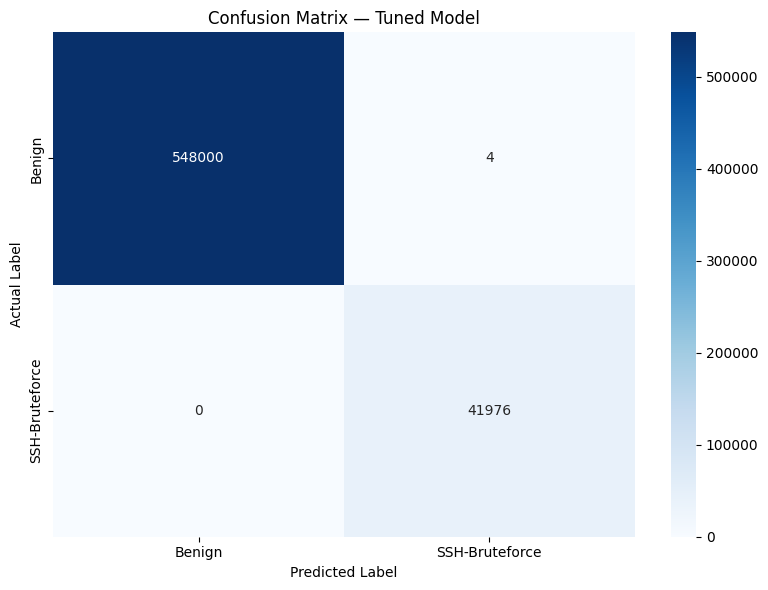

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'SSH-Bruteforce'],
            yticklabels=['Benign', 'SSH-Bruteforce'])
plt.title('Confusion Matrix — Tuned Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# e. Menampilkan Classification Report

In [93]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT — TUNED MODEL ===")

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=['Benign', 'SSH-Bruteforce'],
    digits=4
))

=== CLASSIFICATION REPORT — TUNED MODEL ===
                precision    recall  f1-score   support

        Benign     1.0000    1.0000    1.0000    548004
SSH-Bruteforce     0.9999    1.0000    1.0000     41976

      accuracy                         1.0000    589980
     macro avg     1.0000    1.0000    1.0000    589980
  weighted avg     1.0000    1.0000    1.0000    589980



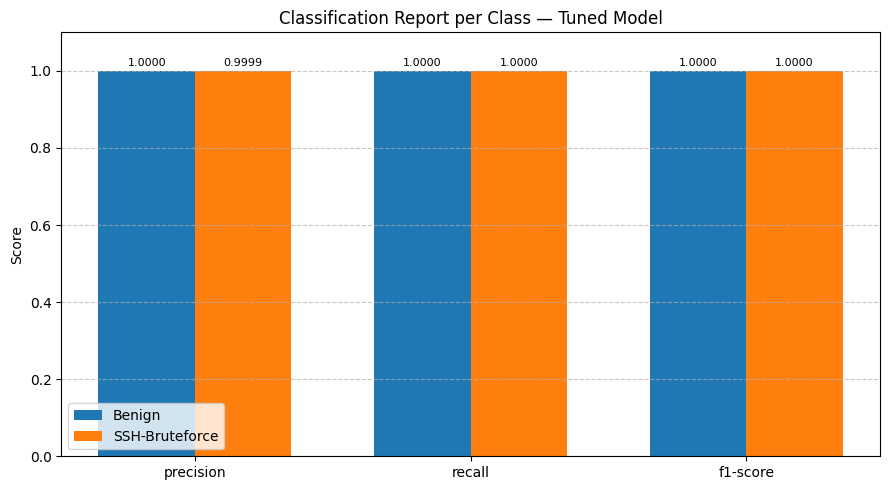

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

report = classification_report(
    y_test, y_pred_tuned,
    target_names=['Benign', 'SSH-Bruteforce'],
    output_dict=True
)
df_report = pd.DataFrame(report).transpose().iloc[:-3, :3]

metrics = df_report.columns
classes = df_report.index
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, cls in enumerate(classes):
    offset = (i - len(classes)/2 + 0.5) * width
    bars = ax.bar(x + offset, df_report.loc[cls], width, label=cls)
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Report per Class — Tuned Model')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# f. Ringkasan Evaluasi Model Tuned

In [95]:
print("=== RINGKASAN EVALUASI MODEL TUNED ===")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1-Score  : {f1_tuned:.4f}")
print(f"AUC       : {auc_tuned:.4f}")

=== RINGKASAN EVALUASI MODEL TUNED ===
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000
AUC       : 1.0000


# g. Membandingkan Baseline dan Tuned

In [96]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC'
    ],
    'Baseline': [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ],
    'Tuned': [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned,
        auc_tuned
    ]
})

print(comparison.to_string(index=False))

   Metric  Baseline    Tuned
 Accuracy  0.999980 0.999993
Precision  0.999714 0.999905
   Recall  1.000000 1.000000
 F1-Score  0.999857 0.999952
      AUC  1.000000 1.000000


# h. Membandingkan False Positive dan False Negative

In [97]:
# Mengambil nilai FP dan FN dari confusion matrix
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()

print("=== ERROR DETECTION ===")
print("False Positive:", fp_tuned)
print("False Negative:", fn_tuned)
print("True Positive :", tp_tuned)
print("True Negative :", tn_tuned)

=== ERROR DETECTION ===
False Positive: 4
False Negative: 0
True Positive : 41976
True Negative : 548000


## 12. Analisis Feature Importance Model Tuned

# a. Mengambil feature importance

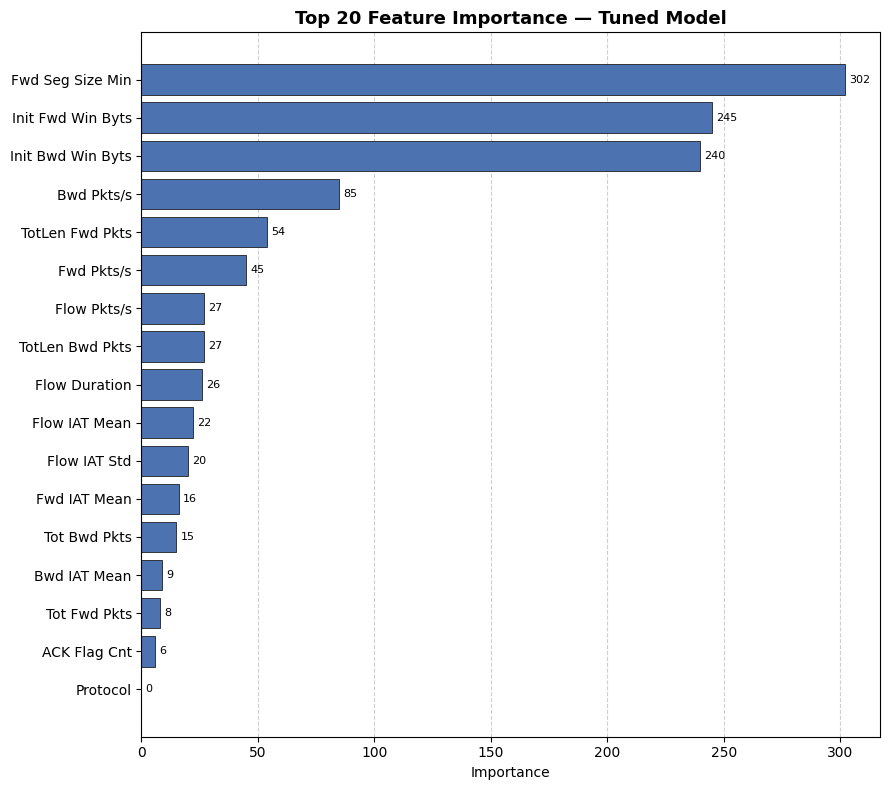

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train_fit_smote.columns,
    'Importance': tuned_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_n = 20
df_top = feature_importance.head(top_n).iloc[::-1]  # reverse biar terbesar di atas

plt.figure(figsize=(9, 8))
bars = plt.barh(df_top['Feature'], df_top['Importance'], color='#4C72B0',
                edgecolor='black', linewidth=0.5)
plt.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importance — Tuned Model',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

# b. Menampilkan Top 10 Feature

In [99]:
top10_features = feature_importance.head(10)

print("=== TOP 10 FEATURE IMPORTANCE ===")
print(top10_features.to_string(index=False))

=== TOP 10 FEATURE IMPORTANCE ===
          Feature  Importance
 Fwd Seg Size Min         302
Init Fwd Win Byts         245
Init Bwd Win Byts         240
       Bwd Pkts/s          85
  TotLen Fwd Pkts          54
       Fwd Pkts/s          45
      Flow Pkts/s          27
  TotLen Bwd Pkts          27
    Flow Duration          26
    Flow IAT Mean          22


# c. Menghitung persentase kontribusi

In [100]:
feature_importance['Percentage'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

print("=== TOP 10 FEATURE IMPORTANCE (%) ===")
print(
    feature_importance[
        ['Feature', 'Importance', 'Percentage']
    ].head(10).to_string(index=False)
)

=== TOP 10 FEATURE IMPORTANCE (%) ===
          Feature  Importance  Percentage
 Fwd Seg Size Min         302   26.329555
Init Fwd Win Byts         245   21.360070
Init Bwd Win Byts         240   20.924150
       Bwd Pkts/s          85    7.410636
  TotLen Fwd Pkts          54    4.707934
       Fwd Pkts/s          45    3.923278
      Flow Pkts/s          27    2.353967
  TotLen Bwd Pkts          27    2.353967
    Flow Duration          26    2.266783
    Flow IAT Mean          22    1.918047


# d. Cek dominasi feature

In [101]:
top4_percentage = feature_importance.head(4)['Percentage'].sum()

print(f"Kontribusi 4 fitur teratas : {top4_percentage:.2f}%")
print(f"Kontribusi fitur teratas   : {feature_importance.iloc[0]['Percentage']:.2f}%")

Kontribusi 4 fitur teratas : 76.02%
Kontribusi fitur teratas   : 26.33%


# 13. Simpan Model Final ke .pkl

# a. Siapkan komponen yang akan disimpan

In [102]:
import pickle

# Selected features yang digunakan model
selected_features = X_train_fit_smote.columns.tolist()

# Mapping label
label_encoder = {
    'Benign': 0,
    'SSH-Bruteforce': 1
}

# Gabungkan seluruh komponen model
model_package = {
    'model': tuned_model,
    'selected_features': selected_features,
    'label_encoder': label_encoder
}

# b. Simpan menjadi .pkl

In [103]:
# 1. Simpan model LightGBM
with open('lightgbm_model_v2.pkl', 'wb') as file:
    pickle.dump(tuned_model, file)

# 2. Simpan selected features
with open('selected_features_v2.pkl', 'wb') as file:
    pickle.dump(selected_features, file)

# 3. Simpan label encoder
with open('label_encoder_v2.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)

print("Semua file berhasil disimpan.")

Semua file berhasil disimpan.


# c. Cek isi .pkl

In [104]:
import os

files = [
    'lightgbm_model_v2.pkl',
    'selected_features_v2.pkl',
    'label_encoder_v2.pkl'
]

for file in files:
    print(f"{file} : {os.path.getsize(file) / 1024:.2f} KB")

lightgbm_model_v2.pkl : 213.07 KB
selected_features_v2.pkl : 0.28 KB
label_encoder_v2.pkl : 0.04 KB


# d. Tes .pkl untuk memastikan bisa digunakan kembali

In [105]:
import pickle
import pandas as pd

# Load ketiga file
with open('lightgbm_model_v2.pkl', 'rb') as file:
    model_loaded = pickle.load(file)

with open('selected_features_v2.pkl', 'rb') as file:
    features_loaded = pickle.load(file)

with open('label_encoder_v2.pkl', 'rb') as file:
    label_encoder_loaded = pickle.load(file)

# Ambil 5 data dari testing
X_sample = X_test[features_loaded].head(5)
y_sample = y_test.loc[X_sample.index]

# Prediksi
predictions = model_loaded.predict(X_sample)
probabilities = model_loaded.predict_proba(X_sample)[:, 1]

# Membalik mapping label
reverse_encoder = {
    value: key
    for key, value in label_encoder_loaded.items()
}

# Tampilkan nilai asli feature
print("=== NILAI ASLI FEATURE ===")
print(X_sample.to_string())

# Tampilkan hasil prediksi
print("\n=== HASIL PREDIKSI ===")

for i, index in enumerate(X_sample.index):
    actual = reverse_encoder[y_sample.loc[index]]
    predicted = reverse_encoder[predictions[i]]

    print(f"\nData {i+1}")
    print("Index          :", index)
    print("Label Asli     :", actual)
    print("Label Prediksi :", predicted)
    print("Probabilitas SSH :", f"{probabilities[i]:.6f}")

=== NILAI ASLI FEATURE ===
        Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts    Flow Pkts/s  Flow IAT Mean   Flow IAT Std  Fwd IAT Mean   Bwd IAT Mean     Fwd Pkts/s     Bwd Pkts/s  ACK Flag Cnt  Init Fwd Win Byts  Init Bwd Win Byts  Fwd Seg Size Min
314473         6              9             1             1                0                0  222222.222222       9.000000       0.000000           0.0       0.000000  111111.111111  111111.111111             1                241                230                32
552132         6        5893243            11            14             1461             3103       4.242146  245551.791667  426779.926540      589324.3  440296.230769       1.866544       2.375602             0               8192              62872                20
778159        17           1414             1             1               36              164    1414.427157    1414.000000       0.000000           0.0       0.000000  

# e. Load Selected Feature dan Label Encoder

In [106]:
import pickle

# Load selected features
with open('selected_features_v2.pkl', 'rb') as file:
    selected_features_loaded = pickle.load(file)

# Load label encoder
with open('label_encoder_v2.pkl', 'rb') as file:
    label_encoder_loaded = pickle.load(file)

print("=== SELECTED FEATURES ===")
print(f"Jumlah feature : {len(selected_features_loaded)}")

for i, feature in enumerate(selected_features_loaded, 1):
    print(f"{i}. {feature}")

print("\n=== LABEL ENCODER ===")
print(label_encoder_loaded)

=== SELECTED FEATURES ===
Jumlah feature : 17
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min

=== LABEL ENCODER ===
{'Benign': 0, 'SSH-Bruteforce': 1}


## 14. Load Traffic SSH Brute Force

# a. Upload dan Load CSV Traffic Hydra

In [107]:
import pandas as pd
import numpy as np
from google.colab import files

# Upload file CSV traffic SSH Brute Force
uploaded = files.upload()

Saving ssh_bruteforce_real.csv to ssh_bruteforce_real (1).csv


# b. Membaca File CSV

In [108]:
# Ambil nama file CSV yang di-upload
ssh_bruteforce_real = list(uploaded.keys())[0]

# Load dataset
df_hydra = pd.read_csv(ssh_bruteforce_real)

print("File yang digunakan :", ssh_bruteforce_real)
print("Dataset berhasil dimuat.")

File yang digunakan : ssh_bruteforce_real (1).csv
Dataset berhasil dimuat.


# c. Menampilkan Ukuran Dataset

In [109]:
# Menampilkan jumlah baris dan kolom
print("=== UKURAN DATASET TRAFFIC HYDRA ===")
print("Jumlah baris  :", df_hydra.shape[0])
print("Jumlah kolom  :", df_hydra.shape[1])

=== UKURAN DATASET TRAFFIC HYDRA ===
Jumlah baris  : 2833
Jumlah kolom  : 18


# d. Menampilkan Nama Kolom

In [110]:
# Menampilkan seluruh nama kolom
print("=== DAFTAR KOLOM ===")

for i, col in enumerate(df_hydra.columns, start=1):
    print(f"{i}. {col}")

=== DAFTAR KOLOM ===
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min
18. Label


# e. Menampilkan 5 Data Pertama

In [111]:
# Menampilkan 5 record pertama
print("=== 5 DATA PERTAMA ===")

display(df_hydra.head())

=== 5 DATA PERTAMA ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
0,6.0,8677968.0,27.0,21.0,3909.0,5078.0,5.531249,184637.617558,623500.051234,333768.000970,433854.842186,3.111327,2.419921,47.0,64240.0,65160.0,52.0,SSH-Bruteforce
1,6.0,4122759.0,23.0,20.0,3873.0,3922.0,10.429909,98160.925366,510884.510029,187398.130243,216933.363362,5.578788,4.851120,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
2,6.0,3892944.0,23.0,20.0,3873.0,3922.0,11.045625,92689.145179,535679.422440,176952.004433,204859.319486,5.908125,5.137500,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
3,6.0,92367.0,12.0,10.0,1227.0,1774.0,238.180302,4398.425420,10098.104297,8396.993984,10211.653180,129.916529,108.263774,21.0,64240.0,65160.0,52.0,SSH-Bruteforce
4,6.0,149160.0,10.0,10.0,1259.0,1774.0,134.084205,7850.521489,17133.222375,9393.559562,16569.561428,67.042102,67.042102,19.0,64240.0,65160.0,52.0,SSH-Bruteforce


# f. Ringkasan Struktur Dataset

In [112]:
# Menampilkan informasi dataset
print("=== INFORMASI DATASET ===")

df_hydra.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2833 entries, 0 to 2832
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Protocol           2833 non-null   float64
 1   Flow Duration      2833 non-null   float64
 2   Tot Fwd Pkts       2833 non-null   float64
 3   Tot Bwd Pkts       2833 non-null   float64
 4   TotLen Fwd Pkts    2833 non-null   float64
 5   TotLen Bwd Pkts    2833 non-null   float64
 6   Flow Pkts/s        2833 non-null   float64
 7   Flow IAT Mean      2833 non-null   float64
 8   Flow IAT Std       2833 non-null   float64
 9   Fwd IAT Mean       2833 non-null   float64
 10  Bwd IAT Mean       2833 non-null   float64
 11  Fwd Pkts/s         2833 non-null   float64
 12  Bwd Pkts/s         2833 non-null   float64
 13  ACK Flag Cnt       2833 non-null   float64
 14  Init Fwd Win Byts  2833 non-null   float64
 15  Init Bwd Win Byts  2833 non-null   float64
 16

# g. Menampilkan Statistik Dasar

In [113]:
# Statistik deskriptif untuk kolom numerik
print("=== STATISTIK DESKRIPTIF ===")

display(df_hydra.describe().T)

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
Protocol,2833.0,6.000000e+00,0.000000e+00,6.000000,6.000000,6.000000,6.000000e+00,6.000000e+00
Flow Duration,2833.0,2.825824e+06,3.158965e+06,24.000000,92269.000000,592263.000000,6.105701e+06,1.028563e+07
Tot Fwd Pkts,2833.0,8.993999e+00,3.795947e+00,1.000000,6.000000,11.000000,1.200000e+01,3.700000e+01
Tot Bwd Pkts,2833.0,8.141546e+00,4.331849e+00,1.000000,3.000000,10.000000,1.100000e+01,2.800000e+01
TotLen Fwd Pkts,2833.0,8.631430e+02,6.060674e+02,0.000000,156.000000,1227.000000,1.259000e+03,4.041000e+03
TotLen Bwd Pkts,2833.0,1.180799e+03,8.316992e+02,0.000000,168.000000,1774.000000,1.774000e+03,5.394000e+03
Flow Pkts/s,2833.0,1.711436e+02,1.574560e+03,0.738039,3.165692,37.982977,2.364269e+02,8.333333e+04
Flow IAT Mean,2833.0,2.438098e+05,3.209828e+05,24.080276,4487.242017,28704.255819,3.419536e+05,1.625931e+06
Flow IAT Std,2833.0,5.862880e+05,6.689915e+05,0.000000,10300.821756,83995.007856,9.461282e+05,3.634524e+06
Fwd IAT Mean,2833.0,4.512999e+05,5.558824e+05,0.000000,8562.988705,54239.537981,7.471419e+05,2.718147e+06


## 15. Pemeriksaan Traffic SSH Brute Force

# a. Mengecek Missing Value

In [115]:
# Mengecek jumlah missing value pada setiap kolom
print("=== MISSING VALUE ===")

missing_values = df_hydra.isnull().sum()

display(missing_values.to_frame(name="Jumlah Missing Value"))
print("Total missing value :", df_hydra.isnull().sum().sum())

=== MISSING VALUE ===


,Jumlah Missing Value
Protocol,0
Flow Duration,0
Tot Fwd Pkts,0
Tot Bwd Pkts,0
TotLen Fwd Pkts,0
TotLen Bwd Pkts,0
Flow Pkts/s,0
Flow IAT Mean,0
Flow IAT Std,0
Fwd IAT Mean,0


Total missing value : 0


# b. Mengecek Nilai Infinite

In [116]:
# Mengecek nilai infinite (+inf dan -inf)
print("=== INFINITE VALUE ===")

inf_values = np.isinf(df_hydra.select_dtypes(include=np.number)).sum()

display(inf_values.to_frame(name="Jumlah Infinite Value"))

print("Total infinite value :", inf_values.sum())

=== INFINITE VALUE ===


,Jumlah Infinite Value
Protocol,0
Flow Duration,0
Tot Fwd Pkts,0
Tot Bwd Pkts,0
TotLen Fwd Pkts,0
TotLen Bwd Pkts,0
Flow Pkts/s,0
Flow IAT Mean,0
Flow IAT Std,0
Fwd IAT Mean,0


Total infinite value : 0


# c. Mengecek Data Duplikat

In [118]:
# Mengecek jumlah data duplikat
print("=== DATA DUPLIKAT ===")

duplicate_count = df_hydra.duplicated().sum()

print("Jumlah data duplikat :", duplicate_count)
duplicate_percentage = (duplicate_count / len(df_hydra)) * 100

print(f"Persentase duplikat  : {duplicate_percentage:.2f}%")

=== DATA DUPLIKAT ===
Jumlah data duplikat : 0
Persentase duplikat  : 0.00%


# d. Mengecek Konsistensi Label

In [119]:
# Melihat nilai unik pada kolom Label
print("=== NILAI LABEL ===")

print(df_hydra["Label"].unique())

print("\n=== DISTRIBUSI LABEL ===")

display(df_hydra["Label"].value_counts())

=== NILAI LABEL ===
['SSH-Bruteforce']

=== DISTRIBUSI LABEL ===


,count
Label,
SSH-Bruteforce,2833


# e. Mengecek Label Kosong

In [120]:
# Mengecek apakah terdapat label kosong
print("=== LABEL KOSONG ===")

print("Jumlah label kosong :", df_hydra["Label"].isnull().sum())

=== LABEL KOSONG ===
Jumlah label kosong : 0


# f. Mengecek Nilai Numerik yang Tidak Valid

In [121]:
# Kolom numerik
numeric_columns = df_hydra.select_dtypes(include=np.number).columns

# Mengecek jumlah nilai negatif
negative_values = (df_hydra[numeric_columns] < 0).sum()

print("=== NILAI NEGATIF ===")

display(negative_values.to_frame(name="Jumlah Nilai Negatif"))

=== NILAI NEGATIF ===


,Jumlah Nilai Negatif
Protocol,0
Flow Duration,0
Tot Fwd Pkts,0
Tot Bwd Pkts,0
TotLen Fwd Pkts,0
TotLen Bwd Pkts,0
Flow Pkts/s,0
Flow IAT Mean,0
Flow IAT Std,0
Fwd IAT Mean,0


# g. Ringkasan Pemeriksaan

In [123]:
total_rows = len(df_hydra)
total_columns = len(df_hydra.columns)
total_missing = df_hydra.isnull().sum().sum()
total_inf = np.isinf(
    df_hydra.select_dtypes(include=np.number)
).sum().sum()
total_duplicate = df_hydra.duplicated().sum()
total_empty_label = df_hydra["Label"].isnull().sum()

print("=== RINGKASAN PEMERIKSAAN TRAFFIC HYDRA ===")
print(f"Jumlah record          : {total_rows}")
print(f"Jumlah kolom           : {total_columns}")
print(f"Total missing value    : {total_missing}")
print(f"Total infinite value   : {total_inf}")
print(f"Total data duplikat    : {total_duplicate}")
print(f"Total label kosong     : {total_empty_label}")

print("\n=== DISTRIBUSI LABEL ===")
print(df_hydra["Label"].value_counts())

=== RINGKASAN PEMERIKSAAN TRAFFIC HYDRA ===
Jumlah record          : 2833
Jumlah kolom           : 18
Total missing value    : 0
Total infinite value   : 0
Total data duplikat    : 0
Total label kosong     : 0

=== DISTRIBUSI LABEL ===
Label
SSH-Bruteforce    2833
Name: count, dtype: int64


## 16. Sesuaikan dengan 17 Fitur

# a. Load Selected Features Model

In [124]:
import pickle

# Load selected features dari model sebelumnya
with open('selected_features_v2.pkl', 'rb') as file:
    selected_features_loaded = pickle.load(file)

print("=== SELECTED FEATURES MODEL ===")
print(f"Jumlah feature : {len(selected_features_loaded)}")

for i, feature in enumerate(selected_features_loaded, start=1):
    print(f"{i}. {feature}")

=== SELECTED FEATURES MODEL ===
Jumlah feature : 17
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min


# b. Mengecek Ketersediaan 17 Fitur

In [125]:
# Mengecek fitur yang tersedia dan yang tidak tersedia
missing_features = [
    feature
    for feature in selected_features_loaded
    if feature not in df_hydra.columns
]

print("=== PEMERIKSAAN KETERSEDIAAN FEATURE ===")

if len(missing_features) == 0:
    print("Semua 17 feature tersedia di dataset traffic Hydra.")
else:
    print("Feature yang tidak ditemukan:")
    for feature in missing_features:
        print("-", feature)

=== PEMERIKSAAN KETERSEDIAAN FEATURE ===
Semua 17 feature tersedia di dataset traffic Hydra.


# c. Mengambil 17 Fitur

In [126]:
# Mengambil hanya 17 fitur yang digunakan model
X_hydra = df_hydra[selected_features_loaded].copy()

print("=== DATA FEATURE TRAFFIC HYDRA ===")
print("Ukuran X_hydra :", X_hydra.shape)

=== DATA FEATURE TRAFFIC HYDRA ===
Ukuran X_hydra : (2833, 17)


# d. Memastikan Urutan Feature

In [127]:
print("=== URUTAN FEATURE X_HYDRA ===")

for i, feature in enumerate(X_hydra.columns, start=1):
    print(f"{i}. {feature}")

=== URUTAN FEATURE X_HYDRA ===
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min


# e. Memastikan Label Tidak Masuk ke Feature

In [128]:
print("=== PEMERIKSAAN LABEL ===")

if 'Label' not in X_hydra.columns:
    print("Label tidak masuk ke X_hydra.")
else:
    print("PERINGATAN: Label masih masuk ke X_hydra!")

=== PEMERIKSAAN LABEL ===
Label tidak masuk ke X_hydra.


# f. Menampilkan 5 Data Feature

In [129]:
print("=== 5 DATA FEATURE TRAFFIC HYDRA ===")

display(X_hydra.head())

=== 5 DATA FEATURE TRAFFIC HYDRA ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min
0,6.0,8677968.0,27.0,21.0,3909.0,5078.0,5.531249,184637.617558,623500.051234,333768.000970,433854.842186,3.111327,2.419921,47.0,64240.0,65160.0,52.0
1,6.0,4122759.0,23.0,20.0,3873.0,3922.0,10.429909,98160.925366,510884.510029,187398.130243,216933.363362,5.578788,4.851120,42.0,64240.0,65160.0,52.0
2,6.0,3892944.0,23.0,20.0,3873.0,3922.0,11.045625,92689.145179,535679.422440,176952.004433,204859.319486,5.908125,5.137500,42.0,64240.0,65160.0,52.0
3,6.0,92367.0,12.0,10.0,1227.0,1774.0,238.180302,4398.425420,10098.104297,8396.993984,10211.653180,129.916529,108.263774,21.0,64240.0,65160.0,52.0
4,6.0,149160.0,10.0,10.0,1259.0,1774.0,134.084205,7850.521489,17133.222375,9393.559562,16569.561428,67.042102,67.042102,19.0,64240.0,65160.0,52.0


## 17. Pemberian Label Traffic SSH Brute Force

# a. Mengambil Label dari Dataset

In [130]:
# Mengambil kolom Label sebagai target
y_hydra = df_hydra["Label"].copy()

print("=== TARGET LABEL TRAFFIC HYDRA ===")
print("Jumlah data :", len(y_hydra))

=== TARGET LABEL TRAFFIC HYDRA ===
Jumlah data : 2833


# b. Mengecek Nilai Label

In [131]:
# Melihat seluruh nilai unik pada target
print("=== NILAI UNIK LABEL ===")

print(y_hydra.unique())

=== NILAI UNIK LABEL ===
['SSH-Bruteforce']


# c. Mengecek Distribusi Label

In [132]:
# Menghitung jumlah masing-masing label
print("=== DISTRIBUSI LABEL ===")

display(y_hydra.value_counts())

=== DISTRIBUSI LABEL ===


,count
Label,
SSH-Bruteforce,2833


# d. Mengecek Kesesuaian Jumlah Feature dan Label

In [139]:
# Memastikan jumlah data feature dan label sama
print("=== PEMERIKSAAN X DAN Y ===")

print("Jumlah data X_hydra :", len(X_hydra))
print("Jumlah data y_hydra :", len(y_hydra))

if len(X_hydra) == len(y_hydra):
    print("X_hydra dan y_hydra memiliki jumlah data yang sama.")
else:
    print("PERINGATAN: Jumlah data X_hydra dan y_hydra berbeda!")

=== PEMERIKSAAN X DAN Y ===
Jumlah data X_hydra : 2833
Jumlah data y_hydra : 2833
X_hydra dan y_hydra memiliki jumlah data yang sama.


# e. Melihat Pasangan Feature dan Label

In [140]:
# Menggabungkan feature dan label hanya untuk melihat hasil
hydra_check = X_hydra.copy()
hydra_check["Label"] = y_hydra.values

print("=== DATA FEATURE DAN LABEL ===")

display(hydra_check.head())

=== DATA FEATURE DAN LABEL ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
0,6.0,8677968.0,27.0,21.0,3909.0,5078.0,5.531249,184637.617558,623500.051234,333768.000970,433854.842186,3.111327,2.419921,47.0,64240.0,65160.0,52.0,SSH-Bruteforce
1,6.0,4122759.0,23.0,20.0,3873.0,3922.0,10.429909,98160.925366,510884.510029,187398.130243,216933.363362,5.578788,4.851120,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
2,6.0,3892944.0,23.0,20.0,3873.0,3922.0,11.045625,92689.145179,535679.422440,176952.004433,204859.319486,5.908125,5.137500,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
3,6.0,92367.0,12.0,10.0,1227.0,1774.0,238.180302,4398.425420,10098.104297,8396.993984,10211.653180,129.916529,108.263774,21.0,64240.0,65160.0,52.0,SSH-Bruteforce
4,6.0,149160.0,10.0,10.0,1259.0,1774.0,134.084205,7850.521489,17133.222375,9393.559562,16569.561428,67.042102,67.042102,19.0,64240.0,65160.0,52.0,SSH-Bruteforce


## 18. Evaluasi Model Lama pada Traffic Hydra

# a. Load Model V2

In [141]:
import pickle
import numpy as np
import pandas as pd

# Load model LightGBM V2
with open('lightgbm_model_v2.pkl', 'rb') as file:
    model_v2_loaded = pickle.load(file)

# Load selected features
with open('selected_features_v2.pkl', 'rb') as file:
    features_v2_loaded = pickle.load(file)

# Load label encoder
with open('label_encoder_v2.pkl', 'rb') as file:
    label_encoder_v2_loaded = pickle.load(file)

print("=== MODEL V2 BERHASIL DI-LOAD ===")
print("Jumlah feature :", len(features_v2_loaded))
print("Label encoder  :", label_encoder_v2_loaded)

=== MODEL V2 BERHASIL DI-LOAD ===
Jumlah feature : 17
Label encoder  : {'Benign': 0, 'SSH-Bruteforce': 1}


## b. Menyiapkan Feature dan Label

In [142]:
# Menggunakan feature traffic Hydra
X_hydra_test = X_hydra[features_v2_loaded].copy()

# Mengubah label teks menjadi angka sesuai mapping model
y_hydra_encoded = y_hydra.map(label_encoder_v2_loaded)

print("=== DATA UNTUK EVALUASI ===")
print("X_hydra_test :", X_hydra_test.shape)
print("y_hydra      :", y_hydra_encoded.shape)

print("\nDistribusi label:")
print(y_hydra_encoded.value_counts())

=== DATA UNTUK EVALUASI ===
X_hydra_test : (2833, 17)
y_hydra      : (2833,)

Distribusi label:
Label
1    2833
Name: count, dtype: int64


# c. Melakukan Prediksi Model V2

In [143]:
# Melakukan prediksi
y_pred_hydra = model_v2_loaded.predict(X_hydra_test)

# Mengambil probabilitas kelas SSH-Bruteforce
y_prob_hydra = model_v2_loaded.predict_proba(X_hydra_test)[:, 1]

print("=== PREDIKSI SELESAI ===")
print("Jumlah data diprediksi :", len(y_pred_hydra))

=== PREDIKSI SELESAI ===
Jumlah data diprediksi : 2833


# d. Melihat Distribusi Hasil Prediksi

In [144]:
# Mapping angka kembali ke nama label
reverse_label_encoder = {
    value: key
    for key, value in label_encoder_v2_loaded.items()
}

# Hitung jumlah hasil prediksi
prediction_counts = pd.Series(y_pred_hydra).map(
    reverse_label_encoder
).value_counts()

print("=== DISTRIBUSI HASIL PREDIKSI ===")

display(prediction_counts)

=== DISTRIBUSI HASIL PREDIKSI ===


,count
Benign,2833


# e. Membandingkan Label Asli dan Prediksi

In [145]:
# Membuat dataframe hasil prediksi
hydra_prediction_result = pd.DataFrame({
    'Actual': y_hydra_encoded.map(reverse_label_encoder).values,
    'Prediction': pd.Series(y_pred_hydra).map(reverse_label_encoder).values,
    'Probability_SSH_Bruteforce': y_prob_hydra
})

print("=== HASIL PREDIKSI TRAFFIC HYDRA ===")

display(hydra_prediction_result.head(10))

=== HASIL PREDIKSI TRAFFIC HYDRA ===


,Actual,Prediction,Probability_SSH_Bruteforce
0,SSH-Bruteforce,Benign,0.000494
1,SSH-Bruteforce,Benign,0.000494
2,SSH-Bruteforce,Benign,0.000494
3,SSH-Bruteforce,Benign,0.001113
4,SSH-Bruteforce,Benign,0.001170
5,SSH-Bruteforce,Benign,0.000019
6,SSH-Bruteforce,Benign,0.000019
7,SSH-Bruteforce,Benign,0.001113
8,SSH-Bruteforce,Benign,0.000066
9,SSH-Bruteforce,Benign,0.000066


# f. Menghitung Jumlah Traffic Hydra yang Berhasil Dideteksi

In [146]:
# Jumlah prediksi benar sebagai SSH-Bruteforce
detected_hydra = np.sum(
    (y_hydra_encoded == 1) & (y_pred_hydra == 1)
)

missed_hydra = np.sum(
    (y_hydra_encoded == 1) & (y_pred_hydra == 0)
)

total_hydra = len(y_hydra_encoded)

print("=== HASIL DETEKSI SSH BRUTE FORCE ===")
print("Total traffic Hydra          :", total_hydra)
print("Terdeteksi SSH-Bruteforce    :", detected_hydra)
print("Terdeteksi sebagai Benign     :", missed_hydra)

=== HASIL DETEKSI SSH BRUTE FORCE ===
Total traffic Hydra          : 2833
Terdeteksi SSH-Bruteforce    : 0
Terdeteksi sebagai Benign     : 2833


# g. Menghitung Detection Rate

In [147]:
# Detection Rate
detection_rate = (detected_hydra / total_hydra) * 100

print("=== DETECTION RATE ===")
print(f"Detection Rate : {detection_rate:.2f}%")

=== DETECTION RATE ===
Detection Rate : 0.00%


# h. Melihat Probabilitas Prediksi

In [148]:
print("=== STATISTIK PROBABILITAS SSH-BRUTEFORCE ===")

print(f"Minimum : {y_prob_hydra.min():.6f}")
print(f"Maximum : {y_prob_hydra.max():.6f}")
print(f"Mean    : {y_prob_hydra.mean():.6f}")
print(f"Median  : {np.median(y_prob_hydra):.6f}")

=== STATISTIK PROBABILITAS SSH-BRUTEFORCE ===
Minimum : 0.000019
Maximum : 0.024585
Mean    : 0.000508
Median  : 0.000068


# i. Menampilkan Traffic yang Salah Diklasifikasikan

In [149]:
# Mengambil data yang salah diklasifikasikan
misclassified_hydra = hydra_prediction_result[
    (hydra_prediction_result['Actual'] == 'SSH-Bruteforce') &
    (hydra_prediction_result['Prediction'] == 'Benign')
]

print("=== TRAFFIC HYDRA YANG DIPREDIKSI SEBAGAI BENIGN ===")
print("Jumlah :", len(misclassified_hydra))

display(misclassified_hydra.head(10))

=== TRAFFIC HYDRA YANG DIPREDIKSI SEBAGAI BENIGN ===
Jumlah : 2833


,Actual,Prediction,Probability_SSH_Bruteforce
0,SSH-Bruteforce,Benign,0.000494
1,SSH-Bruteforce,Benign,0.000494
2,SSH-Bruteforce,Benign,0.000494
3,SSH-Bruteforce,Benign,0.001113
4,SSH-Bruteforce,Benign,0.001170
5,SSH-Bruteforce,Benign,0.000019
6,SSH-Bruteforce,Benign,0.000019
7,SSH-Bruteforce,Benign,0.001113
8,SSH-Bruteforce,Benign,0.000066
9,SSH-Bruteforce,Benign,0.000066


## 19. Analisis Probabilitas Prediksi

# a. Statistik Probabilitas

In [150]:
print("=== STATISTIK PROBABILITAS SSH-BRUTEFORCE ===")

print(f"Minimum : {y_prob_hydra.min():.6f}")
print(f"Maximum : {y_prob_hydra.max():.6f}")
print(f"Mean    : {y_prob_hydra.mean():.6f}")
print(f"Median  : {np.median(y_prob_hydra):.6f}")
print(f"Std     : {y_prob_hydra.std():.6f}")

=== STATISTIK PROBABILITAS SSH-BRUTEFORCE ===
Minimum : 0.000019
Maximum : 0.024585
Mean    : 0.000508
Median  : 0.000068
Std     : 0.000682


# b. Menampilkan Probabilitas Tertinggi

In [151]:
# Mengurutkan probabilitas dari yang tertinggi
top_probability = hydra_prediction_result.sort_values(
    by="Probability_SSH_Bruteforce",
    ascending=False
).reset_index(drop=True)

print("=== 20 PROBABILITAS SSH-BRUTEFORCE TERTINGGI ===")

display(top_probability.head(20))

=== 20 PROBABILITAS SSH-BRUTEFORCE TERTINGGI ===


,Actual,Prediction,Probability_SSH_Bruteforce
0,SSH-Bruteforce,Benign,0.024585
1,SSH-Bruteforce,Benign,0.001589
2,SSH-Bruteforce,Benign,0.001403
3,SSH-Bruteforce,Benign,0.001403
4,SSH-Bruteforce,Benign,0.001403
5,SSH-Bruteforce,Benign,0.001403
6,SSH-Bruteforce,Benign,0.001403
7,SSH-Bruteforce,Benign,0.001403
8,SSH-Bruteforce,Benign,0.001403
9,SSH-Bruteforce,Benign,0.001403


# c. Menghitung Distribusi Probabilitas

In [153]:
# Membuat kategori probabilitas
probability_bins = pd.cut(
    y_prob_hydra,
    bins=[0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "0-1%",
        "1-5%",
        "5-10%",
        "10-25%",
        "25-50%",
        "50-75%",
        "75-100%"
    ],
    include_lowest=True
)

probability_distribution = probability_bins.value_counts(
)

print("=== DISTRIBUSI PROBABILITAS SSH-BRUTEFORCE ===")

display(
    probability_distribution.to_frame(
        name="Jumlah Traffic"
    )
)

=== DISTRIBUSI PROBABILITAS SSH-BRUTEFORCE ===


,Jumlah Traffic
0-1%,2832
1-5%,1
5-10%,0
10-25%,0
25-50%,0
50-75%,0
75-100%,0


# d. Menghitung Persentase Setiap Rentang Probabilitas

In [154]:
# Menghitung persentase setiap kategori
probability_percentage = (
    probability_distribution / len(y_prob_hydra) * 100
)

probability_summary = pd.DataFrame({
    "Jumlah Traffic": probability_distribution,
    "Persentase": probability_percentage.round(2)
})

print("=== PERSENTASE DISTRIBUSI PROBABILITAS ===")

display(probability_summary)

=== PERSENTASE DISTRIBUSI PROBABILITAS ===


,Jumlah Traffic,Persentase
0-1%,2832,99.96
1-5%,1,0.04
5-10%,0,0.00
10-25%,0,0.00
25-50%,0,0.00
50-75%,0,0.00
75-100%,0,0.00


# e. Mengecek Berapa Traffic yang Memiliki Probabilitas > 1%

In [155]:
# Jumlah traffic dengan probabilitas SSH-Bruteforce > 1%
count_above_1 = np.sum(y_prob_hydra > 0.01)

print("=== PROBABILITAS > 1% ===")
print("Jumlah traffic :", count_above_1)
print(f"Persentase     : {(count_above_1 / len(y_prob_hydra)) * 100:.2f}%")

=== PROBABILITAS > 1% ===
Jumlah traffic : 1
Persentase     : 0.04%


# f. Mengecek Probabilitas > 5%

In [156]:
# Jumlah traffic dengan probabilitas SSH-Bruteforce > 5%
count_above_5 = np.sum(y_prob_hydra > 0.05)

print("=== PROBABILITAS > 5% ===")
print("Jumlah traffic :", count_above_5)
print(f"Persentase     : {(count_above_5 / len(y_prob_hydra)) * 100:.2f}%")

=== PROBABILITAS > 5% ===
Jumlah traffic : 0
Persentase     : 0.00%


# g. Mengecek Probabilitas > 10%

In [157]:
# Jumlah traffic dengan probabilitas SSH-Bruteforce > 10%
count_above_10 = np.sum(y_prob_hydra > 0.10)

print("=== PROBABILITAS > 10% ===")
print("Jumlah traffic :", count_above_10)
print(f"Persentase     : {(count_above_10 / len(y_prob_hydra)) * 100:.2f}%")

=== PROBABILITAS > 10% ===
Jumlah traffic : 0
Persentase     : 0.00%


# h. Visualisasi Distribusi Probabilitas

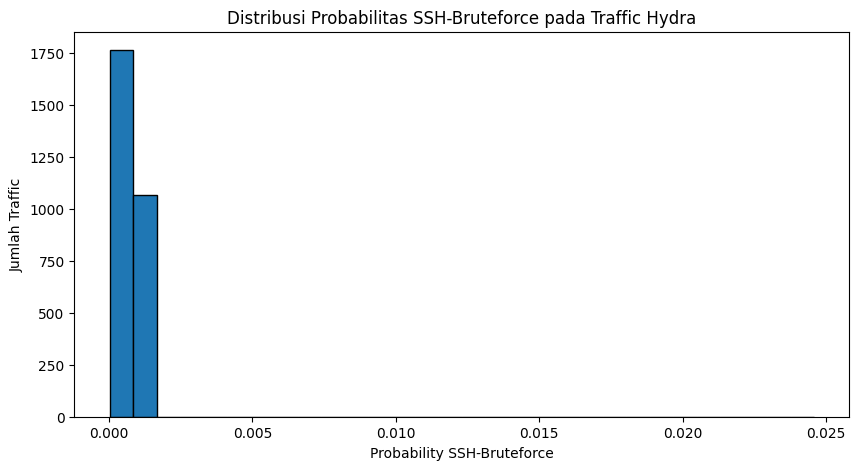

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    y_prob_hydra,
    bins=30,
    edgecolor='black'
)

plt.xlabel("Probability SSH-Bruteforce")
plt.ylabel("Jumlah Traffic")
plt.title("Distribusi Probabilitas SSH-Bruteforce pada Traffic Hydra")

plt.show()

# i. Visualisasi dengan Persentase

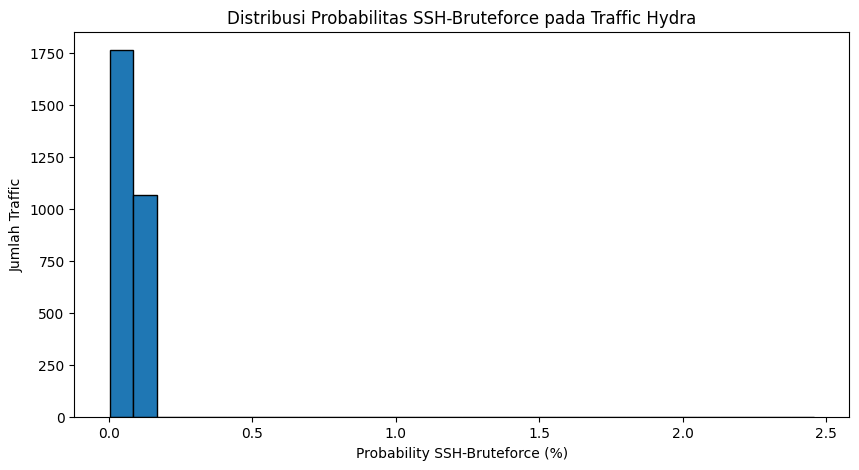

In [159]:
# Konversi probabilitas ke persen
probability_percent = y_prob_hydra * 100

plt.figure(figsize=(10, 5))

plt.hist(
    probability_percent,
    bins=30,
    edgecolor='black'
)

plt.xlabel("Probability SSH-Bruteforce (%)")
plt.ylabel("Jumlah Traffic")
plt.title("Distribusi Probabilitas SSH-Bruteforce pada Traffic Hydra")

plt.show()

# j. Ringkasan Tahap 19

In [160]:
print("=== RINGKASAN ANALISIS PROBABILITAS ===")
print(f"Total traffic                  : {len(y_prob_hydra)}")
print(f"Minimum probability            : {y_prob_hydra.min():.6f}")
print(f"Maximum probability            : {y_prob_hydra.max():.6f}")
print(f"Mean probability               : {y_prob_hydra.mean():.6f}")
print(f"Median probability             : {np.median(y_prob_hydra):.6f}")
print(f"Probability > 1%               : {count_above_1}")
print(f"Probability > 5%               : {count_above_5}")
print(f"Probability > 10%              : {count_above_10}")

=== RINGKASAN ANALISIS PROBABILITAS ===
Total traffic                  : 2833
Minimum probability            : 0.000019
Maximum probability            : 0.024585
Mean probability               : 0.000508
Median probability             : 0.000068
Probability > 1%               : 1
Probability > 5%               : 0
Probability > 10%              : 0


## 20. Load Traffic Benign Nyata

# a. Upload CSV Traffic Benign

In [161]:
import pandas as pd
import numpy as np
from google.colab import files

# Upload file CSV traffic benign
uploaded_benign = files.upload()

Saving benign_real.csv to benign_real.csv


# b. Membaca File CSV

In [162]:
# Mengambil nama file yang di-upload
benign_real = list(uploaded_benign.keys())[0]

# Load dataset traffic benign
df_benign = pd.read_csv(benign_real)

print("File yang digunakan :", benign_real)
print("Dataset berhasil dimuat.")

File yang digunakan : benign_real.csv
Dataset berhasil dimuat.


# c. Menampilkan Ukuran Dataset

In [163]:
print("=== UKURAN DATASET TRAFFIC BENIGN ===")

print("Jumlah baris  :", df_benign.shape[0])
print("Jumlah kolom  :", df_benign.shape[1])

=== UKURAN DATASET TRAFFIC BENIGN ===
Jumlah baris  : 1284
Jumlah kolom  : 18


# d. Menampilkan Nama Kolom

In [164]:
print("=== DAFTAR KOLOM ===")

for i, col in enumerate(df_benign.columns, start=1):
    print(f"{i}. {col}")

=== DAFTAR KOLOM ===
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min
18. Label


# e. Menampilkan 5 Data Pertama

In [165]:
print("=== 5 DATA PERTAMA ===")

display(df_benign.head())

=== 5 DATA PERTAMA ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
0,6.0,506464.0,20.0,19.0,3521.0,3830.0,77.004486,13328.000119,38649.244559,26656.000238,28056.118223,39.489480,37.515006,38.0,64240.0,65160.0,52.0,Benign
1,6.0,4159046.0,13.0,12.0,3189.0,2866.0,6.010994,173293.580612,818519.473737,346587.161223,378067.905253,3.125717,2.885277,24.0,64240.0,65160.0,52.0,Benign
2,6.0,419498.0,20.0,19.0,3521.0,4782.0,92.968262,11039.420178,34727.449666,22078.840356,23204.392857,47.676032,45.292230,38.0,64240.0,65160.0,52.0,Benign
3,6.0,388189.0,20.0,20.0,3521.0,3910.0,103.042590,9953.559973,27733.485237,20430.991524,20353.731356,51.521295,51.521295,39.0,64240.0,65160.0,52.0,Benign
4,6.0,416220.0,20.0,20.0,3521.0,3830.0,96.103022,10672.312516,36412.450655,21906.325692,21870.625646,48.051511,48.051511,39.0,64240.0,65160.0,52.0,Benign


# f. Menampilkan Informasi Dataset

In [166]:
print("=== INFORMASI DATASET ===")

df_benign.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Protocol           1284 non-null   float64
 1   Flow Duration      1284 non-null   float64
 2   Tot Fwd Pkts       1284 non-null   float64
 3   Tot Bwd Pkts       1284 non-null   float64
 4   TotLen Fwd Pkts    1284 non-null   float64
 5   TotLen Bwd Pkts    1284 non-null   float64
 6   Flow Pkts/s        1284 non-null   float64
 7   Flow IAT Mean      1284 non-null   float64
 8   Flow IAT Std       1284 non-null   float64
 9   Fwd IAT Mean       1284 non-null   float64
 10  Bwd IAT Mean       1284 non-null   float64
 11  Fwd Pkts/s         1284 non-null   float64
 12  Bwd Pkts/s         1284 non-null   float64
 13  ACK Flag Cnt       1284 non-null   float64
 14  Init Fwd Win Byts  1284 non-null   float64
 15  Init Bwd Win Byts  1284 non-null   float64
 16

# g. Menampilkan Statistik Deskriptif

In [167]:
print("=== STATISTIK DESKRIPTIF ===")

display(df_benign.describe().T)

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
Protocol,1284.0,6.000000,0.000000e+00,6.000000,6.000000,6.000000,6.000000,6.000000e+00
Flow Duration,1284.0,854494.894860,1.150527e+06,362.000000,359638.000000,427756.000000,599928.000000,5.339812e+06
Tot Fwd Pkts,1284.0,16.602804,5.402969e+00,1.000000,13.000000,20.000000,20.000000,2.300000e+01
Tot Bwd Pkts,1284.0,15.881620,5.362030e+00,1.000000,12.000000,19.000000,20.000000,2.300000e+01
TotLen Fwd Pkts,1284.0,3131.995327,9.522014e+02,0.000000,3189.000000,3521.000000,3521.000000,3.830000e+03
TotLen Bwd Pkts,1284.0,3252.682243,1.158383e+03,0.000000,2866.000000,3806.000000,3830.000000,4.782000e+03
Flow Pkts/s,1284.0,171.166139,4.048062e+02,2.453395,62.098955,90.603403,106.458693,6.944444e+03
Flow IAT Mean,1284.0,31434.863769,5.279083e+04,180.006027,9650.064534,11332.831885,16646.980925,5.094980e+05
Flow IAT Std,1284.0,128190.563413,2.368750e+05,0.000000,25932.983723,34361.666741,50415.443068,1.209619e+06
Fwd IAT Mean,1284.0,63025.964848,1.066970e+05,0.000000,19250.010189,22661.365961,33103.196244,1.018635e+06


## 21. Pemeriksaan Traffic Benign Nyata

# a. Mengecek Missing Value

In [168]:
# Mengecek jumlah missing value pada setiap kolom
print("=== MISSING VALUE ===")

missing_values_benign = df_benign.isnull().sum()

display(
    missing_values_benign.to_frame(
        name="Jumlah Missing Value"
    )
)

print("Total missing value :", df_benign.isnull().sum().sum())

=== MISSING VALUE ===


,Jumlah Missing Value
Protocol,0
Flow Duration,0
Tot Fwd Pkts,0
Tot Bwd Pkts,0
TotLen Fwd Pkts,0
TotLen Bwd Pkts,0
Flow Pkts/s,0
Flow IAT Mean,0
Flow IAT Std,0
Fwd IAT Mean,0


Total missing value : 0


# b. Mengecek Nilai Infinite

In [169]:
# Mengecek nilai infinite (+inf dan -inf)
print("=== INFINITE VALUE ===")

inf_values_benign = np.isinf(
    df_benign.select_dtypes(include=np.number)
).sum()

display(
    inf_values_benign.to_frame(
        name="Jumlah Infinite Value"
    )
)

print("Total infinite value :", inf_values_benign.sum())

=== INFINITE VALUE ===


,Jumlah Infinite Value
Protocol,0
Flow Duration,0
Tot Fwd Pkts,0
Tot Bwd Pkts,0
TotLen Fwd Pkts,0
TotLen Bwd Pkts,0
Flow Pkts/s,0
Flow IAT Mean,0
Flow IAT Std,0
Fwd IAT Mean,0


Total infinite value : 0


# c. Mengecek Data Duplikat

In [170]:
# Mengecek jumlah data duplikat
print("=== DATA DUPLIKAT ===")

duplicate_count_benign = df_benign.duplicated().sum()

print("Jumlah data duplikat :", duplicate_count_benign)

duplicate_percentage_benign = (
    duplicate_count_benign / len(df_benign)
) * 100

print(
    f"Persentase duplikat  : "
    f"{duplicate_percentage_benign:.2f}%"
)

=== DATA DUPLIKAT ===
Jumlah data duplikat : 0
Persentase duplikat  : 0.00%


# d. Mengecek Nilai Label

In [171]:
# Melihat nilai unik pada kolom Label
print("=== NILAI LABEL ===")

print(df_benign["Label"].unique())

=== NILAI LABEL ===
['Benign']


# e. Mengecek Distribusi Label

In [172]:
print("=== DISTRIBUSI LABEL ===")

display(
    df_benign["Label"].value_counts()
)

=== DISTRIBUSI LABEL ===


,count
Label,
Benign,1284


# f. Mengecek Label Kosong

In [173]:
# Mengecek apakah terdapat label kosong
print("=== LABEL KOSONG ===")

empty_label_benign = df_benign["Label"].isnull().sum()

print("Jumlah label kosong :", empty_label_benign)

=== LABEL KOSONG ===
Jumlah label kosong : 0


# g. Mengecek Nilai Negatif pada Fitur Numerik

In [174]:
# Kolom numerik
numeric_columns_benign = df_benign.select_dtypes(
    include=np.number
).columns

# Menghitung jumlah nilai negatif
negative_values_benign = (
    df_benign[numeric_columns_benign] < 0
).sum()

print("=== NILAI NEGATIF ===")

display(
    negative_values_benign.to_frame(
        name="Jumlah Nilai Negatif"
    )
)

=== NILAI NEGATIF ===


,Jumlah Nilai Negatif
Protocol,0
Flow Duration,0
Tot Fwd Pkts,0
Tot Bwd Pkts,0
TotLen Fwd Pkts,0
TotLen Bwd Pkts,0
Flow Pkts/s,0
Flow IAT Mean,0
Flow IAT Std,0
Fwd IAT Mean,0


# h. Ringkasan Pemeriksaan

In [176]:
total_rows_benign = len(df_benign)
total_columns_benign = len(df_benign.columns)
total_missing_benign = df_benign.isnull().sum().sum()

total_inf_benign = np.isinf(
    df_benign.select_dtypes(include=np.number)
).sum().sum()

total_duplicate_benign = df_benign.duplicated().sum()
total_empty_label_benign = df_benign["Label"].isnull().sum()

print("=== RINGKASAN PEMERIKSAAN TRAFFIC BENIGN ===")
print(f"Jumlah record          : {total_rows_benign}")
print(f"Jumlah kolom           : {total_columns_benign}")
print(f"Total missing value    : {total_missing_benign}")
print(f"Total infinite value   : {total_inf_benign}")
print(f"Total data duplikat    : {total_duplicate_benign}")
print(f"Total label kosong     : {total_empty_label_benign}")

print("\n=== DISTRIBUSI LABEL ===")
print(df_benign["Label"].value_counts())

=== RINGKASAN PEMERIKSAAN TRAFFIC BENIGN ===
Jumlah record          : 1284
Jumlah kolom           : 18
Total missing value    : 0
Total infinite value   : 0
Total data duplikat    : 0
Total label kosong     : 0

=== DISTRIBUSI LABEL ===
Label
Benign    1284
Name: count, dtype: int64


## 22. Sesuaikan Traffic Benign dengan 17 Fitur

# a. Mengecek Ketersediaan 17 Fitur

In [178]:
# Mengecek apakah seluruh feature model tersedia
missing_features_benign = [
    feature
    for feature in selected_features_loaded
    if feature not in df_benign.columns
]

print("=== PEMERIKSAAN KETERSEDIAAN FEATURE ===")

if len(missing_features_benign) == 0:
    print("Semua 17 feature tersedia di dataset traffic Benign.")
else:
    print("Feature yang tidak ditemukan:")
    for feature in missing_features_benign:
        print("-", feature)

=== PEMERIKSAAN KETERSEDIAAN FEATURE ===
Semua 17 feature tersedia di dataset traffic Benign.


# b. Mengambil 17 Fitur Benign

In [179]:
# Mengambil hanya 17 feature yang digunakan model
X_benign = df_benign[selected_features_loaded].copy()

print("=== DATA FEATURE TRAFFIC BENIGN ===")
print("Ukuran X_benign :", X_benign.shape)

=== DATA FEATURE TRAFFIC BENIGN ===
Ukuran X_benign : (1284, 17)


# c. Memastikan Urutan Feature

In [180]:
print("=== URUTAN FEATURE X_BENIGN ===")

for i, feature in enumerate(X_benign.columns, start=1):
    print(f"{i}. {feature}")

=== URUTAN FEATURE X_BENIGN ===
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min


# d. Memastikan Label Tidak Masuk ke Feature

In [181]:
print("=== PEMERIKSAAN LABEL ===")

if 'Label' not in X_benign.columns:
    print("Label tidak masuk ke X_benign.")
else:
    print("PERINGATAN: Label masih masuk ke X_benign!")

=== PEMERIKSAAN LABEL ===
Label tidak masuk ke X_benign.


# e. Menampilkan 5 Data Feature Benign

In [182]:
print("=== 5 DATA FEATURE TRAFFIC BENIGN ===")

display(X_benign.head())

=== 5 DATA FEATURE TRAFFIC BENIGN ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min
0,6.0,506464.0,20.0,19.0,3521.0,3830.0,77.004486,13328.000119,38649.244559,26656.000238,28056.118223,39.489480,37.515006,38.0,64240.0,65160.0,52.0
1,6.0,4159046.0,13.0,12.0,3189.0,2866.0,6.010994,173293.580612,818519.473737,346587.161223,378067.905253,3.125717,2.885277,24.0,64240.0,65160.0,52.0
2,6.0,419498.0,20.0,19.0,3521.0,4782.0,92.968262,11039.420178,34727.449666,22078.840356,23204.392857,47.676032,45.292230,38.0,64240.0,65160.0,52.0
3,6.0,388189.0,20.0,20.0,3521.0,3910.0,103.042590,9953.559973,27733.485237,20430.991524,20353.731356,51.521295,51.521295,39.0,64240.0,65160.0,52.0
4,6.0,416220.0,20.0,20.0,3521.0,3830.0,96.103022,10672.312516,36412.450655,21906.325692,21870.625646,48.051511,48.051511,39.0,64240.0,65160.0,52.0


# f. Memastikan Feature Benign dan Hydra Sama

In [183]:
print("=== PERBANDINGAN FEATURE HYDRA DAN BENIGN ===")

if list(X_hydra.columns) == list(X_benign.columns):
    print("Urutan dan nama 17 feature Hydra dan Benign sama.")
else:
    print("PERINGATAN: Feature Hydra dan Benign berbeda!")

=== PERBANDINGAN FEATURE HYDRA DAN BENIGN ===
Urutan dan nama 17 feature Hydra dan Benign sama.


## 23. Pemberian Label Traffic Benign

# a. Mengambil Label dari Dataset

In [185]:
# Mengambil kolom Label sebagai target
y_benign = df_benign["Label"].copy()

print("=== TARGET LABEL TRAFFIC BENIGN ===")
print("Jumlah data :", len(y_benign))

=== TARGET LABEL TRAFFIC BENIGN ===
Jumlah data : 1284


# b. Mengecek Nilai Label

In [186]:
# Melihat nilai unik pada target
print("=== NILAI UNIK LABEL ===")

print(y_benign.unique())

=== NILAI UNIK LABEL ===
['Benign']


# c. Mengecek Distribusi Label

In [187]:
print("=== DISTRIBUSI LABEL ===")

display(y_benign.value_counts())

=== DISTRIBUSI LABEL ===


,count
Label,
Benign,1284


# d. Mengecek Label Kosong

In [188]:
print("=== PEMERIKSAAN LABEL KOSONG ===")

print("Jumlah label kosong :", y_benign.isnull().sum())

=== PEMERIKSAAN LABEL KOSONG ===
Jumlah label kosong : 0


# e. Memastikan Jumlah Feature dan Label Sama

In [189]:
print("=== PEMERIKSAAN X DAN Y ===")

print("Jumlah data X_benign :", len(X_benign))
print("Jumlah data y_benign :", len(y_benign))

if len(X_benign) == len(y_benign):
    print("X_benign dan y_benign memiliki jumlah data yang sama.")
else:
    print("PERINGATAN: Jumlah data X_benign dan y_benign berbeda!")

=== PEMERIKSAAN X DAN Y ===
Jumlah data X_benign : 1284
Jumlah data y_benign : 1284
X_benign dan y_benign memiliki jumlah data yang sama.


# f. Melihat Pasangan Feature dan Label

In [190]:
# Menggabungkan feature dan label hanya untuk pengecekan
benign_check = X_benign.copy()
benign_check["Label"] = y_benign.values

print("=== DATA FEATURE DAN LABEL BENIGN ===")

display(benign_check.head())

=== DATA FEATURE DAN LABEL BENIGN ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
0,6.0,506464.0,20.0,19.0,3521.0,3830.0,77.004486,13328.000119,38649.244559,26656.000238,28056.118223,39.489480,37.515006,38.0,64240.0,65160.0,52.0,Benign
1,6.0,4159046.0,13.0,12.0,3189.0,2866.0,6.010994,173293.580612,818519.473737,346587.161223,378067.905253,3.125717,2.885277,24.0,64240.0,65160.0,52.0,Benign
2,6.0,419498.0,20.0,19.0,3521.0,4782.0,92.968262,11039.420178,34727.449666,22078.840356,23204.392857,47.676032,45.292230,38.0,64240.0,65160.0,52.0,Benign
3,6.0,388189.0,20.0,20.0,3521.0,3910.0,103.042590,9953.559973,27733.485237,20430.991524,20353.731356,51.521295,51.521295,39.0,64240.0,65160.0,52.0,Benign
4,6.0,416220.0,20.0,20.0,3521.0,3830.0,96.103022,10672.312516,36412.450655,21906.325692,21870.625646,48.051511,48.051511,39.0,64240.0,65160.0,52.0,Benign


## 24. Menggabungkan Traffic Hydra dan Benign

# a. Menggabungkan Feature

In [191]:
# Menggabungkan feature Hydra dan Benign
X_real = pd.concat(
    [X_hydra, X_benign],
    axis=0,
    ignore_index=True
)

print("=== DATASET FEATURE GABUNGAN ===")
print("Ukuran X_real :", X_real.shape)

=== DATASET FEATURE GABUNGAN ===
Ukuran X_real : (4117, 17)


# b. Menggabungkan Label

In [192]:
# Menggabungkan label Hydra dan Benign
y_real = pd.concat(
    [y_hydra, y_benign],
    axis=0,
    ignore_index=True
)

print("=== DATASET LABEL GABUNGAN ===")
print("Jumlah y_real :", len(y_real))

=== DATASET LABEL GABUNGAN ===
Jumlah y_real : 4117


# c. Mengecek Distribusi Label

In [193]:
print("=== DISTRIBUSI LABEL DATASET GABUNGAN ===")

display(y_real.value_counts())

=== DISTRIBUSI LABEL DATASET GABUNGAN ===


,count
Label,
SSH-Bruteforce,2833
Benign,1284


# d. Mengecek Persentase Kelas

In [194]:
print("=== PERSENTASE LABEL ===")

label_percentage = (
    y_real.value_counts(normalize=True) * 100
)

display(
    label_percentage.round(2).to_frame(
        name="Persentase (%)"
    )
)

=== PERSENTASE LABEL ===


,Persentase (%)
Label,
SSH-Bruteforce,68.81
Benign,31.19


# e. Mengecek Kesesuaian Feature dan Label

In [195]:
print("=== PEMERIKSAAN X DAN Y ===")

print("Jumlah X_real :", len(X_real))
print("Jumlah y_real :", len(y_real))

if len(X_real) == len(y_real):
    print("X_real dan y_real memiliki jumlah data yang sama.")
else:
    print("PERINGATAN: Jumlah X_real dan y_real berbeda!")

=== PEMERIKSAAN X DAN Y ===
Jumlah X_real : 4117
Jumlah y_real : 4117
X_real dan y_real memiliki jumlah data yang sama.


# f. Memastikan Urutan 17 Fitur

In [196]:
print("=== URUTAN FEATURE DATASET GABUNGAN ===")

for i, feature in enumerate(X_real.columns, start=1):
    print(f"{i}. {feature}")

=== URUTAN FEATURE DATASET GABUNGAN ===
1. Protocol
2. Flow Duration
3. Tot Fwd Pkts
4. Tot Bwd Pkts
5. TotLen Fwd Pkts
6. TotLen Bwd Pkts
7. Flow Pkts/s
8. Flow IAT Mean
9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min


# g. Membuat DataFrame Gabungan untuk Pengecekan

In [197]:
# Membuat dataframe gabungan feature + label
df_real = X_real.copy()
df_real["Label"] = y_real.values

print("=== DATASET GABUNGAN ===")
print("Ukuran df_real :", df_real.shape)

display(df_real.head())

=== DATASET GABUNGAN ===
Ukuran df_real : (4117, 18)


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
0,6.0,8677968.0,27.0,21.0,3909.0,5078.0,5.531249,184637.617558,623500.051234,333768.000970,433854.842186,3.111327,2.419921,47.0,64240.0,65160.0,52.0,SSH-Bruteforce
1,6.0,4122759.0,23.0,20.0,3873.0,3922.0,10.429909,98160.925366,510884.510029,187398.130243,216933.363362,5.578788,4.851120,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
2,6.0,3892944.0,23.0,20.0,3873.0,3922.0,11.045625,92689.145179,535679.422440,176952.004433,204859.319486,5.908125,5.137500,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
3,6.0,92367.0,12.0,10.0,1227.0,1774.0,238.180302,4398.425420,10098.104297,8396.993984,10211.653180,129.916529,108.263774,21.0,64240.0,65160.0,52.0,SSH-Bruteforce
4,6.0,149160.0,10.0,10.0,1259.0,1774.0,134.084205,7850.521489,17133.222375,9393.559562,16569.561428,67.042102,67.042102,19.0,64240.0,65160.0,52.0,SSH-Bruteforce


# h. Mengecek Data Awal dan Akhir

In [198]:
print("=== 5 DATA AWAL ===")
display(df_real.head())

print("\n=== 5 DATA AKHIR ===")
display(df_real.tail())

=== 5 DATA AWAL ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
0,6.0,8677968.0,27.0,21.0,3909.0,5078.0,5.531249,184637.617558,623500.051234,333768.000970,433854.842186,3.111327,2.419921,47.0,64240.0,65160.0,52.0,SSH-Bruteforce
1,6.0,4122759.0,23.0,20.0,3873.0,3922.0,10.429909,98160.925366,510884.510029,187398.130243,216933.363362,5.578788,4.851120,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
2,6.0,3892944.0,23.0,20.0,3873.0,3922.0,11.045625,92689.145179,535679.422440,176952.004433,204859.319486,5.908125,5.137500,42.0,64240.0,65160.0,52.0,SSH-Bruteforce
3,6.0,92367.0,12.0,10.0,1227.0,1774.0,238.180302,4398.425420,10098.104297,8396.993984,10211.653180,129.916529,108.263774,21.0,64240.0,65160.0,52.0,SSH-Bruteforce
4,6.0,149160.0,10.0,10.0,1259.0,1774.0,134.084205,7850.521489,17133.222375,9393.559562,16569.561428,67.042102,67.042102,19.0,64240.0,65160.0,52.0,SSH-Bruteforce



=== 5 DATA AKHIR ===


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Fwd Pkts/s,Bwd Pkts/s,ACK Flag Cnt,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Seg Size Min,Label
4112,6.0,2145977.0,13.0,12.0,3189.0,2866.0,11.649705,89415.709178,4.063307e+05,178831.418355,1.950473e+05,6.057847,5.591859,24.0,64240.0,65160.0,52.0,Benign
4113,6.0,4162554.0,13.0,13.0,3189.0,2866.0,6.246165,166502.161026,8.026340e+05,346879.502138,3.468478e+05,3.123083,3.123083,25.0,64240.0,65160.0,52.0,Benign
4114,6.0,392623.0,20.0,19.0,3521.0,4782.0,99.331929,10332.182834,3.328085e+04,20664.365668,2.176089e+04,50.939451,48.392478,38.0,64240.0,65160.0,52.0,Benign
4115,6.0,4100605.0,7.0,5.0,148.0,260.0,2.926397,372782.273726,1.209619e+06,683380.007744,1.025061e+06,1.707065,1.219332,12.0,501.0,500.0,52.0,Benign
4116,6.0,409457.0,20.0,19.0,3521.0,4782.0,95.248097,10775.183377,3.325857e+04,21550.366753,2.271606e+04,48.845178,46.402919,38.0,64240.0,65160.0,52.0,Benign


## 25. Persiapan Dataset untuk Retraining

# a. Memisahkan Feature dan Target

In [199]:
from sklearn.model_selection import train_test_split

print("=== DATASET SEBELUM SPLIT ===")
print("X_real :", X_real.shape)
print("y_real :", y_real.shape)

=== DATASET SEBELUM SPLIT ===
X_real : (4117, 17)
y_real : (4117,)


# b. Split Train dan Sementara

In [200]:
# Split 70% Train dan 30% sementara
X_train_real, X_temp_real, y_train_real, y_temp_real = train_test_split(
    X_real,
    y_real,
    test_size=0.30,
    random_state=42,
    stratify=y_real
)

print("=== HASIL SPLIT AWAL ===")
print("X_train_real :", X_train_real.shape)
print("X_temp_real  :", X_temp_real.shape)
print("y_train_real :", y_train_real.shape)
print("y_temp_real  :", y_temp_real.shape)

=== HASIL SPLIT AWAL ===
X_train_real : (2881, 17)
X_temp_real  : (1236, 17)
y_train_real : (2881,)
y_temp_real  : (1236,)


# c. Split Validation dan Test

In [201]:
# Membagi 30% sementara menjadi:
# 15% Validation dan 15% Test

X_val_real, X_test_real, y_val_real, y_test_real = train_test_split(
    X_temp_real,
    y_temp_real,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_real
)

print("=== HASIL SPLIT FINAL ===")
print("X_train_real :", X_train_real.shape)
print("X_val_real   :", X_val_real.shape)
print("X_test_real  :", X_test_real.shape)

print("y_train_real :", y_train_real.shape)
print("y_val_real   :", y_val_real.shape)
print("y_test_real  :", y_test_real.shape)

=== HASIL SPLIT FINAL ===
X_train_real : (2881, 17)
X_val_real   : (618, 17)
X_test_real  : (618, 17)
y_train_real : (2881,)
y_val_real   : (618,)
y_test_real  : (618,)


# d. Mengecek Distribusi Label pada Train

In [202]:
print("=== DISTRIBUSI LABEL TRAIN ===")

display(y_train_real.value_counts())

=== DISTRIBUSI LABEL TRAIN ===


,count
Label,
SSH-Bruteforce,1982
Benign,899


# e. Mengecek Distribusi Label Validation

In [203]:
print("=== DISTRIBUSI LABEL VALIDATION ===")

display(y_val_real.value_counts())

=== DISTRIBUSI LABEL VALIDATION ===


,count
Label,
SSH-Bruteforce,425
Benign,193


# f. Mengecek Distribusi Label Test

In [204]:
print("=== DISTRIBUSI LABEL TEST ===")

display(y_test_real.value_counts())

=== DISTRIBUSI LABEL TEST ===


,count
Label,
SSH-Bruteforce,426
Benign,192


# g. Membandingkan Persentase Ketiga Dataset

In [205]:
def show_distribution(name, y):
    distribution = (
        y.value_counts(normalize=True) * 100
    ).round(2)

    print(f"\n=== {name} ===")
    print(distribution)


show_distribution("DATASET AWAL", y_real)
show_distribution("TRAIN", y_train_real)
show_distribution("VALIDATION", y_val_real)
show_distribution("TEST", y_test_real)


=== DATASET AWAL ===
Label
SSH-Bruteforce    68.81
Benign            31.19
Name: proportion, dtype: float64

=== TRAIN ===
Label
SSH-Bruteforce    68.8
Benign            31.2
Name: proportion, dtype: float64

=== VALIDATION ===
Label
SSH-Bruteforce    68.77
Benign            31.23
Name: proportion, dtype: float64

=== TEST ===
Label
SSH-Bruteforce    68.93
Benign            31.07
Name: proportion, dtype: float64


# h. Pemeriksaan Jumlah Data

In [206]:
total_split = (
    len(X_train_real)
    + len(X_val_real)
    + len(X_test_real)
)

print("=== PEMERIKSAAN TOTAL DATA ===")
print("Dataset awal :", len(X_real))
print("Hasil split  :", total_split)

if total_split == len(X_real):
    print("Semua data berhasil terbagi tanpa kehilangan record.")
else:
    print("PERINGATAN: Jumlah data hasil split tidak sesuai!")

=== PEMERIKSAAN TOTAL DATA ===
Dataset awal : 4117
Hasil split  : 4117
Semua data berhasil terbagi tanpa kehilangan record.


## 26. Balancing Data Training dengan SMOTE

# a. Mengecek Distribusi Sebelum SMOTE

In [210]:
from imblearn.over_sampling import SMOTE

print("=== DISTRIBUSI TRAINING SEBELUM SMOTE ===")

display(y_train_real.value_counts())

print("=== PERSENTASE TRAINING SEBELUM SMOTE ===")

display(
    (
        y_train_real.value_counts(normalize=True) * 100
    ).round(2).to_frame(name="Persentase (%)")
)

=== DISTRIBUSI TRAINING SEBELUM SMOTE ===


,count
Label,
SSH-Bruteforce,1982
Benign,899


=== PERSENTASE TRAINING SEBELUM SMOTE ===


,Persentase (%)
Label,
SSH-Bruteforce,68.8
Benign,31.2


# b. Membuat SMOTE

In [211]:
# Membuat objek SMOTE
smote = SMOTE(
    random_state=42
)

print("SMOTE berhasil dibuat.")

SMOTE berhasil dibuat.


# c. Menerapkan SMOTE pada Training

In [212]:
# Melakukan oversampling hanya pada data training
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_real,
    y_train_real
)

print("=== HASIL SMOTE ===")
print("Sebelum SMOTE :", X_train_real.shape)
print("Setelah SMOTE :", X_train_smote.shape)

=== HASIL SMOTE ===
Sebelum SMOTE : (2881, 17)
Setelah SMOTE : (3964, 17)


# d. Mengecek Distribusi Setelah SMOTE

In [213]:
print("=== DISTRIBUSI TRAINING SETELAH SMOTE ===")

display(
    y_train_smote.value_counts()
)

=== DISTRIBUSI TRAINING SETELAH SMOTE ===


,count
Label,
SSH-Bruteforce,1982
Benign,1982


# e. Mengecek Persentase Setelah SMOTE

In [214]:
print("=== PERSENTASE TRAINING SETELAH SMOTE ===")

display(
    (
        y_train_smote.value_counts(normalize=True) * 100
    ).round(2).to_frame(name="Persentase (%)")
)

=== PERSENTASE TRAINING SETELAH SMOTE ===


,Persentase (%)
Label,
SSH-Bruteforce,50.0
Benign,50.0


# f. Memastikan Validation Tidak Berubah

In [215]:
print("=== VALIDATION SET ===")
print("X_val_real :", X_val_real.shape)
print("y_val_real :", y_val_real.shape)

display(y_val_real.value_counts())

=== VALIDATION SET ===
X_val_real : (618, 17)
y_val_real : (618,)


,count
Label,
SSH-Bruteforce,425
Benign,193


# g. Memastikan Test Tidak Berubah

In [216]:
print("=== TEST SET ===")
print("X_test_real :", X_test_real.shape)
print("y_test_real :", y_test_real.shape)

display(y_test_real.value_counts())

=== TEST SET ===
X_test_real : (618, 17)
y_test_real : (618,)


,count
Label,
SSH-Bruteforce,426
Benign,192


# h. Ringkasan Tahap 26

In [217]:
print("=== RINGKASAN BALANCING DATA ===")

print("\nTRAIN SEBELUM SMOTE")
print("X :", X_train_real.shape)
print(y_train_real.value_counts())

print("\nTRAIN SETELAH SMOTE")
print("X :", X_train_smote.shape)
print(y_train_smote.value_counts())

print("\nVALIDATION")
print("X :", X_val_real.shape)
print(y_val_real.value_counts())

print("\nTEST")
print("X :", X_test_real.shape)
print(y_test_real.value_counts())

=== RINGKASAN BALANCING DATA ===

TRAIN SEBELUM SMOTE
X : (2881, 17)
Label
SSH-Bruteforce    1982
Benign             899
Name: count, dtype: int64

TRAIN SETELAH SMOTE
X : (3964, 17)
Label
SSH-Bruteforce    1982
Benign            1982
Name: count, dtype: int64

VALIDATION
X : (618, 17)
Label
SSH-Bruteforce    425
Benign            193
Name: count, dtype: int64

TEST
X : (618, 17)
Label
SSH-Bruteforce    426
Benign            192
Name: count, dtype: int64


## 27. Encoding Label untuk Training LightGBM

# a. Mengecek Mapping Label Encoder Lama

In [218]:
print("=== MAPPING LABEL ENCODER V2 ===")

print(label_encoder_v2_loaded)

=== MAPPING LABEL ENCODER V2 ===
{'Benign': 0, 'SSH-Bruteforce': 1}


# b. Mengecek Label yang Digunakan Dataset

In [219]:
print("=== LABEL PADA DATA TRAINING ===")

print("Label sebelum encoding:")
print(y_train_smote.unique())

print("\nLabel Validation:")
print(y_val_real.unique())

print("\nLabel Test:")
print(y_test_real.unique())

=== LABEL PADA DATA TRAINING ===
Label sebelum encoding:
['SSH-Bruteforce' 'Benign']

Label Validation:
['Benign' 'SSH-Bruteforce']

Label Test:
['Benign' 'SSH-Bruteforce']


# c. Encoding Label Training

In [220]:
# Encoding label training hasil SMOTE
y_train_encoded = y_train_smote.map(
    label_encoder_v2_loaded
)

print("=== HASIL ENCODING TRAINING ===")

display(y_train_encoded.value_counts())

=== HASIL ENCODING TRAINING ===


,count
Label,
1,1982
0,1982


# d. Encoding Label Validation

In [221]:
# Encoding label validation
y_val_encoded = y_val_real.map(
    label_encoder_v2_loaded
)

print("=== HASIL ENCODING VALIDATION ===")

display(y_val_encoded.value_counts())

=== HASIL ENCODING VALIDATION ===


,count
Label,
1,425
0,193


# e. Encoding Label Test

In [222]:
# Encoding label test
y_test_encoded = y_test_real.map(
    label_encoder_v2_loaded
)

print("=== HASIL ENCODING TEST ===")

display(y_test_encoded.value_counts())

=== HASIL ENCODING TEST ===


,count
Label,
1,426
0,192


# f. Mengecek Apakah Ada Label yang Gagal Di-Encode

In [223]:
print("=== PEMERIKSAAN HASIL ENCODING ===")

print("Training - NaN :", y_train_encoded.isnull().sum())
print("Validation - NaN:", y_val_encoded.isnull().sum())
print("Test - NaN      :", y_test_encoded.isnull().sum())

=== PEMERIKSAAN HASIL ENCODING ===
Training - NaN : 0
Validation - NaN: 0
Test - NaN      : 0


# g. Mengubah Tipe Data Label

In [224]:
# Mengubah target menjadi integer
y_train_encoded = y_train_encoded.astype(int)
y_val_encoded = y_val_encoded.astype(int)
y_test_encoded = y_test_encoded.astype(int)

print("=== TIPE DATA TARGET ===")

print("y_train_encoded :", y_train_encoded.dtype)
print("y_val_encoded   :", y_val_encoded.dtype)
print("y_test_encoded  :", y_test_encoded.dtype)

=== TIPE DATA TARGET ===
y_train_encoded : int64
y_val_encoded   : int64
y_test_encoded  : int64


# h. Ringkasan Encoding

In [225]:
print("=== RINGKASAN ENCODING LABEL ===")

print("Mapping:")
for label, value in label_encoder_v2_loaded.items():
    print(f"{label} → {value}")

print("\nTraining:")
print("X :", X_train_smote.shape)
print("y :", y_train_encoded.shape)
print(y_train_encoded.value_counts())

print("\nValidation:")
print("X :", X_val_real.shape)
print("y :", y_val_encoded.shape)
print(y_val_encoded.value_counts())

print("\nTest:")
print("X :", X_test_real.shape)
print("y :", y_test_encoded.shape)
print(y_test_encoded.value_counts())

=== RINGKASAN ENCODING LABEL ===
Mapping:
Benign → 0
SSH-Bruteforce → 1

Training:
X : (3964, 17)
y : (3964,)
Label
1    1982
0    1982
Name: count, dtype: int64

Validation:
X : (618, 17)
y : (618,)
Label
1    425
0    193
Name: count, dtype: int64

Test:
X : (618, 17)
y : (618,)
Label
1    426
0    192
Name: count, dtype: int64


## 28. Training LightGBM V3

=== TRAINING SUMMARY ===
Total waktu     : 0.38 detik (0.01 menit)
Total iterasi   : 150
Iterasi tercepat: 0.57 ms
Iterasi terslow : 8.10 ms
Rata-rata       : 2.21 ms
Best logloss    : 0.016987
Best iteration  : 120


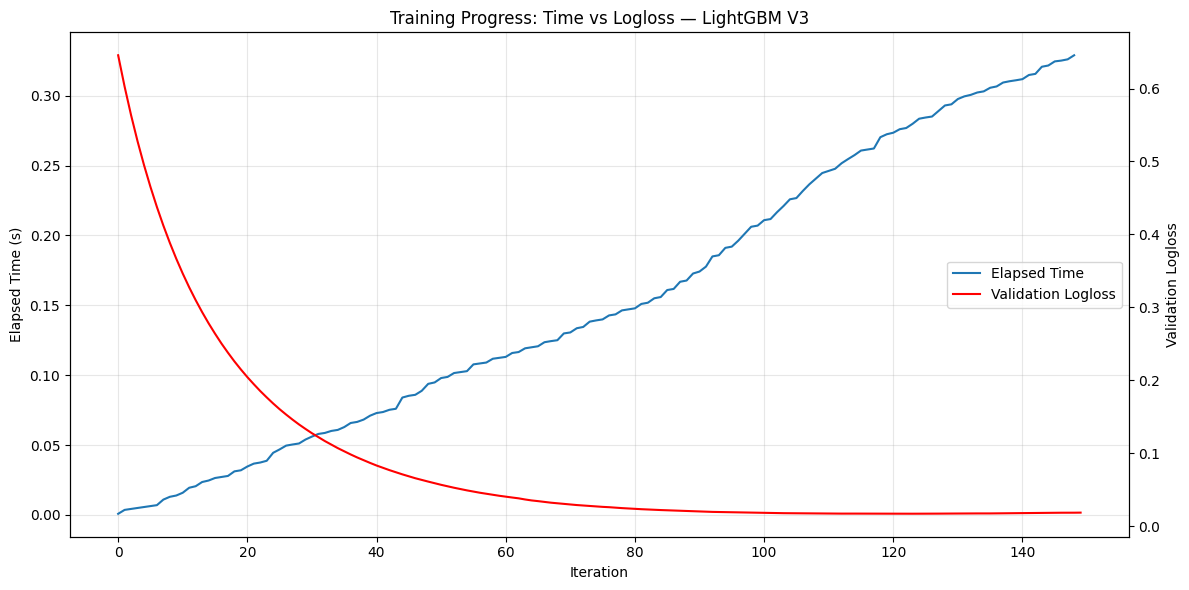

In [229]:
import lightgbm as lgb
import time
import matplotlib.pyplot as plt


# ============================================================
# 1. CALLBACK UNTUK MENCATAT WAKTU SETIAP ITERASI
# ============================================================

iteration_times = []
iteration_start = [None]


def timing_callback(env):

    # Sebelum iterasi
    if env.iteration == env.begin_iteration:
        iteration_start[0] = time.perf_counter()

    # Catat waktu setelah iterasi selesai
    else:
        current_time = time.perf_counter()

        iteration_time = current_time - iteration_start[0]
        iteration_times.append(iteration_time)

        iteration_start[0] = current_time


timing_callback.order = 10
timing_callback.before_iteration = False


# ============================================================
# 2. BUAT MODEL LIGHTGBM V3
# ============================================================

model_lgbm_v3 = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 3. TRAINING
# ============================================================

start_time = time.perf_counter()

model_lgbm_v3.fit(
    X_train_smote,
    y_train_encoded,

    eval_set=[
        (X_val_real, y_val_encoded)
    ],

    eval_names=[
        'validation'
    ],

    callbacks=[
        timing_callback,
        lgb.early_stopping(
            stopping_rounds=30,
            verbose=False
        )
    ]
)

total_time = time.perf_counter() - start_time


# ============================================================
# 4. AMBIL HASIL EVALUASI
# ============================================================

evals_result = model_lgbm_v3.evals_result_

validation_logloss = evals_result['validation']['binary_logloss']

best_iteration = model_lgbm_v3.best_iteration_
best_logloss = min(validation_logloss)


# ============================================================
# 5. SESUAIKAN JUMLAH ITERASI
# ============================================================

total_iterations = len(validation_logloss)

# Pastikan jumlah timing sesuai dengan jumlah iterasi
iteration_times = iteration_times[:total_iterations]

elapsed_time = []

total_elapsed = 0

for t in iteration_times:
    total_elapsed += t
    elapsed_time.append(total_elapsed)


# ============================================================
# 6. HITUNG STATISTIK WAKTU
# ============================================================

if len(iteration_times) > 0:

    fastest_iteration = min(iteration_times)
    slowest_iteration = max(iteration_times)
    average_iteration = sum(iteration_times) / len(iteration_times)

else:

    fastest_iteration = 0
    slowest_iteration = 0
    average_iteration = 0


# ============================================================
# 7. TRAINING SUMMARY
# ============================================================

print("=== TRAINING SUMMARY ===")

print(
    f"Total waktu     : "
    f"{total_time:.2f} detik "
    f"({total_time / 60:.2f} menit)"
)

print(
    f"Total iterasi   : "
    f"{total_iterations}"
)

print(
    f"Iterasi tercepat: "
    f"{fastest_iteration * 1000:.2f} ms"
)

print(
    f"Iterasi terslow : "
    f"{slowest_iteration * 1000:.2f} ms"
)

print(
    f"Rata-rata       : "
    f"{average_iteration * 1000:.2f} ms"
)

print(
    f"Best logloss    : "
    f"{best_logloss:.6f}"
)

print(
    f"Best iteration  : "
    f"{best_iteration}"
)


# ============================================================
# 8. GRAFIK TRAINING PROGRESS
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sumbu kiri: elapsed time
ax1.plot(
    range(len(elapsed_time)),
    elapsed_time,
    label='Elapsed Time'
)

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Elapsed Time (s)')
ax1.grid(True, alpha=0.3)


# Sumbu kanan: validation logloss
ax2 = ax1.twinx()

ax2.plot(
    range(len(validation_logloss)),
    validation_logloss,
    color='red',
    label='Validation Logloss'
)

ax2.set_ylabel('Validation Logloss')


# Judul
plt.title(
    'Training Progress: Time vs Logloss — LightGBM V3'
)


# Gabungkan legend kedua sumbu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)


plt.tight_layout()
plt.show()

## 29. Evaluasi LightGBM V3 pada Test Set

=== LIGHTGBM V3 - TEST RESULT ===
Accuracy  : 0.993528
Precision : 0.997642
Recall    : 0.992958
F1-Score  : 0.995294
AUC       : 0.998521

=== CONFUSION MATRIX ===
[[191   1]
 [  3 423]]

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Benign   0.984536  0.994792  0.989637       192
SSH-Bruteforce   0.997642  0.992958  0.995294       426

      accuracy                       0.993528       618
     macro avg   0.991089  0.993875  0.992466       618
  weighted avg   0.993570  0.993528  0.993537       618



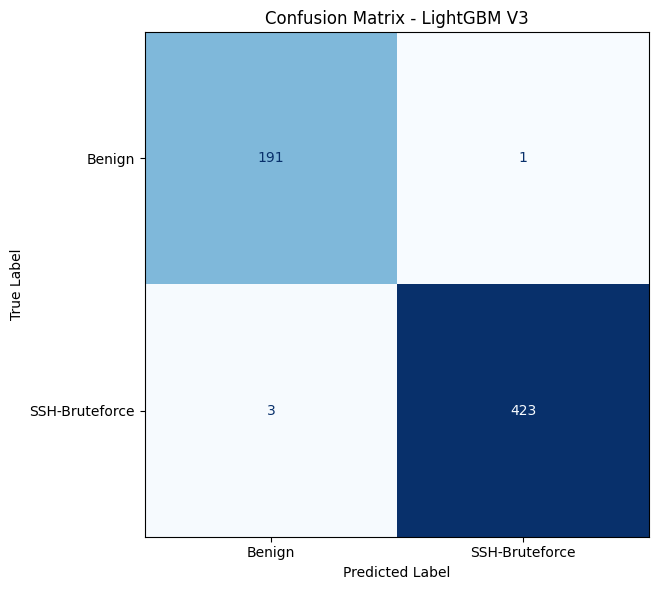

In [230]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. PREDIKSI TEST SET
# ============================================================

y_pred_v3 = model_lgbm_v3.predict(X_test_real)

y_prob_v3 = model_lgbm_v3.predict_proba(X_test_real)[:, 1]


# ============================================================
# 2. HITUNG METRIK
# ============================================================

accuracy_v3 = accuracy_score(
    y_test_encoded,
    y_pred_v3
)

precision_v3 = precision_score(
    y_test_encoded,
    y_pred_v3,
    zero_division=0
)

recall_v3 = recall_score(
    y_test_encoded,
    y_pred_v3,
    zero_division=0
)

f1_v3 = f1_score(
    y_test_encoded,
    y_pred_v3,
    zero_division=0
)

auc_v3 = roc_auc_score(
    y_test_encoded,
    y_prob_v3
)


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

cm_v3 = confusion_matrix(
    y_test_encoded,
    y_pred_v3
)


# ============================================================
# 4. HASIL METRIK
# ============================================================

print("=== LIGHTGBM V3 - TEST RESULT ===")

print(f"Accuracy  : {accuracy_v3:.6f}")
print(f"Precision : {precision_v3:.6f}")
print(f"Recall    : {recall_v3:.6f}")
print(f"F1-Score  : {f1_v3:.6f}")
print(f"AUC       : {auc_v3:.6f}")


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

print("\n=== CONFUSION MATRIX ===")
print(cm_v3)


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test_encoded,
        y_pred_v3,
        target_names=[
            'Benign',
            'SSH-Bruteforce'
        ],
        digits=6,
        zero_division=0
    )
)


# ============================================================
# 7. VISUALISASI CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v3,
    display_labels=[
        'Benign',
        'SSH-Bruteforce'
    ]
)

disp.plot(
    ax=ax,
    values_format='d',
    cmap='Blues',
    colorbar=False
)

plt.title('Confusion Matrix - LightGBM V3')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## 30. Evaluasi LightGBM V3 pada Seluruh Traffic Hydra Real

In [231]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. PERSIAPAN DATA HYDRA
# ============================================================

# Gunakan seluruh data Hydra real
X_hydra_v3 = df_hydra[selected_features_loaded].copy()

# Label asli
y_hydra_v3 = df_hydra["Label"].copy()

# Encode label menggunakan mapping yang sama
y_hydra_v3_encoded = y_hydra_v3.map(label_encoder_v2_loaded).astype(int)


print("=== HYDRA DATA ===")
print("X :", X_hydra_v3.shape)
print("y :", y_hydra_v3_encoded.shape)

print("\nLabel:")
print(y_hydra_v3.value_counts())


# ============================================================
# 2. PREDIKSI DENGAN LIGHTGBM V3
# ============================================================

y_pred_hydra_v3 = model_lgbm_v3.predict(
    X_hydra_v3
)

y_prob_hydra_v3 = model_lgbm_v3.predict_proba(
    X_hydra_v3
)[:, 1]


# ============================================================
# 3. HITUNG METRIK
# ============================================================

accuracy_hydra_v3 = accuracy_score(
    y_hydra_v3_encoded,
    y_pred_hydra_v3
)

precision_hydra_v3 = precision_score(
    y_hydra_v3_encoded,
    y_pred_hydra_v3,
    zero_division=0
)

recall_hydra_v3 = recall_score(
    y_hydra_v3_encoded,
    y_pred_hydra_v3,
    zero_division=0
)

f1_hydra_v3 = f1_score(
    y_hydra_v3_encoded,
    y_pred_hydra_v3,
    zero_division=0
)


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm_hydra_v3 = confusion_matrix(
    y_hydra_v3_encoded,
    y_pred_hydra_v3
)


# ============================================================
# 5. HASIL PREDIKSI
# ============================================================

total_hydra = len(y_hydra_v3_encoded)

hydra_detected = np.sum(y_pred_hydra_v3 == 1)

hydra_missed = np.sum(y_pred_hydra_v3 == 0)

detection_rate_hydra = (
    hydra_detected / total_hydra
) * 100

miss_rate_hydra = (
    hydra_missed / total_hydra
) * 100


# ============================================================
# 6. TAMPILKAN HASIL
# ============================================================

print("\n=== LIGHTGBM V3 - HYDRA REAL RESULT ===")

print(f"Total Hydra       : {total_hydra}")
print(f"Terdeteksi        : {hydra_detected}")
print(f"Tidak terdeteksi  : {hydra_missed}")

print(f"\nDetection Rate    : {detection_rate_hydra:.2f}%")
print(f"Miss Rate         : {miss_rate_hydra:.2f}%")

print("\n=== METRICS ===")

print(f"Accuracy          : {accuracy_hydra_v3:.6f}")
print(f"Precision         : {precision_hydra_v3:.6f}")
print(f"Recall            : {recall_hydra_v3:.6f}")
print(f"F1-Score          : {f1_hydra_v3:.6f}")


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

print("\n=== CONFUSION MATRIX ===")

print(cm_hydra_v3)


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_hydra_v3_encoded,
        y_pred_hydra_v3,
        target_names=[
            'Benign',
            'SSH-Bruteforce'
        ],
        digits=6,
        zero_division=0
    )
)

=== HYDRA DATA ===
X : (2833, 17)
y : (2833,)

Label:
Label
SSH-Bruteforce    2833
Name: count, dtype: int64

=== LIGHTGBM V3 - HYDRA REAL RESULT ===
Total Hydra       : 2833
Terdeteksi        : 2824
Tidak terdeteksi  : 9

Detection Rate    : 99.68%
Miss Rate         : 0.32%

=== METRICS ===
Accuracy          : 0.996823
Precision         : 1.000000
Recall            : 0.996823
F1-Score          : 0.998409

=== CONFUSION MATRIX ===
[[   0    0]
 [   9 2824]]

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Benign   0.000000  0.000000  0.000000         0
SSH-Bruteforce   1.000000  0.996823  0.998409      2833

      accuracy                       0.996823      2833
     macro avg   0.500000  0.498412  0.499205      2833
  weighted avg   1.000000  0.996823  0.998409      2833



## 31. Feature Importance LightGBM V3

=== FEATURE IMPORTANCE LIGHTGBM V3 ===
          Feature  Importance
  TotLen Fwd Pkts         347
Init Fwd Win Byts         154
     ACK Flag Cnt         111
     Tot Bwd Pkts          95
     Tot Fwd Pkts          68
    Flow Duration          68
     Fwd IAT Mean          62
     Bwd IAT Mean          57
Init Bwd Win Byts          38
      Flow Pkts/s          38
  TotLen Bwd Pkts          34
       Bwd Pkts/s          29
     Flow IAT Std          25
    Flow IAT Mean          22
       Fwd Pkts/s          16
         Protocol           0
 Fwd Seg Size Min           0

=== TOP 10 FEATURE IMPORTANCE ===
          Feature  Importance
  TotLen Fwd Pkts         347
Init Fwd Win Byts         154
     ACK Flag Cnt         111
     Tot Bwd Pkts          95
     Tot Fwd Pkts          68
    Flow Duration          68
     Fwd IAT Mean          62
     Bwd IAT Mean          57
Init Bwd Win Byts          38
      Flow Pkts/s          38


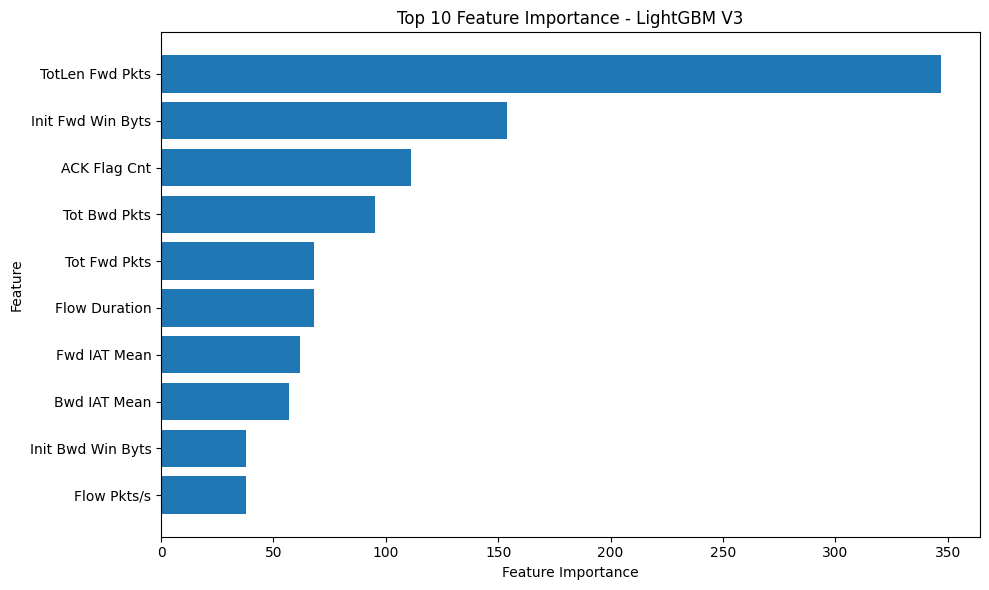

In [232]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. AMBIL FEATURE IMPORTANCE
# ============================================================

feature_importance_v3 = pd.DataFrame({
    'Feature': selected_features_loaded,
    'Importance': model_lgbm_v3.feature_importances_
})


# ============================================================
# 2. URUTKAN DARI IMPORTANCE TERBESAR
# ============================================================

feature_importance_v3 = feature_importance_v3.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 3. TAMPILKAN SELURUH FEATURE IMPORTANCE
# ============================================================

print("=== FEATURE IMPORTANCE LIGHTGBM V3 ===")

print(
    feature_importance_v3.to_string(index=False)
)


# ============================================================
# 4. TOP 10 FEATURE IMPORTANCE
# ============================================================

top10_feature_importance_v3 = feature_importance_v3.head(10)

print("\n=== TOP 10 FEATURE IMPORTANCE ===")

print(
    top10_feature_importance_v3.to_string(index=False)
)


# ============================================================
# 5. VISUALISASI TOP 10
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    top10_feature_importance_v3['Feature'][::-1],
    top10_feature_importance_v3['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Top 10 Feature Importance - LightGBM V3'
)

plt.tight_layout()
plt.show()

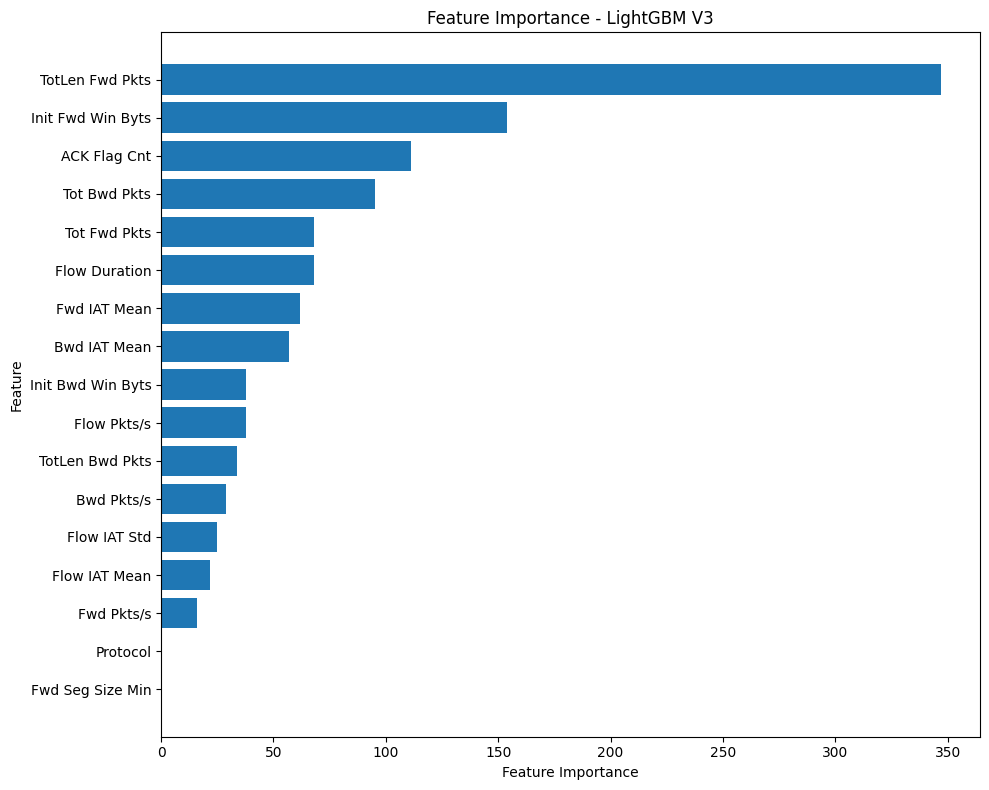

In [233]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_v3['Feature'][::-1],
    feature_importance_v3['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Feature Importance - LightGBM V3'
)

plt.tight_layout()
plt.show()

## 32. Hyperparameter Tuning LightGBM V3 dengan Optuna

In [234]:
import optuna
import lightgbm as lgb
import time


# ============================================================
# 1. OBJECTIVE FUNCTION
# ============================================================

def objective_v3(trial):

    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,

        # Hyperparameter yang dituning
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.10,
            log=True
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves',
            7,
            31
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            8
        ),

        'min_child_samples': trial.suggest_int(
            'min_child_samples',
            10,
            50
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            1.0
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            0.0,
            1.0
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            0.0,
            1.0
        )
    }


    # Membuat model
    model = lgb.LGBMClassifier(
        **params,
        n_estimators=400
    )


    # Training
    model.fit(
        X_train_smote,
        y_train_encoded,

        eval_set=[
            (X_val_real, y_val_encoded)
        ],

        eval_names=[
            'validation'
        ],

        callbacks=[
            lgb.early_stopping(
                stopping_rounds=30,
                verbose=False
            )
        ]
    )


    # Ambil best validation logloss
    best_logloss = min(
        model.evals_result_[
            'validation'
        ]['binary_logloss']
    )

    return best_logloss


# ============================================================
# 2. MEMULAI OPTUNA
# ============================================================

print("=== OPTUNA LIGHTGBM V3 ===")
print("Jumlah trials : 50")
print()


start_optuna = time.perf_counter()


study_v3 = optuna.create_study(
    direction='minimize',
    study_name='LightGBM_V3_Tuning'
)


study_v3.optimize(
    objective_v3,
    n_trials=50
)


total_optuna_time = (
    time.perf_counter() - start_optuna
)


# ============================================================
# 3. HASIL OPTUNA
# ============================================================

print("\n=== OPTUNA SUMMARY ===")

print(
    f"Total waktu : "
    f"{total_optuna_time:.2f} detik "
    f"({total_optuna_time / 60:.2f} menit)"
)

print(
    f"Best trial  : "
    f"{study_v3.best_trial.number}"
)

print(
    f"Best logloss: "
    f"{study_v3.best_value:.6f}"
)

print("\n=== BEST PARAMETERS ===")

for param, value in study_v3.best_params.items():
    print(f"{param}: {value}")

[I 2026-10-07 08:38:31,770] A new study created in memory with name: LightGBM_V3_Tuning


=== OPTUNA LIGHTGBM V3 ===
Jumlah trials : 50



[I 2026-10-07 08:38:32,358] Trial 0 finished with value: 0.018834976298158803 and parameters: {'learning_rate': 0.028411044210133674, 'num_leaves': 9, 'max_depth': 8, 'min_child_samples': 17, 'subsample': 0.8551943669051263, 'colsample_bytree': 0.7176909647044953, 'reg_alpha': 0.41202977967280763, 'reg_lambda': 0.08196298541368507}. Best is trial 0 with value: 0.018834976298158803.
[I 2026-10-07 08:38:33,181] Trial 1 finished with value: 0.02044564657831369 and parameters: {'learning_rate': 0.028174424105854606, 'num_leaves': 15, 'max_depth': 6, 'min_child_samples': 45, 'subsample': 0.9510234400980941, 'colsample_bytree': 0.944291761808759, 'reg_alpha': 0.494620071457353, 'reg_lambda': 0.8629587660355912}. Best is trial 0 with value: 0.018834976298158803.
[I 2026-10-07 08:38:34,261] Trial 2 finished with value: 0.019299343020244296 and parameters: {'learning_rate': 0.016551045326393607, 'num_leaves': 31, 'max_depth': 6, 'min_child_samples': 20, 'subsample': 0.7988853916639688, 'colsamp


=== OPTUNA SUMMARY ===
Total waktu : 18.31 detik (0.31 menit)
Best trial  : 47
Best logloss: 0.015680

=== BEST PARAMETERS ===
learning_rate: 0.026077331955255734
num_leaves: 23
max_depth: 8
min_child_samples: 11
subsample: 0.9800307011312461
colsample_bytree: 0.8744061406515142
reg_alpha: 0.11206551377234886
reg_lambda: 0.1608136813902836


## 33. Training LightGBM V3 Tuned

=== TRAINING SUMMARY V3 TUNED ===
Total waktu     : 0.96 detik (0.02 menit)
Total iterasi   : 271
Iterasi tercepat: 0.61 ms
Iterasi terslow : 73.63 ms
Rata-rata       : 2.73 ms
Best logloss    : 0.015680
Best iteration  : 241


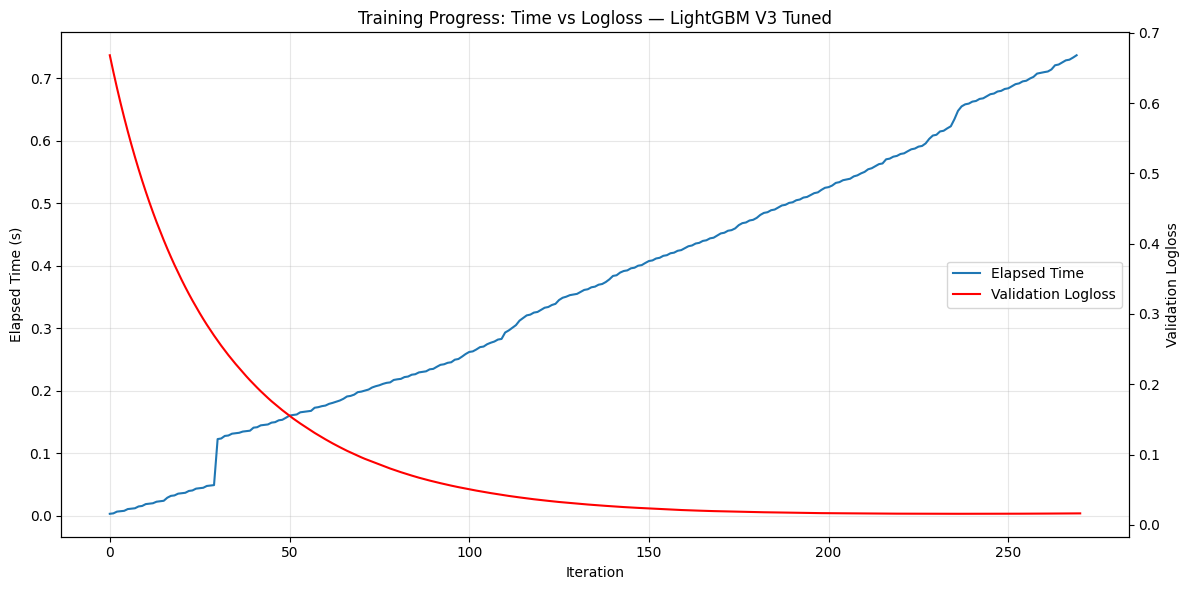

In [235]:
import lightgbm as lgb
import time
import matplotlib.pyplot as plt


# ============================================================
# 1. BEST PARAMETERS DARI OPTUNA
# ============================================================

best_params_v3 = {
    'objective': 'binary',
    'learning_rate': 0.026077331955255734,
    'num_leaves': 23,
    'max_depth': 8,
    'min_child_samples': 11,
    'subsample': 0.9800307011312461,
    'colsample_bytree': 0.8744061406515142,
    'reg_alpha': 0.11206551377234886,
    'reg_lambda': 0.1608136813902836,
    'random_state': 42,
    'n_jobs': -1
}


# ============================================================
# 2. CALLBACK UNTUK MENCATAT WAKTU SETIAP ITERASI
# ============================================================

iteration_times_v3_tuned = []
iteration_start_v3_tuned = [None]


def timing_callback_v3_tuned(env):

    if env.iteration == env.begin_iteration:
        iteration_start_v3_tuned[0] = time.perf_counter()

    else:
        current_time = time.perf_counter()

        iteration_time = (
            current_time -
            iteration_start_v3_tuned[0]
        )

        iteration_times_v3_tuned.append(
            iteration_time
        )

        iteration_start_v3_tuned[0] = current_time


timing_callback_v3_tuned.order = 10
timing_callback_v3_tuned.before_iteration = False


# ============================================================
# 3. BUAT MODEL TUNED
# ============================================================

model_lgbm_v3_tuned = lgb.LGBMClassifier(
    **best_params_v3,
    n_estimators=400
)


# ============================================================
# 4. TRAINING
# ============================================================

start_time_v3_tuned = time.perf_counter()

model_lgbm_v3_tuned.fit(
    X_train_smote,
    y_train_encoded,

    eval_set=[
        (X_val_real, y_val_encoded)
    ],

    eval_names=[
        'validation'
    ],

    callbacks=[
        timing_callback_v3_tuned,
        lgb.early_stopping(
            stopping_rounds=30,
            verbose=False
        )
    ]
)

total_time_v3_tuned = (
    time.perf_counter() -
    start_time_v3_tuned
)


# ============================================================
# 5. AMBIL HASIL EVALUASI
# ============================================================

evals_result_v3_tuned = (
    model_lgbm_v3_tuned.evals_result_
)

validation_logloss_v3_tuned = (
    evals_result_v3_tuned[
        'validation'
    ]['binary_logloss']
)

best_iteration_v3_tuned = (
    model_lgbm_v3_tuned.best_iteration_
)

best_logloss_v3_tuned = min(
    validation_logloss_v3_tuned
)


# ============================================================
# 6. JUMLAH ITERASI
# ============================================================

total_iterations_v3_tuned = (
    len(validation_logloss_v3_tuned)
)

iteration_times_v3_tuned = (
    iteration_times_v3_tuned[
        :total_iterations_v3_tuned
    ]
)


# ============================================================
# 7. HITUNG WAKTU ITERASI
# ============================================================

if len(iteration_times_v3_tuned) > 0:

    fastest_iteration_v3_tuned = min(
        iteration_times_v3_tuned
    )

    slowest_iteration_v3_tuned = max(
        iteration_times_v3_tuned
    )

    average_iteration_v3_tuned = (
        sum(iteration_times_v3_tuned) /
        len(iteration_times_v3_tuned)
    )

else:

    fastest_iteration_v3_tuned = 0
    slowest_iteration_v3_tuned = 0
    average_iteration_v3_tuned = 0


# ============================================================
# 8. TRAINING SUMMARY
# ============================================================

print("=== TRAINING SUMMARY V3 TUNED ===")

print(
    f"Total waktu     : "
    f"{total_time_v3_tuned:.2f} detik "
    f"({total_time_v3_tuned / 60:.2f} menit)"
)

print(
    f"Total iterasi   : "
    f"{total_iterations_v3_tuned}"
)

print(
    f"Iterasi tercepat: "
    f"{fastest_iteration_v3_tuned * 1000:.2f} ms"
)

print(
    f"Iterasi terslow : "
    f"{slowest_iteration_v3_tuned * 1000:.2f} ms"
)

print(
    f"Rata-rata       : "
    f"{average_iteration_v3_tuned * 1000:.2f} ms"
)

print(
    f"Best logloss    : "
    f"{best_logloss_v3_tuned:.6f}"
)

print(
    f"Best iteration  : "
    f"{best_iteration_v3_tuned}"
)


# ============================================================
# 9. ELAPSED TIME
# ============================================================

elapsed_time_v3_tuned = []

total_elapsed_v3_tuned = 0

for t in iteration_times_v3_tuned:

    total_elapsed_v3_tuned += t

    elapsed_time_v3_tuned.append(
        total_elapsed_v3_tuned
    )


# ============================================================
# 10. VISUALISASI TRAINING PROGRESS
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(12, 6)
)


# Elapsed time
ax1.plot(
    range(len(elapsed_time_v3_tuned)),
    elapsed_time_v3_tuned,
    label='Elapsed Time'
)

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Elapsed Time (s)')
ax1.grid(True, alpha=0.3)


# Validation logloss
ax2 = ax1.twinx()

ax2.plot(
    range(len(validation_logloss_v3_tuned)),
    validation_logloss_v3_tuned,
    color='red',
    label='Validation Logloss'
)

ax2.set_ylabel('Validation Logloss')


# Judul
plt.title(
    'Training Progress: Time vs Logloss — LightGBM V3 Tuned'
)


# Legend
lines1, labels1 = (
    ax1.get_legend_handles_labels()
)

lines2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)


plt.tight_layout()
plt.show()

## 34. Evaluasi LightGBM V3 Tuned pada Test Set

=== LIGHTGBM V3 TUNED - TEST RESULT ===
Accuracy  : 0.991909
Precision : 0.997636
Recall    : 0.990610
F1-Score  : 0.994111
AUC       : 0.998276

=== CONFUSION MATRIX ===
[[191   1]
 [  4 422]]

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Benign   0.979487  0.994792  0.987080       192
SSH-Bruteforce   0.997636  0.990610  0.994111       426

      accuracy                       0.991909       618
     macro avg   0.988562  0.992701  0.990595       618
  weighted avg   0.991997  0.991909  0.991926       618



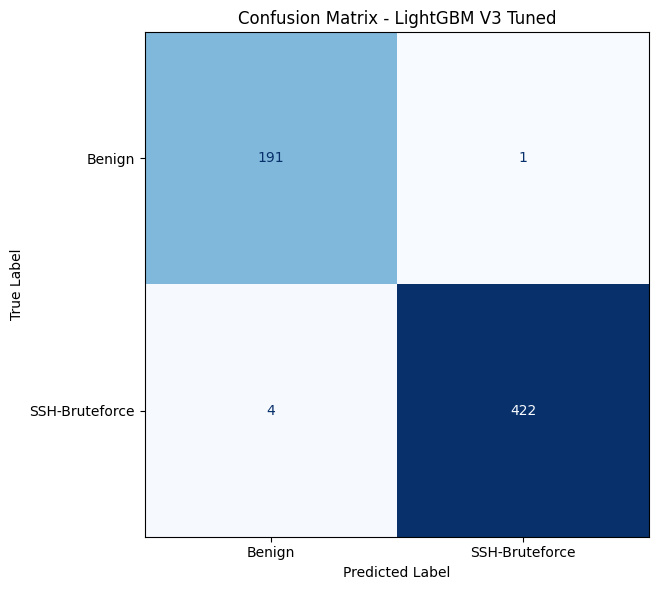

In [236]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. PREDIKSI TEST SET
# ============================================================

y_pred_v3_tuned = model_lgbm_v3_tuned.predict(
    X_test_real
)

y_prob_v3_tuned = model_lgbm_v3_tuned.predict_proba(
    X_test_real
)[:, 1]


# ============================================================
# 2. HITUNG METRIK
# ============================================================

accuracy_v3_tuned = accuracy_score(
    y_test_encoded,
    y_pred_v3_tuned
)

precision_v3_tuned = precision_score(
    y_test_encoded,
    y_pred_v3_tuned,
    zero_division=0
)

recall_v3_tuned = recall_score(
    y_test_encoded,
    y_pred_v3_tuned,
    zero_division=0
)

f1_v3_tuned = f1_score(
    y_test_encoded,
    y_pred_v3_tuned,
    zero_division=0
)

auc_v3_tuned = roc_auc_score(
    y_test_encoded,
    y_prob_v3_tuned
)


# ============================================================
# 3. CONFUSION MATRIX
# ============================================================

cm_v3_tuned = confusion_matrix(
    y_test_encoded,
    y_pred_v3_tuned
)


# ============================================================
# 4. HASIL METRIK
# ============================================================

print("=== LIGHTGBM V3 TUNED - TEST RESULT ===")

print(f"Accuracy  : {accuracy_v3_tuned:.6f}")
print(f"Precision : {precision_v3_tuned:.6f}")
print(f"Recall    : {recall_v3_tuned:.6f}")
print(f"F1-Score  : {f1_v3_tuned:.6f}")
print(f"AUC       : {auc_v3_tuned:.6f}")


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

print("\n=== CONFUSION MATRIX ===")

print(cm_v3_tuned)


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test_encoded,
        y_pred_v3_tuned,
        target_names=[
            'Benign',
            'SSH-Bruteforce'
        ],
        digits=6,
        zero_division=0
    )
)


# ============================================================
# 7. VISUALISASI CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v3_tuned,
    display_labels=[
        'Benign',
        'SSH-Bruteforce'
    ]
)

disp.plot(
    ax=ax,
    values_format='d',
    cmap='Blues',
    colorbar=False
)

plt.title(
    'Confusion Matrix - LightGBM V3 Tuned'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## 35. Evaluasi V3 Tuned pada Seluruh Traffic Hydra

In [237]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. PERSIAPAN DATA HYDRA
# ============================================================

X_hydra_v3_tuned = df_hydra[
    selected_features_loaded
].copy()

y_hydra_v3_tuned = df_hydra[
    "Label"
].copy()

y_hydra_v3_tuned_encoded = (
    y_hydra_v3_tuned
    .map(label_encoder_v2_loaded)
    .astype(int)
)


print("=== HYDRA DATA ===")

print(
    "X :",
    X_hydra_v3_tuned.shape
)

print(
    "y :",
    y_hydra_v3_tuned_encoded.shape
)

print("\nLabel:")

print(
    y_hydra_v3_tuned.value_counts()
)


# ============================================================
# 2. PREDIKSI DENGAN MODEL V3 TUNED
# ============================================================

y_pred_hydra_v3_tuned = (
    model_lgbm_v3_tuned.predict(
        X_hydra_v3_tuned
    )
)

y_prob_hydra_v3_tuned = (
    model_lgbm_v3_tuned.predict_proba(
        X_hydra_v3_tuned
    )[:, 1]
)


# ============================================================
# 3. HITUNG METRIK
# ============================================================

accuracy_hydra_v3_tuned = accuracy_score(
    y_hydra_v3_tuned_encoded,
    y_pred_hydra_v3_tuned
)

precision_hydra_v3_tuned = precision_score(
    y_hydra_v3_tuned_encoded,
    y_pred_hydra_v3_tuned,
    zero_division=0
)

recall_hydra_v3_tuned = recall_score(
    y_hydra_v3_tuned_encoded,
    y_pred_hydra_v3_tuned,
    zero_division=0
)

f1_hydra_v3_tuned = f1_score(
    y_hydra_v3_tuned_encoded,
    y_pred_hydra_v3_tuned,
    zero_division=0
)


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm_hydra_v3_tuned = confusion_matrix(
    y_hydra_v3_tuned_encoded,
    y_pred_hydra_v3_tuned
)


# ============================================================
# 5. HITUNG DETECTION RATE
# ============================================================

total_hydra_v3_tuned = len(
    y_hydra_v3_tuned_encoded
)

hydra_detected_v3_tuned = np.sum(
    y_pred_hydra_v3_tuned == 1
)

hydra_missed_v3_tuned = np.sum(
    y_pred_hydra_v3_tuned == 0
)

detection_rate_v3_tuned = (
    hydra_detected_v3_tuned /
    total_hydra_v3_tuned
) * 100

miss_rate_v3_tuned = (
    hydra_missed_v3_tuned /
    total_hydra_v3_tuned
) * 100


# ============================================================
# 6. HASIL UTAMA
# ============================================================

print("\n=== LIGHTGBM V3 TUNED - HYDRA REAL RESULT ===")

print(
    f"Total Hydra       : "
    f"{total_hydra_v3_tuned}"
)

print(
    f"Terdeteksi        : "
    f"{hydra_detected_v3_tuned}"
)

print(
    f"Tidak terdeteksi  : "
    f"{hydra_missed_v3_tuned}"
)

print(
    f"\nDetection Rate    : "
    f"{detection_rate_v3_tuned:.2f}%"
)

print(
    f"Miss Rate         : "
    f"{miss_rate_v3_tuned:.2f}%"
)


# ============================================================
# 7. METRICS
# ============================================================

print("\n=== METRICS ===")

print(
    f"Accuracy          : "
    f"{accuracy_hydra_v3_tuned:.6f}"
)

print(
    f"Precision         : "
    f"{precision_hydra_v3_tuned:.6f}"
)

print(
    f"Recall            : "
    f"{recall_hydra_v3_tuned:.6f}"
)

print(
    f"F1-Score          : "
    f"{f1_hydra_v3_tuned:.6f}"
)


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

print("\n=== CONFUSION MATRIX ===")

print(
    cm_hydra_v3_tuned
)


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\n=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_hydra_v3_tuned_encoded,
        y_pred_hydra_v3_tuned,
        target_names=[
            'Benign',
            'SSH-Bruteforce'
        ],
        digits=6,
        zero_division=0
    )
)

=== HYDRA DATA ===
X : (2833, 17)
y : (2833,)

Label:
Label
SSH-Bruteforce    2833
Name: count, dtype: int64

=== LIGHTGBM V3 TUNED - HYDRA REAL RESULT ===
Total Hydra       : 2833
Terdeteksi        : 2826
Tidak terdeteksi  : 7

Detection Rate    : 99.75%
Miss Rate         : 0.25%

=== METRICS ===
Accuracy          : 0.997529
Precision         : 1.000000
Recall            : 0.997529
F1-Score          : 0.998763

=== CONFUSION MATRIX ===
[[   0    0]
 [   7 2826]]

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Benign   0.000000  0.000000  0.000000         0
SSH-Bruteforce   1.000000  0.997529  0.998763      2833

      accuracy                       0.997529      2833
     macro avg   0.500000  0.498765  0.499382      2833
  weighted avg   1.000000  0.997529  0.998763      2833



## 36. Feature Importance LightGBM V3 Tuned

=== FEATURE IMPORTANCE LIGHTGBM V3 TUNED ===
          Feature  Importance
  TotLen Fwd Pkts         646
Init Fwd Win Byts         313
     Tot Fwd Pkts         285
     Tot Bwd Pkts         261
  TotLen Bwd Pkts         235
     Flow IAT Std         148
Init Bwd Win Byts         142
    Flow Duration         139
     Bwd IAT Mean         136
      Flow Pkts/s         128
    Flow IAT Mean         124
     ACK Flag Cnt         115
       Fwd Pkts/s         104
     Fwd IAT Mean          77
       Bwd Pkts/s          63
         Protocol           0
 Fwd Seg Size Min           0

=== TOP 10 FEATURE IMPORTANCE ===
          Feature  Importance
  TotLen Fwd Pkts         646
Init Fwd Win Byts         313
     Tot Fwd Pkts         285
     Tot Bwd Pkts         261
  TotLen Bwd Pkts         235
     Flow IAT Std         148
Init Bwd Win Byts         142
    Flow Duration         139
     Bwd IAT Mean         136
      Flow Pkts/s         128


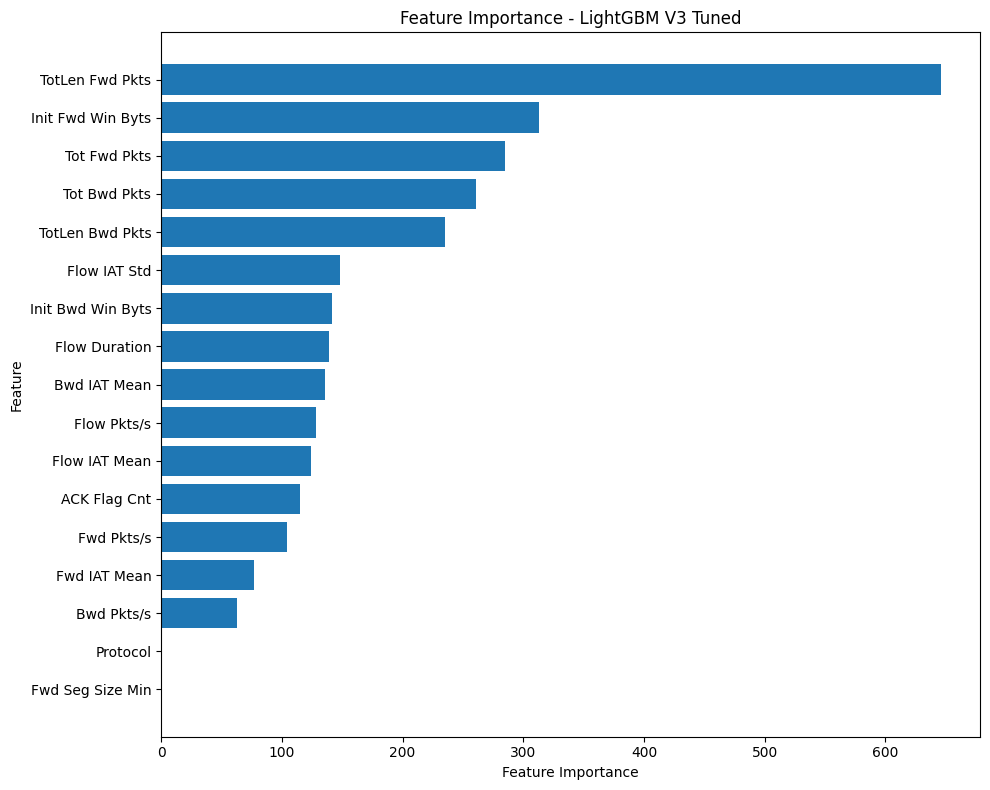

In [238]:
# ============================================================
# TAHAP 36 - FEATURE IMPORTANCE LIGHTGBM V3 TUNED
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. AMBIL FEATURE IMPORTANCE
# ============================================================

feature_importance_v3_tuned = pd.DataFrame({
    'Feature': selected_features_loaded,
    'Importance': model_lgbm_v3_tuned.feature_importances_
})


# ============================================================
# 2. URUTKAN DARI IMPORTANCE TERBESAR
# ============================================================

feature_importance_v3_tuned = (
    feature_importance_v3_tuned
    .sort_values(
        by='Importance',
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 3. TAMPILKAN SELURUH FEATURE IMPORTANCE
# ============================================================

print("=== FEATURE IMPORTANCE LIGHTGBM V3 TUNED ===")

print(
    feature_importance_v3_tuned.to_string(
        index=False
    )
)


# ============================================================
# 4. TOP 10 FEATURE IMPORTANCE
# ============================================================

top10_feature_importance_v3_tuned = (
    feature_importance_v3_tuned.head(10)
)

print("\n=== TOP 10 FEATURE IMPORTANCE ===")

print(
    top10_feature_importance_v3_tuned.to_string(
        index=False
    )
)


# ============================================================
# 5. VISUALISASI SELURUH FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_v3_tuned['Feature'][::-1],
    feature_importance_v3_tuned['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Feature Importance - LightGBM V3 Tuned'
)

plt.tight_layout()
plt.show()

## 37. Perbandingan V3 Baseline vs V3 Tuned

In [239]:
import pandas as pd


# ============================================================
# 1. DATA PERBANDINGAN
# ============================================================

comparison_v3 = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC',
        'Best Logloss',
        'Best Iteration',
        'Training Time (s)'
    ],

    'V3 Baseline': [
        accuracy_v3,
        precision_v3,
        recall_v3,
        f1_v3,
        auc_v3,
        best_logloss,
        best_iteration,
        total_time
    ],

    'V3 Tuned': [
        accuracy_v3_tuned,
        precision_v3_tuned,
        recall_v3_tuned,
        f1_v3_tuned,
        auc_v3_tuned,
        best_logloss_v3_tuned,
        best_iteration_v3_tuned,
        total_time_v3_tuned
    ]
})


# ============================================================
# 2. TAMBAHKAN PERUBAHAN
# ============================================================

comparison_v3['Perubahan'] = (
    comparison_v3['V3 Tuned'] -
    comparison_v3['V3 Baseline']
)


# ============================================================
# 3. TAMPILKAN HASIL
# ============================================================

print("=== PERBANDINGAN LIGHTGBM V3 ===")

print(
    comparison_v3.to_string(
        index=False
    )
)

=== PERBANDINGAN LIGHTGBM V3 ===
           Metric  V3 Baseline   V3 Tuned  Perubahan
         Accuracy     0.993528   0.991909  -0.001618
        Precision     0.997642   0.997636  -0.000006
           Recall     0.992958   0.990610  -0.002347
         F1-Score     0.995294   0.994111  -0.001183
              AUC     0.998521   0.998276  -0.000245
     Best Logloss     0.016987   0.015680  -0.001307
   Best Iteration   120.000000 241.000000 121.000000
Training Time (s)     0.378096   0.960873   0.582777


# a. Perbandingan Detectin Rate Hydra

In [240]:
hydra_comparison_v3 = pd.DataFrame({

    'Metric': [
        'Total Hydra',
        'Terdeteksi',
        'Tidak Terdeteksi',
        'Detection Rate',
        'Miss Rate'
    ],

    'V3 Baseline': [
        total_hydra,
        hydra_detected,
        hydra_missed,
        detection_rate_hydra,
        miss_rate_hydra
    ],

    'V3 Tuned': [
        total_hydra_v3_tuned,
        hydra_detected_v3_tuned,
        hydra_missed_v3_tuned,
        detection_rate_v3_tuned,
        miss_rate_v3_tuned
    ]
})


print("\n=== PERBANDINGAN DETECTION HYDRA ===")

print(
    hydra_comparison_v3.to_string(
        index=False
    )
)


=== PERBANDINGAN DETECTION HYDRA ===
          Metric  V3 Baseline    V3 Tuned
     Total Hydra  2833.000000 2833.000000
      Terdeteksi  2824.000000 2826.000000
Tidak Terdeteksi     9.000000    7.000000
  Detection Rate    99.682316   99.752912
       Miss Rate     0.317684    0.247088


## 38. Simpan Model V3 Final

In [241]:
import joblib
import os

# Nama file
model_path = "lightgbm_model_v3.pkl"
features_path = "selected_features_v3.pkl"
encoder_path = "label_encoder_v3.pkl"

# Simpan model LightGBM V3 Baseline
joblib.dump(model_lgbm_v3, model_path)

# Simpan daftar 17 fitur
joblib.dump(selected_features_loaded, features_path)

# Simpan mapping label
joblib.dump(label_encoder_v2_loaded, encoder_path)

# ============================================
# VERIFIKASI FILE
# ============================================

print("File berhasil disimpan:")

for file_path in [model_path, features_path, encoder_path]:
    if os.path.exists(file_path):
        print(f"✓ {file_path} ({os.path.getsize(file_path) / 1024:.2f} KB)")
    else:
        print(f"✗ {file_path} tidak ditemukan")

File berhasil disimpan:
✓ lightgbm_model_v3.pkl (157.66 KB)
✓ selected_features_v3.pkl (0.28 KB)
✓ label_encoder_v3.pkl (0.04 KB)


## 39. Test Load Model .pkl

In [242]:
import joblib
import os

# ============================================
# TAHAP 39 - TEST LOAD MODEL V3
# ============================================

model_path = "lightgbm_model_v3.pkl"
features_path = "selected_features_v3.pkl"
encoder_path = "label_encoder_v3.pkl"

# Load semua file
model_loaded = joblib.load(model_path)
selected_features_loaded_v3 = joblib.load(features_path)
label_encoder_loaded_v3 = joblib.load(encoder_path)

# ============================================
# CEK MODEL
# ============================================

print("=== MODEL ===")
print("Tipe model :", type(model_loaded))
print("Jumlah fitur model :", model_loaded.n_features_in_)

# ============================================
# CEK SELECTED FEATURES
# ============================================

print("\n=== SELECTED FEATURES ===")
print("Jumlah fitur :", len(selected_features_loaded_v3))

for i, feature in enumerate(selected_features_loaded_v3, start=1):
    print(f"{i:2}. {feature}")

# ============================================
# CEK LABEL ENCODER
# ============================================

print("\n=== LABEL ENCODER ===")
print("Mapping label:")

for label, value in label_encoder_loaded_v3.items():
    print(f"{label} -> {value}")

# ============================================
# VALIDASI
# ============================================

print("\n=== VALIDASI ===")

if model_loaded.n_features_in_ == len(selected_features_loaded_v3):
    print("✓ Jumlah fitur model sesuai dengan selected features")
else:
    print("✗ Jumlah fitur model tidak sesuai")

if (
    "Benign" in label_encoder_loaded_v3
    and "SSH-Bruteforce" in label_encoder_loaded_v3
):
    print("✓ Label Benign dan SSH-Bruteforce tersedia")
else:
    print("✗ Label tidak lengkap")

print("\n=== HASIL ===")
print("✓ Semua file .pkl berhasil di-load dan siap digunakan.")

=== MODEL ===
Tipe model : <class 'lightgbm.sklearn.LGBMClassifier'>
Jumlah fitur model : 17

=== SELECTED FEATURES ===
Jumlah fitur : 17
 1. Protocol
 2. Flow Duration
 3. Tot Fwd Pkts
 4. Tot Bwd Pkts
 5. TotLen Fwd Pkts
 6. TotLen Bwd Pkts
 7. Flow Pkts/s
 8. Flow IAT Mean
 9. Flow IAT Std
10. Fwd IAT Mean
11. Bwd IAT Mean
12. Fwd Pkts/s
13. Bwd Pkts/s
14. ACK Flag Cnt
15. Init Fwd Win Byts
16. Init Bwd Win Byts
17. Fwd Seg Size Min

=== LABEL ENCODER ===
Mapping label:
Benign -> 0
SSH-Bruteforce -> 1

=== VALIDASI ===
✓ Jumlah fitur model sesuai dengan selected features
✓ Label Benign dan SSH-Bruteforce tersedia

=== HASIL ===
✓ Semua file .pkl berhasil di-load dan siap digunakan.


In [243]:
from sklearn.metrics import classification_report

# ============================================
# 1. SEBELUM LOAD
# ============================================

y_pred_before = model_lgbm_v3.predict(X_test_real)

print("=" * 60)
print("CLASSIFICATION REPORT - SEBELUM LOAD")
print("=" * 60)

print(
    classification_report(
        y_test_encoded,
        y_pred_before,
        target_names=["Benign", "SSH-Bruteforce"],
        digits=4
    )
)


# ============================================
# 2. LOAD MODEL
# ============================================

model_loaded = joblib.load("lightgbm_model_v3.pkl")
selected_features_loaded_v3 = joblib.load("selected_features_v3.pkl")
label_encoder_loaded_v3 = joblib.load("label_encoder_v3.pkl")


# ============================================
# 3. SETELAH LOAD
# ============================================

# Pastikan urutan fitur sesuai dengan model
X_test_loaded = X_test_real[selected_features_loaded_v3].copy()

y_pred_after = model_loaded.predict(X_test_loaded)

print("=" * 60)
print("CLASSIFICATION REPORT - SETELAH LOAD")
print("=" * 60)

print(
    classification_report(
        y_test_encoded,
        y_pred_after,
        target_names=["Benign", "SSH-Bruteforce"],
        digits=4
    )
)


# ============================================
# 4. CEK APAKAH HASIL SAMA
# ============================================

print("=" * 60)
print("VERIFIKASI HASIL")
print("=" * 60)

if (y_pred_before == y_pred_after).all():
    print("✓ Prediksi sebelum dan setelah load SAMA")
else:
    print("✗ Prediksi sebelum dan setelah load BERBEDA")

CLASSIFICATION REPORT - SEBELUM LOAD
                precision    recall  f1-score   support

        Benign     0.9845    0.9948    0.9896       192
SSH-Bruteforce     0.9976    0.9930    0.9953       426

      accuracy                         0.9935       618
     macro avg     0.9911    0.9939    0.9925       618
  weighted avg     0.9936    0.9935    0.9935       618

CLASSIFICATION REPORT - SETELAH LOAD
                precision    recall  f1-score   support

        Benign     0.9845    0.9948    0.9896       192
SSH-Bruteforce     0.9976    0.9930    0.9953       426

      accuracy                         0.9935       618
     macro avg     0.9911    0.9939    0.9925       618
  weighted avg     0.9936    0.9935    0.9935       618

VERIFIKASI HASIL
✓ Prediksi sebelum dan setelah load SAMA


In [244]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ============================================
# HYDRA DAN BENIGN SECARA TERPISAH
# ============================================

# Pastikan urutan fitur sesuai dengan model
X_hydra_loaded = X_hydra[selected_features_loaded_v3].copy()
X_benign_loaded = X_benign[selected_features_loaded_v3].copy()


# ============================================
# 1. TEST HYDRA
# ============================================

y_hydra_encoded = y_hydra.map(label_encoder_loaded_v3).astype(int)

y_pred_hydra_loaded = model_loaded.predict(X_hydra_loaded)

print("=" * 60)
print("TEST MODEL LOADED - HYDRA")
print("=" * 60)

print(
    classification_report(
        y_hydra_encoded,
        y_pred_hydra_loaded,
        labels=[0, 1],
        target_names=["Benign", "SSH-Bruteforce"],
        digits=4,
        zero_division=0
    )
)

# Detection Hydra
hydra_detected = (y_pred_hydra_loaded == 1).sum()
hydra_missed = (y_pred_hydra_loaded == 0).sum()
hydra_total = len(y_hydra_encoded)

print(f"Total Hydra       : {hydra_total}")
print(f"Terdeteksi        : {hydra_detected}")
print(f"Tidak terdeteksi  : {hydra_missed}")
print(f"Detection Rate    : {(hydra_detected / hydra_total) * 100:.2f}%")
print(f"Miss Rate         : {(hydra_missed / hydra_total) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_hydra_encoded,
    y_pred_hydra_loaded,
    labels=[0, 1]
))


# ============================================
# 2. TEST BENIGN
# ============================================

y_benign_encoded = y_benign.map(label_encoder_loaded_v3).astype(int)

y_pred_benign_loaded = model_loaded.predict(X_benign_loaded)

print("\n" + "=" * 60)
print("TEST MODEL LOADED - BENIGN")
print("=" * 60)

print(
    classification_report(
        y_benign_encoded,
        y_pred_benign_loaded,
        labels=[0, 1],
        target_names=["Benign", "SSH-Bruteforce"],
        digits=4,
        zero_division=0
    )
)

# Benign yang benar dan salah
benign_correct = (y_pred_benign_loaded == 0).sum()
benign_detected_as_attack = (y_pred_benign_loaded == 1).sum()
benign_total = len(y_benign_encoded)

print(f"Total Benign              : {benign_total}")
print(f"Terprediksi Benign        : {benign_correct}")
print(f"Terdeteksi sebagai Attack : {benign_detected_as_attack}")
print(f"Benign Detection Rate     : {(benign_correct / benign_total) * 100:.2f}%")
print(f"False Positive Rate       : {(benign_detected_as_attack / benign_total) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_benign_encoded,
    y_pred_benign_loaded,
    labels=[0, 1]
))

TEST MODEL LOADED - HYDRA
                precision    recall  f1-score   support

        Benign     0.0000    0.0000    0.0000         0
SSH-Bruteforce     1.0000    0.9968    0.9984      2833

      accuracy                         0.9968      2833
     macro avg     0.5000    0.4984    0.4992      2833
  weighted avg     1.0000    0.9968    0.9984      2833

Total Hydra       : 2833
Terdeteksi        : 2824
Tidak terdeteksi  : 9
Detection Rate    : 99.68%
Miss Rate         : 0.32%

Confusion Matrix:
[[   0    0]
 [   9 2824]]

TEST MODEL LOADED - BENIGN
                precision    recall  f1-score   support

        Benign     1.0000    0.9992    0.9996      1284
SSH-Bruteforce     0.0000    0.0000    0.0000         0

      accuracy                         0.9992      1284
     macro avg     0.5000    0.4996    0.4998      1284
  weighted avg     1.0000    0.9992    0.9996      1284

Total Benign              : 1284
Terprediksi Benign        : 1283
Terdeteksi sebagai Attack : 1
B